## 步驟 1：環境設定與套件匯入

此儲存格將執行以下操作：

1.  **匯入必要的 Python 函式庫**：包括 `pandas` (資料處理)、`numpy` (數值運算)、`matplotlib.pyplot` 與 `seaborn` (資料視覺化)、`jieba` (中文分詞)、`os` (檔案系統操作) 和 `zipfile` (壓縮檔處理)。
2.  **設定 Matplotlib**：確保圖表能正確顯示中文，並在筆記本中內嵌顯示。
3.  **建立輸出目錄**：建立用於存放分析過程中產生的圖表和最終結果的目錄 (`csr_analysis` 及其子目錄 `final_output`)。
4.  **安裝 jieba (如果尚未安裝)**：雖然 Colab 環境通常已預裝，但此處包含安裝指令以確保在其他環境中也能順利執行。

In [1]:
# 步驟 1：環境設定與套件匯入

# 嘗試安裝 jieba，如果已安裝則忽略
# 在 Colab 中，通常不需要執行 !pip install，但為了通用性保留
# try:
#     import jieba
# except ImportError:
#     print("jieba 未安裝，正在嘗試安裝...")
# !pip install jieba -q
#     import jieba

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import jieba # 確保 jieba 被匯入
# from google.colab import files # 用於 Colab 中的檔案上傳/下載

# 設定 Matplotlib 參數以正確顯示中文和負號
# 以下是常用的中文字型，Colab 環境通常支援 WenQuanYi Micro Hei
plt.rcParams['font.family'] = ['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 設定 Seaborn 樣式
sns.set_theme(style="whitegrid", font=['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif'])

# 建立輸出目錄
output_main_dir = 'csr_analysis'
output_final_dir = os.path.join(output_main_dir, 'final_output')

os.makedirs(output_main_dir, exist_ok=True)
os.makedirs(output_final_dir, exist_ok=True)

print("環境設定完成。")
print(f"必要的 Python 函式庫已匯入。")
print(f"Matplotlib 中文字型和 Seaborn 樣式已設定。")
print(f"輸出目錄 '{output_main_dir}' 和 '{output_final_dir}' 已建立或確認存在。")

# 測試 jieba 分詞 (可選)
try:
    test_words = jieba.lcut("測試中文分詞功能")
    print(f"Jieba 分詞測試: {test_words}")
except Exception as e:
    print(f"Jieba 初始化或測試時發生錯誤: {e}")
    print("請確保 jieba 已正確安裝並可使用。如果是在 Colab 環境外，您可能需要手動安裝。")



Building prefix dict from the default dictionary ...


環境設定完成。
必要的 Python 函式庫已匯入。
Matplotlib 中文字型和 Seaborn 樣式已設定。
輸出目錄 'csr_analysis' 和 'csr_analysis\final_output' 已建立或確認存在。


Dumping model to file cache C:\Users\user\AppData\Local\Temp\jieba.cache
Loading model cost 3.616 seconds.
Prefix dict has been built successfully.


Jieba 分詞測試: ['測試', '中文', '分詞', '功能']


## 步驟 2：資料載入與初步檢視

此儲存格將執行以下操作：

1.  **檔案上傳**：提供一個介面供使用者上傳客戶來電紀錄 CSV 檔案。
2.  **讀取 CSV 檔案**：使用 `pandas` 讀取上傳的 CSV 檔案，並指定 `^` 為分隔符號。程式會嘗試使用常見的編碼格式 (如 `utf-8`, `big5`, `cp950`, `gbk`) 來讀取檔案，以處理可能的中文編碼問題。
3.  **初步資料檢視**：
    -   顯示資料集的前幾筆 (`head()`)。
    -   顯示資料集的欄位資訊與資料類型 (`info()`)。
    -   顯示數值型欄位的描述性統計 (`describe()`)。
    -   檢查各欄位的缺失值數量 (`isnull().sum()`)。
    -   顯示資料集的維度 (行數與列數)。

*請準備好您的客戶來電紀錄 CSV 檔案 (以 `^` 為分隔符號)，並在執行下方程式碼儲存格後依照提示上傳。*

In [2]:
# ---------------------------------------------
# 步驟 2：資料載入與初步檢視（不再使用手動上傳）
# ---------------------------------------------
import os
import glob
import pandas as pd
import numpy as np  # 若後續有統計需求
# 可在 Jupyter / Colab 使用 display，否則以 print 為主
try:
    from IPython.display import display
except ImportError:
    display = None

# 1️⃣  自動尋找工作目錄下、以 ^ 為分隔符號的 CSV
#     - 若已知檔名，可直接改為：file_candidates = ['your_file.csv']
# file_candidates = glob.glob("*.csv")          # 尋找所有 CSV
file_candidates = ['csr_record_2024.csv']  # 直接指定檔名
file_path = None
for f in file_candidates:
    # 依需求過濾檔名關鍵字（例如 'cust'）
    if f.lower().endswith(".csv"):
        file_path = f
        break

if file_path is None:
    raise FileNotFoundError("⚠️  未找到任何 .csv 檔案，請確認資料是否已放入工作目錄。")

print(f"➡️  偵測到檔案：{file_path}，開始讀取...")

# 2️⃣  讀取 CSV，嘗試多種常見編碼
encodings_to_try = ["utf-8", "big5", "cp950", "gbk"]
df = None
for enc in encodings_to_try:
    try:
        df = pd.read_csv(file_path, sep="^", encoding=enc)
        print(f"✅ 成功以編碼「{enc}」載入資料。")
        break
    except UnicodeDecodeError:
        print(f"❌ 編碼「{enc}」失敗，嘗試下一個…")
    except Exception as e:
        print(f"🚨 其他錯誤（{enc}）：{e}")
        df = None
        break

# 3️⃣  初步檢視
if df is not None and not df.empty:
    print("\n📋 資料載入成功！")
    print("\n--- 前 5 筆預覽 ---")
    if display:
        display(df.head())
    else:
        print(df.head().to_string())

    print("\n--- DataFrame 資訊 ---")
    df.info()

    print("\n--- 數值欄位描述統計 ---")
    stats_num = df.describe(include=np.number)
    display(stats_num) if display else print(stats_num.to_string())

    print("\n--- 文字／類別欄位描述統計 ---")
    stats_obj = df.describe(include=["object", "category"])
    display(stats_obj) if display else print(stats_obj.to_string())

    print("\n--- 各欄位缺失值數量 ---")
    print(df.isnull().sum())

    print("\n--- 資料集維度 (rows, cols) ---")
    print(df.shape)

    # 4️⃣  必要欄位檢查
    required_cols = ["CUST_NO", "CALL_TIME", "ED_SERVCLASSNAME",
                     "ED_SERVCLASS2NAME", "CUST_RECORD"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"\n⚠️  缺少必要欄位：{', '.join(missing)}，後續分析可能受影響。")
    else:
        print(f"\n✅ 所有必要欄位皆存在：{', '.join(required_cols)}")
else:
    if df is None:
        print("\n🚫 全部編碼嘗試失敗，請檢查檔案格式或分隔符號。")
    else:
        print("\n⚠️  讀取成功，但 DataFrame 為空，請檢查檔案內容。")


➡️  偵測到檔案：csr_record_2024.csv，開始讀取...
❌ 編碼「utf-8」失敗，嘗試下一個…
✅ 成功以編碼「big5」載入資料。

📋 資料載入成功！

--- 前 5 筆預覽 ---


,CUST_NO,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD
0,1037415,網路連線問題,Cable modem連線,2024/11/19 上午 10:08:00,"(系統紀錄),ISP出口為E-PON速博,去前先電 0910609177&nbsp;賴先生，..."
1,1260839,經銷商問題,台哥大-電訪約裝,2024/11/19 上午 10:47:00,11/19 10:46 去電0965281644&nbsp; ..客說不裝..他會知會台哥大
2,937206,帳務問題,用戶要求優惠,2024/11/19 上午 11:02:00,.
3,983447,網路連線問題,無法上網,2024/11/19 上午 11:06:00,"(系統紀錄)用戶目前的cmts為10.0.5.29,ISP出口為速博,去電聯0911-969..."
4,1062324,網路連線問題,無法上網,2024/11/19 上午 11:13:00,"(系統紀錄),ISP出口為E-PON速博,先電047627677/0908-283299....."



--- DataFrame 資訊 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79797 entries, 0 to 79796
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CUST_NO            79797 non-null  int64 
 1   ED_SERVCLASSNAME   79797 non-null  object
 2   ED_SERVCLASS2NAME  79797 non-null  object
 3   CUST_RECORD_DATE   79797 non-null  object
 4   CUST_RECORD        79797 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.0+ MB

--- 數值欄位描述統計 ---


,CUST_NO
count,7.979700e+04
mean,9.722721e+05
std,3.207914e+05
min,4.000000e+00
25%,7.868230e+05
50%,1.125774e+06
75%,1.230713e+06
max,1.265426e+06



--- 文字／類別欄位描述統計 ---


,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD
count,79797,79797,79797,79797
unique,9,44,70079,73605
top,網路連線問題,無法上網,2024/2/6 下午 6:10:00,已裝OK
freq,46477,29656,6,1412



--- 各欄位缺失值數量 ---
CUST_NO              0
ED_SERVCLASSNAME     0
ED_SERVCLASS2NAME    0
CUST_RECORD_DATE     0
CUST_RECORD          0
dtype: int64

--- 資料集維度 (rows, cols) ---
(79797, 5)

⚠️  缺少必要欄位：CALL_TIME，後續分析可能受影響。


✅ 已載入字型： ['Noto Sans TC']


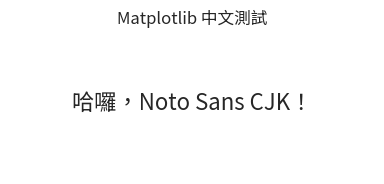

In [3]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
# 加入 LLM sentiment analysis
# 2️⃣  讀取 CSV，嘗試多種常見編碼
encodings_to_try = ["utf-8", "big5", "cp950", "gbk"]
file_path = 'csr_with_sentiment.csv'
csr_LLM_sentiment = None
for enc in encodings_to_try:
    try:
        csr_LLM_sentiment = pd.read_csv(file_path, sep=",", encoding=enc)
        print(f"✅ 成功以編碼「{enc}」載入資料。")
        break
    except UnicodeDecodeError:
        print(f"❌ 編碼「{enc}」失敗，嘗試下一個…")
    except Exception as e:
        print(f"🚨 其他錯誤（{enc}）：{e}")
        df = None
        break


✅ 成功以編碼「utf-8」載入資料。


In [6]:
csr_LLM_sentiment.head()

,CUST_NO,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD,score,explanation
0,1037415,網路連線問題,Cable modem連線,2024/11/19 上午 10:08:00,"(系統紀錄),ISP出口為E-PON速博,去前先電 0910609177&nbsp;賴先生，...",-0.6,The input text describes a situation where the...
1,1260839,經銷商問題,台哥大-電訪約裝,2024/11/19 上午 10:47:00,11/19 10:46 去電0965281644&nbsp; ..客說不裝..他會知會台哥大,-0.5,The input text indicates a customer contacted ...
2,937206,帳務問題,用戶要求優惠,2024/11/19 上午 11:02:00,.,0.0,"The input provided is an empty string ("".""). W..."
3,983447,網路連線問題,無法上網,2024/11/19 上午 11:06:00,"(系統紀錄)用戶目前的cmts為10.0.5.29,ISP出口為速博,去電聯0911-969...",-0.9,The input indicates that the customer is exper...
4,1062324,網路連線問題,無法上網,2024/11/19 上午 11:13:00,"(系統紀錄),ISP出口為E-PON速博,先電047627677/0908-283299.....",-0.7,The input text indicates a problem where the O...


In [7]:
# 檢查 csr_LLM_sentiment 中的 CUST_NO 重複情況
print("=== 檢查 csr_LLM_sentiment 中的 CUST_NO 重複情況 ===")

if 'csr_LLM_sentiment' in locals() and csr_LLM_sentiment is not None:
    print(f"總筆數: {len(csr_LLM_sentiment):,}")
    print(f"CUST_NO 欄位是否存在: {'CUST_NO' in csr_LLM_sentiment.columns}")
    
    if 'CUST_NO' in csr_LLM_sentiment.columns:
        # 檢查唯一值數量
        unique_customers = csr_LLM_sentiment['CUST_NO'].nunique()
        total_records = len(csr_LLM_sentiment)
        
        print(f"唯一客戶數 (CUST_NO): {unique_customers:,}")
        print(f"總記錄數: {total_records:,}")
        print(f"是否所有 CUST_NO 都是唯一的: {unique_customers == total_records}")
        
        if unique_customers != total_records:
            print(f"❌ 有重複的 CUST_NO")
            print(f"重複筆數: {total_records - unique_customers:,}")
            print(f"重複比例: {(total_records - unique_customers) / total_records * 100:.2f}%")
            
            # 找出重複的 CUST_NO
            duplicate_customers = csr_LLM_sentiment['CUST_NO'].value_counts()
            duplicate_customers = duplicate_customers[duplicate_customers > 1]
            
            print(f"\n重複的客戶數量: {len(duplicate_customers):,}")
            print(f"重複次數分佈:")
            print(duplicate_customers.value_counts().sort_index())
            
            # 顯示前10個重複最多的客戶
            print(f"\n重複次數最多的前10個客戶:")
            print(duplicate_customers.head(10))
            
            # 檢查重複記錄的其他特徵
            if len(duplicate_customers) > 0:
                sample_duplicate_cust = duplicate_customers.index[0]
                duplicate_records = csr_LLM_sentiment[csr_LLM_sentiment['CUST_NO'] == sample_duplicate_cust]
                
                print(f"\n範例：客戶 {sample_duplicate_cust} 的重複記錄:")
                display(duplicate_records)
                
        else:
            print(f"✅ 所有 CUST_NO 都是唯一的，沒有重複")
            
        # 檢查是否有空值
        null_count = csr_LLM_sentiment['CUST_NO'].isnull().sum()
        print(f"\nCUST_NO 空值數量: {null_count:,}")
        
        if null_count > 0:
            print(f"❌ 有 {null_count:,} 筆記錄的 CUST_NO 為空值")
        else:
            print(f"✅ 沒有 CUST_NO 空值")
            
    else:
        print("❌ csr_LLM_sentiment 中沒有 CUST_NO 欄位")
        print("可用欄位:", list(csr_LLM_sentiment.columns))
        
else:
    print("❌ csr_LLM_sentiment 未定義或為 None")
    
print("\n" + "="*60)

=== 檢查 csr_LLM_sentiment 中的 CUST_NO 重複情況 ===
總筆數: 79,764
CUST_NO 欄位是否存在: True
唯一客戶數 (CUST_NO): 44,349
總記錄數: 79,764
是否所有 CUST_NO 都是唯一的: False
❌ 有重複的 CUST_NO
重複筆數: 35,415
重複比例: 44.40%

重複的客戶數量: 18,296
重複次數分佈:
count
2     10017
3      4220
4      1997
5       948
6       464
7       274
8       153
9        91
10       51
11       36
12       14
13       10
14        9
15        4
16        1
17        1
18        1
19        2
21        2
23        1
Name: count, dtype: int64

重複次數最多的前10個客戶:
CUST_NO
856873     23
953834     21
288844     21
1254673    19
1224281    19
1242727    18
781090     17
1243790    16
1236221    15
1172052    15
Name: count, dtype: int64

範例：客戶 856873 的重複記錄:


,CUST_NO,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD,score,explanation
10476,856873,經銷商問題,台哥大-電訪約裝,2024/3/2 下午 7:03:00,<P>3/2 19:03去電0931399564&nbsp;轉語音，onu已到櫃檯退.STB...,-0.7,The input text indicates a customer contacting...
10615,856873,經銷商問題,台哥大-電訪約裝,2024/3/4 上午 11:52:00,<P>3/4 11:52電-轉語音 </P>\n<P>13:40轉語音</P>\n<P>早中...,-0.7,The input indicates multiple failed attempts t...
12822,856873,經銷商問題,台哥大-電訪約裝,2024/3/2 下午 6:45:00,"<TABLE style=""WIDTH: 158pt; BORDER-COLLAPSE: c...",0.9,"The input text states '已完成拉線，可供裝1G', which tra..."
13827,856873,經銷商問題,台哥大-電訪約裝,2024/3/1 下午 2:31:00,<P>3/1 14:31去電0931399564&nbsp;轉語音</P>,-0.2,The input indicates that a customer attempted ...
18083,856873,經銷商問題,台哥大-人員進電,2024/4/17 下午 1:00:00,"<P>4/17台哥大門市進電-告知客人都未接到來電,有告知我們聯繫用戶他幾乎都轉語音信箱不然...",-0.6,The input text describes issues faced by a cus...
18316,856873,經銷商問題,台哥大-電訪約裝,2024/4/12 上午 9:10:00,<P>4/12&nbsp; 09:10去電0931399564&nbsp; 直接轉語音 </...,-0.7,The input indicates that the customer tried to...
18489,856873,經銷商問題,台哥大-電訪約裝,2024/4/15 下午 7:29:00,<P>4/15-已完成拉線，可供裝1G</P>,0.9,The input text indicates that the cable line w...
19638,856873,經銷商問題,台哥大-電訪約裝,2024/4/9 下午 7:42:00,<P>已完成拉線，可供裝1G</P>\n<br/><P>4/9 19:42電09313995...,0.7,The input text indicates that the wiring task ...
20629,856873,經銷商問題,台哥大-電訪約裝,2024/4/13 下午 7:08:00,4/13 19:08 電 未接 轉語音,-0.6,The input '4/13 19:08 電 未接 轉語音' translates to ...
20782,856873,經銷商問題,台哥大-電訪約裝,2024/4/15 下午 5:26:00,4/15 17:26去電0931399564直接轉語音,-0.5,The input indicates a customer calling a speci...



CUST_NO 空值數量: 0
✅ 沒有 CUST_NO 空值



In [8]:
# 處理 csr_LLM_sentiment 中重複的 CUST_NO，計算平均 score 並確保唯一性

print("=== 處理 csr_LLM_sentiment 重複客戶並計算平均分數 ===")

if 'csr_LLM_sentiment' in locals() and csr_LLM_sentiment is not None:
    # 1. 檢查原始資料情況
    print(f"原始資料筆數: {len(csr_LLM_sentiment):,}")
    print(f"唯一客戶數: {csr_LLM_sentiment['CUST_NO'].nunique():,}")
    
    # 2. 識別score相關欄位（假設有sentiment_score欄位，請根據實際欄位名稱調整）
    # 先查看所有欄位，找出包含score的欄位
    print("\n=== 可用欄位 ===")
    print(csr_LLM_sentiment.columns.tolist())
    
    # 自動識別可能的score欄位
    score_columns = [col for col in csr_LLM_sentiment.columns if 'score' in col.lower() or 'sentiment' in col.lower()]
    print(f"\n發現的分數相關欄位: {score_columns}")
    
    if score_columns:
        # 3. 計算每個客戶的平均分數
        print(f"\n開始處理重複客戶，計算平均分數...")
        
        # 建立聚合字典
        agg_dict = {}
        
        # 為每個score欄位設定平均值計算
        for col in score_columns:
            if csr_LLM_sentiment[col].dtype in ['int64', 'float64']:
                agg_dict[col] = 'mean'
        
        # 保留其他可能有用的欄位（取第一個值）
        other_columns = [col for col in csr_LLM_sentiment.columns 
                        if col not in ['CUST_NO'] + score_columns]
        
        for col in other_columns:
            agg_dict[col] = 'first'  # 對於非數值欄位，取第一個值
        
        # 4. 按CUST_NO分組並聚合
        csr_LLM_sentiment_unique = csr_LLM_sentiment.groupby('CUST_NO').agg(agg_dict).reset_index()
        
        # 5. 重新命名平均分數欄位（加上AVG_前綴）
        rename_dict = {}
        for col in score_columns:
            if csr_LLM_sentiment[col].dtype in ['int64', 'float64']:
                new_name = f"AVG_{col}" if not col.startswith('AVG_') else col
                rename_dict[col] = new_name
        
        if rename_dict:
            csr_LLM_sentiment_unique = csr_LLM_sentiment_unique.rename(columns=rename_dict)
        
        # 6. 顯示處理結果
        print(f"\n=== 處理結果 ===")
        print(f"處理後資料筆數: {len(csr_LLM_sentiment_unique):,}")
        print(f"唯一客戶數: {csr_LLM_sentiment_unique['CUST_NO'].nunique():,}")
        print(f"是否已確保CUST_NO唯一性: {len(csr_LLM_sentiment_unique) == csr_LLM_sentiment_unique['CUST_NO'].nunique()}")
        
        # 7. 顯示前幾筆處理後的資料
        print(f"\n=== 處理後資料預覽 ===")
        display(csr_LLM_sentiment_unique.head())
        
        # 8. 比較處理前後的統計
        print(f"\n=== 處理前後對比 ===")
        for original_col, new_col in rename_dict.items():
            if original_col in csr_LLM_sentiment.columns and new_col in csr_LLM_sentiment_unique.columns:
                original_stats = csr_LLM_sentiment[original_col].describe()
                new_stats = csr_LLM_sentiment_unique[new_col].describe()
                
                print(f"\n{original_col} -> {new_col}:")
                print(f"  原始平均值: {original_stats['mean']:.4f}")
                print(f"  處理後平均值: {new_stats['mean']:.4f}")
                print(f"  原始標準差: {original_stats['std']:.4f}")
                print(f"  處理後標準差: {new_stats['std']:.4f}")
        
        # 9. 檢查是否有重複的客戶（應該沒有）
        duplicate_check = csr_LLM_sentiment_unique['CUST_NO'].value_counts()
        duplicates = duplicate_check[duplicate_check > 1]
        
        if len(duplicates) > 0:
            print(f"\n❌ 警告：仍有 {len(duplicates)} 個重複的客戶")
            print(duplicates.head())
        else:
            print(f"\n✅ 確認：所有客戶都是唯一的")
        
        # 10. 保存處理後的資料
        output_path = 'csr_LLM_sentiment_unique.csv'
        csr_LLM_sentiment_unique.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"\n處理後的唯一客戶資料已保存至: {output_path}")
        
        # 11. 更新原始變數（可選）
        print(f"\n是否要用處理後的資料替換原始 csr_LLM_sentiment？(建議保留原始資料)")
        # csr_LLM_sentiment_original = csr_LLM_sentiment.copy()  # 備份原始資料
        # csr_LLM_sentiment = csr_LLM_sentiment_unique.copy()   # 替換為唯一資料
        
    else:
        print("❌ 未找到score相關欄位，請檢查欄位名稱")
        print("請手動指定score欄位名稱，例如:")
        print("score_columns = ['sentiment_score', 'emotion_score']  # 請根據實際欄位調整")
        
else:
    print("❌ csr_LLM_sentiment 未定義或為 None")

print("\n" + "="*60)

=== 處理 csr_LLM_sentiment 重複客戶並計算平均分數 ===
原始資料筆數: 79,764
唯一客戶數: 44,349

=== 可用欄位 ===
['CUST_NO', 'ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CUST_RECORD_DATE', 'CUST_RECORD', 'score', 'explanation']

發現的分數相關欄位: ['score']

開始處理重複客戶，計算平均分數...

=== 處理結果 ===
處理後資料筆數: 44,349
唯一客戶數: 44,349
是否已確保CUST_NO唯一性: True

=== 處理後資料預覽 ===


,CUST_NO,AVG_score,ED_SERVCLASSNAME,ED_SERVCLASS2NAME,CUST_RECORD_DATE,CUST_RECORD,explanation
0,4,-0.7,網路連線問題,網路品質,2024/12/23 下午 9:43:00,"(系統紀錄)用戶目前的cmts為10.0.2.22,ISP出口為速博,反映每到晚上都斷斷續續...",The input text describes a customer experienci...
1,171,-0.7,網路連線問題,網路品質,2024/3/12 下午 8:50:00,"(系統紀錄)用戶目前的cmts為10.0.2.9,ISP出口為速博,去電0919-67227...",The input text describes a customer experienci...
2,302,-0.2,帳務問題,繳費相關問題,2024/8/27 上午 9:43:00,"(系統紀錄),ISP出口為E-PON亞太寬頻,8/27電訪bb催繳去電0985889861&...",The input text appears to be a system record o...
3,311,-0.4,帳務相關,拆機挽回,2024/3/5 上午 11:23:00,"(系統紀錄),ISP出口為E-PON速博,本人-價格高.今網價格2年8900元(300M/3...",The input text reflects a customer complaint a...
4,415,-0.6,網路連線問題,網路品質,2024/1/24 下午 10:43:00,"(系統紀錄)用戶目前的cmts為10.0.2.23,ISP出口為速博,(本版3.0)約1/2...",The input text indicates a customer issue with...



=== 處理前後對比 ===

score -> AVG_score:
  原始平均值: -0.3645
  處理後平均值: -0.4036
  原始標準差: 0.4704
  處理後標準差: 0.3863

✅ 確認：所有客戶都是唯一的

處理後的唯一客戶資料已保存至: csr_LLM_sentiment_unique.csv

是否要用處理後的資料替換原始 csr_LLM_sentiment？(建議保留原始資料)



## 步驟 3：客戶來電次數統計與分析

此儲存格的目的是計算並分析每位客戶的來電次數。這是一個重要的基礎特徵，有助於了解客戶的互動頻率。

1.  **計算來電次數**：根據 `CUST_NO` (客戶編號) 欄位，統計每位客戶在資料集中的出現次數，即為其來電總次數。
2.  **建立來電次數資料框**：將計算結果儲存為一個新的 DataFrame (`call_counts`)，包含 `CUST_NO` 和 `CALL_COUNT` 兩欄。
3.  **合併回主資料框**：將計算出的來電次數 (`CALL_COUNT`) 合併回原始資料框 `df`，產生一個新的資料框 `df_with_counts`，方便後續使用。
4.  **顯示結果與統計**：
    -   顯示 `call_counts` 的前幾筆資料。
    -   顯示 `df_with_counts` 的前幾筆資料，確認合併成功。
    -   顯示 `CALL_COUNT` 欄位的描述性統計 (如平均值、中位數、最大最小值等)。
5.  **視覺化來電次數分佈**：繪製長條圖或直方圖，展示客戶來電次數的分佈情況。

開始計算客戶來電次數...
--- 客戶來電次數 (call_counts) (前 5 筆) ---


,CUST_NO,CALL_COUNT
0,856873,23
1,953834,21
2,288844,21
3,1254673,19
4,1224281,19


--- 資料框已加入來電次數 (df_with_counts) (前 5 筆) ---


,CUST_NO,CALL_COUNT,ED_SERVCLASSNAME,ED_SERVCLASS2NAME
0,1037415,3,網路連線問題,Cable modem連線
1,1260839,3,經銷商問題,台哥大-電訪約裝
2,937206,1,帳務問題,用戶要求優惠
3,983447,1,網路連線問題,無法上網
4,1062324,1,網路連線問題,無法上網


--- 來電次數 (CALL_COUNT) 描述性統計 ---


count    79797.000000
mean         2.833277
std          2.262721
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         23.000000
Name: CALL_COUNT, dtype: float64

--- 視覺化客戶來電次數分佈 ---


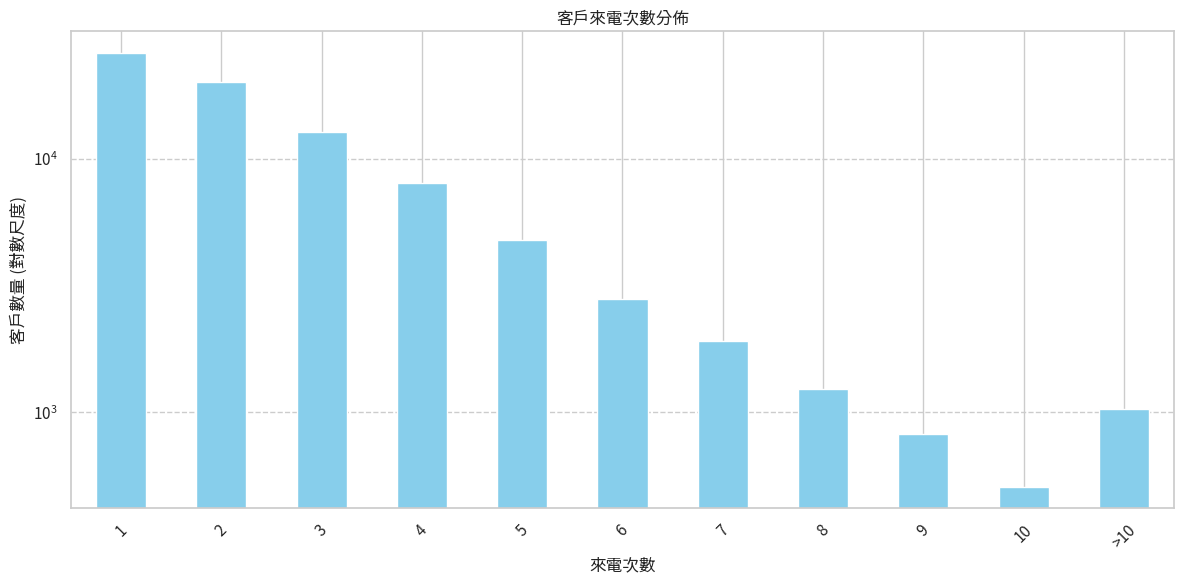

客戶來電次數分析完成。


In [4]:
# 步驟 3：客戶來電次數統計與分析

# 初始化將在此步驟中創建的 DataFrame
call_counts = None
df_with_counts = None

if 'df' in locals() and df is not None and not df.empty:
    if 'CUST_NO' in df.columns:
        print("開始計算客戶來電次數...")
        
        # 1. 計算來電次數
        call_counts_series = df['CUST_NO'].value_counts()
        
        # 2. 建立來電次數資料框
        call_counts = call_counts_series.reset_index()
        call_counts.columns = ['CUST_NO', 'CALL_COUNT']
        
        print("--- 客戶來電次數 (call_counts) (前 5 筆) ---")
        try:
            display(call_counts.head())
        except NameError:
            print(call_counts.head().to_string())

        # 3. 合併回主資料框
        # 先複製一份 df，避免直接修改原始 df (如果後續還需要原始 df 的話)
        df_with_counts = df.copy()
        df_with_counts = pd.merge(df_with_counts, call_counts, on='CUST_NO', how='left')
        
        print("--- 資料框已加入來電次數 (df_with_counts) (前 5 筆) ---")
        try:
            # 顯示包含 CUST_NO 和 CALL_COUNT 的欄位，以及原始資料中的一些欄位以便核對
            display_cols = ['CUST_NO', 'CALL_COUNT'] + [col for col in df.columns if col not in ['CUST_NO', 'CALL_COUNT']][:2]
            display(df_with_counts[display_cols].head())
        except NameError:
            print(df_with_counts[display_cols].head().to_string())
        except KeyError as e:
            print(f"顯示 df_with_counts 時發生欄位錯誤: {e}. 可能原始 df 欄位不足。顯示 CUST_NO 和 CALL_COUNT:")
            try:
                display(df_with_counts[['CUST_NO', 'CALL_COUNT']].head())
            except NameError:
                print(df_with_counts[['CUST_NO', 'CALL_COUNT']].head().to_string())

        # 4. 顯示 CALL_COUNT 欄位的描述性統計
        print("--- 來電次數 (CALL_COUNT) 描述性統計 ---")
        try:
            display(df_with_counts['CALL_COUNT'].describe())
        except NameError:
            print(df_with_counts['CALL_COUNT'].describe().to_string())

        # 5. 視覺化來電次數分佈
        print("--- 視覺化客戶來電次數分佈 ---")
        plt.figure(figsize=(12, 6))
        
        # 為了更清晰的視覺化，如果來電次數種類過多，可以考慮對高次數進行分組或限制顯示範圍
        # 例如，只顯示來電次數 <= 10 的分佈
        # plot_data = df_with_counts['CALL_COUNT'][df_with_counts['CALL_COUNT'] <= 10]
        # sns.histplot(plot_data, discrete=True, shrink=0.8) # discrete for integer counts
        
        # 或者，使用 value_counts 繪製長條圖，更適合離散的計數
        call_count_distribution = df_with_counts['CALL_COUNT'].value_counts().sort_index()
        # 如果種類太多，只取前 N 個或一定範圍內的
        if len(call_count_distribution) > 20: # Example threshold
            call_count_distribution_plot = call_count_distribution[call_count_distribution.index <= 10] # Show up to 10 calls
            if call_count_distribution[call_count_distribution.index > 10].sum() > 0:
                 call_count_distribution_plot['>10'] = call_count_distribution[call_count_distribution.index > 10].sum()
        else:
            call_count_distribution_plot = call_count_distribution

        call_count_distribution_plot.plot(kind='bar', color='skyblue')
        plt.title('客戶來電次數分佈')
        plt.xlabel('來電次數')
        plt.ylabel('客戶數量 (對數尺度)' if call_count_distribution_plot.max() > 1000 else '客戶數量')
        plt.xticks(rotation=45)
        if call_count_distribution_plot.max() > 1000: # Apply log scale if counts are very high
            plt.yscale('log')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'call_count_distribution.png')) # output_main_dir from Step 1
        plt.show()
        
        print("客戶來電次數分析完成。")

    else:
        print("錯誤: DataFrame 'df' 中缺少 'CUST_NO' 欄位，無法計算來電次數。")
else:
    print("錯誤: DataFrame 'df' 未定義、為空或在先前步驟中載入失敗。請先執行資料載入步驟。")



## 步驟 4：主要問題類別提取與分析

此儲存格的目的是為每位客戶提取其最主要的來電問題大分類和小分類。這有助於了解客戶主要的服務需求或痛點。

1.  **識別分類欄位**：使用 `ED_SERVCLASSNAME` 作為問題大分類，`ED_SERVCLASS2NAME` 作為問題小分類。
2.  **確定客戶主要分類**：對於擁有多筆來電紀錄的客戶，計算其各類別的出現頻次，並選取最常見的大分類和小分類作為該客戶的主要分類。若有多個分類出現頻次相同，則選擇第一個。
3.  **建立客戶分類資料框**：將結果儲存為一個新的 DataFrame (`customer_categories`)，包含 `CUST_NO`、`MAIN_CATEGORY` 和 `SUB_CATEGORY`。
4.  **顯示結果與統計**：
    -   顯示 `customer_categories` 的前幾筆資料。
    -   顯示主要問題大分類和小分類的分佈情況 (例如，使用長條圖)。
5.  **(準備合併)** 此步驟產生的 `customer_categories` 將在後續步驟中用於建立最終的客戶級別特徵資料集。

開始提取客戶主要問題分類 (大分類: ED_SERVCLASSNAME, 小分類: ED_SERVCLASS2NAME)...
計算客戶主要大分類...
計算客戶主要小分類...
--- 客戶主要問題分類 (customer_categories) (前 5 筆) ---


,CUST_NO,MAIN_CATEGORY,SUB_CATEGORY
0,4,網路連線問題,網路品質
1,171,網路連線問題,網路品質
2,302,帳務問題,繳費相關問題
3,311,帳務相關,拆機挽回
4,415,網路連線問題,網路品質


--- 主要問題大分類 (MAIN_CATEGORY) 分佈 ---


MAIN_CATEGORY
網路連線問題    26855
經銷商問題     10145
帳務相關       4013
帳務問題       2600
非連線問題       532
註冊問題        104
新產品          81
搬家問題         16
E Mail        3
Name: count, dtype: int64

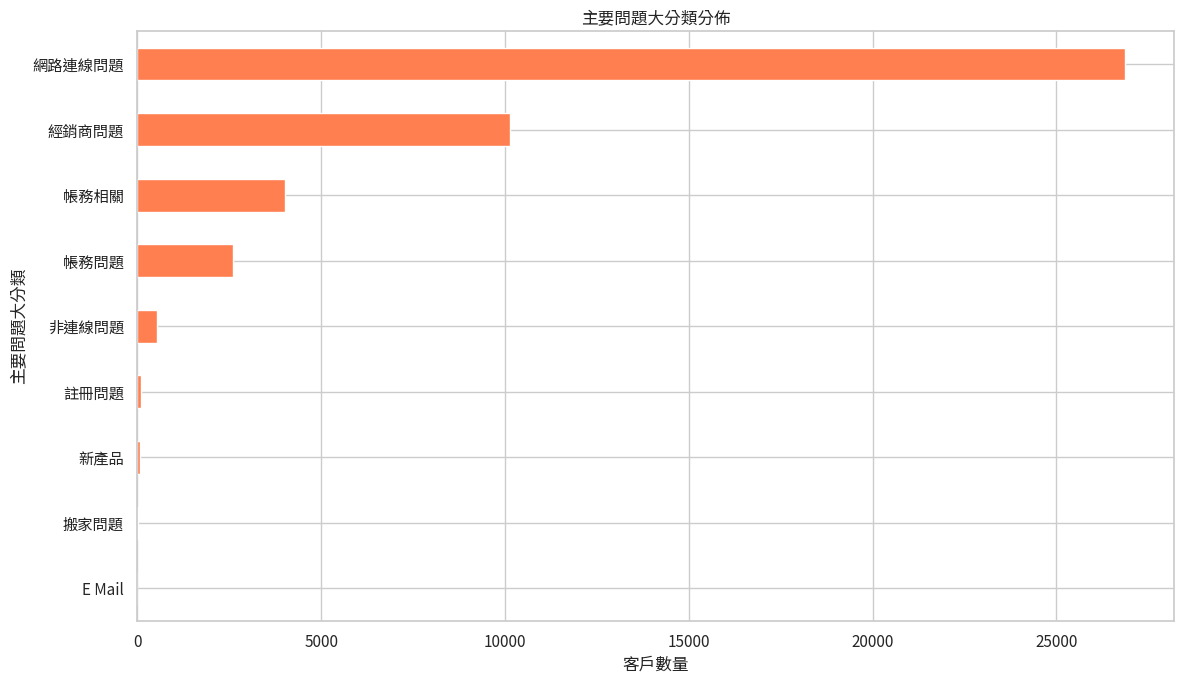

--- 主要問題小分類 (SUB_CATEGORY) 分佈 (Top 15) ---


SUB_CATEGORY
無法上網             18086
台哥大-電訪約裝          6334
Cable modem連線     4635
拆機挽回              4143
網路品質              3618
遠傳電信-電訪約裝         2866
連線其他相關問題           716
台哥大-人員進電           570
繳費相關問題             553
頻寬方案費率             480
固定Ip問題             342
用戶要求優惠             296
服務異動               232
遠傳電信-人員進電          224
用戶退租               168
Name: count, dtype: int64

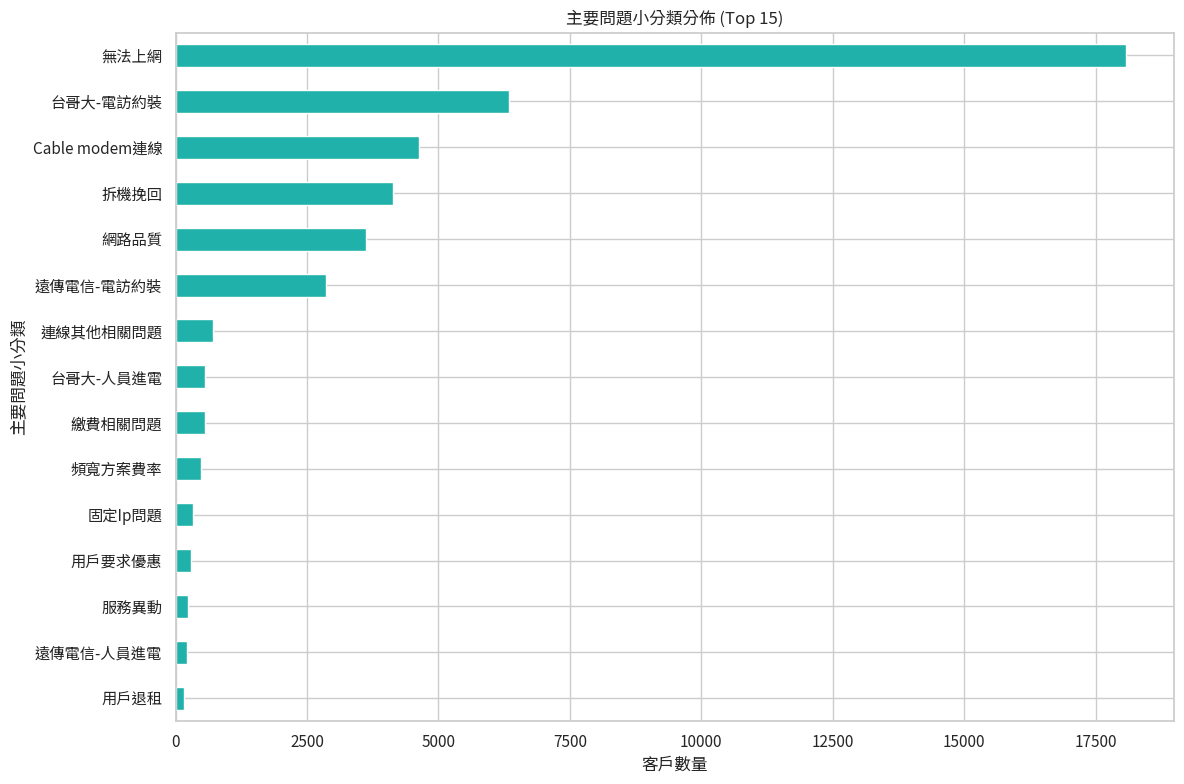

客戶主要問題類別提取完成。


In [7]:
# 步驟 4：主要問題類別提取與分析

# 初始化將在此步驟中創建的 DataFrame
customer_categories = None
# df_with_categories = None # This will be created in a later step when merging all features

if 'df_with_counts' in locals() and df_with_counts is not None and not df_with_counts.empty:
    # 1. 識別分類欄位
    main_category_col = 'ED_SERVCLASSNAME'
    sub_category_col = 'ED_SERVCLASS2NAME'

    if main_category_col in df_with_counts.columns and sub_category_col in df_with_counts.columns:
        print(f"開始提取客戶主要問題分類 (大分類: {main_category_col}, 小分類: {sub_category_col})...")
        
        # 處理分類欄位中的 NaN 值，替換為 '未知' 或其他標記
        df_categories_processed = df_with_counts.copy()
        df_categories_processed[main_category_col] = df_categories_processed[main_category_col].fillna('未知').astype(str)
        df_categories_processed[sub_category_col] = df_categories_processed[sub_category_col].fillna('未知').astype(str)

        # 2. 確定客戶主要分類 (使用 mode)
        # Group by CUST_NO and find the mode for main and sub categories
        # mode() can return multiple values if ties exist, so we take the first one ([0])
        # We need a robust way to handle cases where mode might be empty or cause issues.
        
        def get_mode_or_unknown(series):
            mode_val = series.mode()
            if not mode_val.empty:
                return mode_val[0]
            return '未知' # Fallback if mode is empty for some reason

        print("計算客戶主要大分類...")
        main_categories = df_categories_processed.groupby('CUST_NO')[main_category_col].apply(get_mode_or_unknown).reset_index()
        main_categories.columns = ['CUST_NO', 'MAIN_CATEGORY']

        print("計算客戶主要小分類...")
        sub_categories = df_categories_processed.groupby('CUST_NO')[sub_category_col].apply(get_mode_or_unknown).reset_index()
        sub_categories.columns = ['CUST_NO', 'SUB_CATEGORY']

        # 3. 建立客戶分類資料框
        customer_categories = pd.merge(main_categories, sub_categories, on='CUST_NO', how='outer')
        # Ensure CUST_NO type consistency if merging with other dataframes later
        if 'CUST_NO' in df_with_counts.columns:
             customer_categories['CUST_NO'] = customer_categories['CUST_NO'].astype(df_with_counts['CUST_NO'].dtype)

        print("--- 客戶主要問題分類 (customer_categories) (前 5 筆) ---")
        try:
            display(customer_categories.head())
        except NameError:
            print(customer_categories.head().to_string())

        # 4. 顯示結果與統計
        print("--- 主要問題大分類 (MAIN_CATEGORY) 分佈 ---")
        main_category_dist = customer_categories['MAIN_CATEGORY'].value_counts()
        try:
            display(main_category_dist)
        except NameError:
            print(main_category_dist.to_string())
        
        plt.figure(figsize=(12, 7))
        # Limit to top N categories if too many, for better visualization
        top_n_main = 15
        if len(main_category_dist) > top_n_main:
            main_category_dist.head(top_n_main).plot(kind='barh', color='coral')
            plt.title(f'主要問題大分類分佈 (Top {top_n_main})')
        else:
            main_category_dist.plot(kind='barh', color='coral')
            plt.title('主要問題大分類分佈')
        plt.xlabel('客戶數量')
        plt.ylabel('主要問題大分類')
        plt.gca().invert_yaxis() # To show the most frequent on top
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'main_category_distribution.png'))
        plt.show()

        print("--- 主要問題小分類 (SUB_CATEGORY) 分佈 (Top 15) ---")
        sub_category_dist = customer_categories['SUB_CATEGORY'].value_counts()
        try:
            display(sub_category_dist.head(15))
        except NameError:
            print(sub_category_dist.head(15).to_string())

        plt.figure(figsize=(12, 8))
        top_n_sub = 15
        sub_category_dist.head(top_n_sub).plot(kind='barh', color='lightseagreen')
        plt.title(f'主要問題小分類分佈 (Top {top_n_sub})')
        plt.xlabel('客戶數量')
        plt.ylabel('主要問題小分類')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'sub_category_distribution.png'))
        plt.show()
        
        print("客戶主要問題類別提取完成。")

    else:
        missing_cols_cat = []
        if main_category_col not in df_with_counts.columns: missing_cols_cat.append(main_category_col)
        if sub_category_col not in df_with_counts.columns: missing_cols_cat.append(sub_category_col)
        print(f"錯誤: DataFrame 'df_with_counts' 中缺少必要的分類欄位: {', '.join(missing_cols_cat)}。無法提取問題類別。")
else:
    print("錯誤: DataFrame 'df_with_counts' 未定義、為空或在先前步驟中處理失敗。請先執行前面的步驟。")



## 步驟 5：客戶服務紀錄的離退語意分析

此儲存格的目的是分析客戶服務紀錄 (`CUST_RECORD`) 的文字內容，以評估客戶的離退傾向。我們將使用基於關鍵詞的方法，並結合 `jieba` 進行中文分詞。

1.  **定義離退相關關鍵詞**：建立正面（低離退風險，如滿意、解決）與負面（高離退風險，如不滿、解約）的關鍵詞列表。
2.  **計算單筆紀錄離退傾向分數**：對每條服務紀錄，使用 `jieba` 分詞後，根據文本中出現的正面與負面關鍵詞數量來計算一個離退傾向分數。
3.  **計算客戶平均離退傾向分數**：對於每位客戶，計算其所有服務紀錄的平均離退傾向分數，作為該客戶的「客戶服務紀錄的離退語意分析平均值」 (`AVG_SENTIMENT_SCORE`)。
4.  **建立客戶語意分析資料框**：將結果儲存為一個新的 DataFrame (`customer_avg_sentiment`)，包含 `CUST_NO` 和 `AVG_SENTIMENT_SCORE`。
5.  **顯示結果與統計**：
    -   顯示 `customer_avg_sentiment` 的前幾筆資料。
    -   顯示 `AVG_SENTIMENT_SCORE` 欄位的描述性統計。
6.  **視覺化平均離退傾向分數分佈**：繪製直方圖，展示客戶平均離退傾向分數的分佈情況。
7.  **(準備合併)** 此步驟產生的 `customer_avg_sentiment` 將在後續步驟中用於建立最終的客戶級別特徵資料集。

開始進行客戶服務紀錄的離退語意分析...
服務紀錄離退傾向分數計算完成 (部分預覽):


,CUST_NO,CUST_RECORD_CLEAN,RECORD_SENTIMENT_SCORE
0,1037415,"(系統紀錄),ISP出口為E-PON速博,去前先電 0910609177&nbsp;賴先生，...",-1
1,1260839,11/19 10:46 去電0965281644&nbsp; ..客說不裝..他會知會台哥大,0
2,937206,.,0
3,983447,"(系統紀錄)用戶目前的cmts為10.0.5.29,ISP出口為速博,去電聯0911-969...",0
4,1062324,"(系統紀錄),ISP出口為E-PON速博,先電047627677/0908-283299.....",0


客戶平均離退傾向分數 (customer_avg_sentiment) 計算完成 (前 5 筆):


,CUST_NO,AVG_SENTIMENT_SCORE
0,4,0.0
1,171,1.0
2,302,0.0
3,311,0.0
4,415,1.0


--- 平均離退傾向分數 (AVG_SENTIMENT_SCORE) 描述性統計 ---


count    44349.000000
mean        -0.134227
std          0.504560
min         -8.000000
25%         -0.250000
50%          0.000000
75%          0.000000
max          8.000000
Name: AVG_SENTIMENT_SCORE, dtype: float64

--- 視覺化客戶平均離退傾向分數分佈 ---


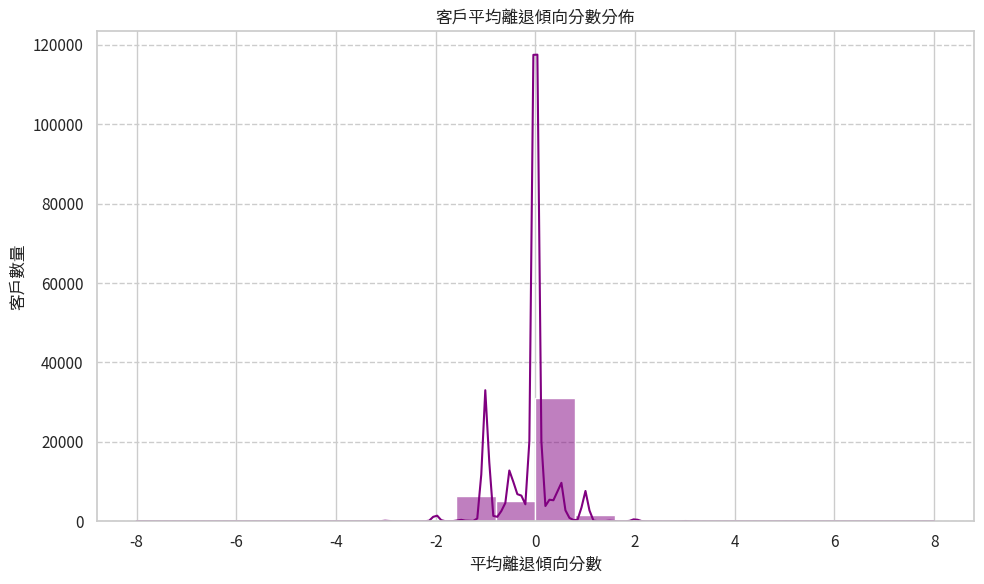

客戶服務紀錄的離退語意分析完成。


In [9]:
# 步驟 5：客戶服務紀錄的離退語意分析

# 初始化將在此步驟中創建的 DataFrame
customer_avg_sentiment = None
# df_with_sentiment will be created when merging this with previous step's result (customer_categories)

if 'df_with_counts' in locals() and df_with_counts is not None and not df_with_counts.empty:
    if 'CUST_NO' in df_with_counts.columns and 'CUST_RECORD' in df_with_counts.columns:
        print("開始進行客戶服務紀錄的離退語意分析...")

        # 1. 定義離退相關關鍵詞
        # 正面詞彙 (低離退風險, e.g., 滿意, 解決, 感謝, 續約)
        positive_churn_keywords = ['滿意', '解決', '感謝', '續約', '推薦', '穩定', '正常', '清楚', '明白', '願意', '好', '快', '順利', '沒問題', 'OK', 'ok', '搞定']
        # 負面詞彙 (高離退風險, e.g., 不滿, 解約, 抱怨, 問題, 斷線)
        negative_churn_keywords = ['不滿', '解約', '取消', '抱怨', '問題', '故障', '斷線', '龜速', '不穩', '困難', '複雜', '聽不懂', '考慮', '慢', '差', '爛', '不行', '無效', '火大', '生氣']

        # 2. 計算單筆紀錄離退傾向分數
        def get_churn_sentiment_score(text):
            if pd.isna(text) or not isinstance(text, str) or not text.strip():
                return 0  # 中性分數或無效文本
            
            score = 0
            try:
                # 確保 jieba 已經被匯入 (通常在筆記本開頭的設定儲存格中)
                # import jieba # 如果沒有在開頭導入，可以在這裡導入或確保它在作用域內
                words = jieba.lcut(str(text).lower())  # 分詞並轉小寫
                for word in words:
                    if word in positive_churn_keywords:
                        score += 1
                    elif word in negative_churn_keywords:
                        score -= 1
            except Exception as e:
                # print(f"Jieba分詞時發生錯誤: {e}，文本: {text[:50]}...") # 可選的錯誤日誌
                return 0  # 分詞錯誤也視為中性
            return score

        # 對每條服務紀錄計算離退傾向分數
        # 確保 CUST_RECORD 是字串類型，並處理 NaN
        df_sentiment_analysis = df_with_counts.copy() # Work on a copy
        df_sentiment_analysis['CUST_RECORD_CLEAN'] = df_sentiment_analysis['CUST_RECORD'].fillna('').astype(str)
        df_sentiment_analysis['RECORD_SENTIMENT_SCORE'] = df_sentiment_analysis['CUST_RECORD_CLEAN'].apply(get_churn_sentiment_score)

        print("服務紀錄離退傾向分數計算完成 (部分預覽):")
        try:
            display(df_sentiment_analysis[['CUST_NO', 'CUST_RECORD_CLEAN', 'RECORD_SENTIMENT_SCORE']].head())
        except NameError:
            print(df_sentiment_analysis[['CUST_NO', 'CUST_RECORD_CLEAN', 'RECORD_SENTIMENT_SCORE']].head().to_string())

        # 3. 計算每位客戶的平均離退傾向分數
        customer_avg_sentiment = df_sentiment_analysis.groupby('CUST_NO')['RECORD_SENTIMENT_SCORE'].mean().reset_index()
        customer_avg_sentiment.columns = ['CUST_NO', 'AVG_SENTIMENT_SCORE']
        
        # 確保 CUST_NO 型別一致性，以便後續合併
        if 'CUST_NO' in df_with_counts.columns:
            customer_avg_sentiment['CUST_NO'] = customer_avg_sentiment['CUST_NO'].astype(df_with_counts['CUST_NO'].dtype)

        print("客戶平均離退傾向分數 (customer_avg_sentiment) 計算完成 (前 5 筆):")
        try:
            display(customer_avg_sentiment.head())
        except NameError:
            print(customer_avg_sentiment.head().to_string())

        # 4. 顯示 AVG_SENTIMENT_SCORE 欄位的描述性統計
        print("--- 平均離退傾向分數 (AVG_SENTIMENT_SCORE) 描述性統計 ---")
        try:
            display(customer_avg_sentiment['AVG_SENTIMENT_SCORE'].describe())
        except NameError:
            print(customer_avg_sentiment['AVG_SENTIMENT_SCORE'].describe().to_string())

        # 5. 視覺化平均離退傾向分數分佈
        print("--- 視覺化客戶平均離退傾向分數分佈 ---")
        plt.figure(figsize=(10, 6))
        sns.histplot(customer_avg_sentiment['AVG_SENTIMENT_SCORE'], bins=20, kde=True, color='purple')
        plt.title('客戶平均離退傾向分數分佈')
        plt.xlabel('平均離退傾向分數')
        plt.ylabel('客戶數量')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'avg_sentiment_score_distribution.png')) # output_main_dir from Step 1
        plt.show()
        
        print("客戶服務紀錄的離退語意分析完成。")

    else:
        missing_cols_sent = []
        if 'CUST_NO' not in df_with_counts.columns: missing_cols_sent.append('CUST_NO')
        if 'CUST_RECORD' not in df_with_counts.columns: missing_cols_sent.append('CUST_RECORD')
        print(f"錯誤: DataFrame 'df_with_counts' 中缺少必要的欄位: {', '.join(missing_cols_sent)}。無法進行離退語意分析。")
elif 'df' in locals() and df is not None and not df.empty:
    print("警告: 'df_with_counts' 未定義或為空，但 'df' 存在。可能是上一步驟未成功執行。請檢查。")
    print("將嘗試直接從 'df' 進行語意分析 (如果必要欄位存在)。")
    # Fallback to df if df_with_counts is not available but df is
    if 'CUST_NO' in df.columns and 'CUST_RECORD' in df.columns:
        # Repeat the logic from above using 'df' instead of 'df_with_counts'
        # This is a simplified fallback, ideally previous steps should be verified
        df_sentiment_analysis = df.copy()
        df_sentiment_analysis['CUST_RECORD_CLEAN'] = df_sentiment_analysis['CUST_RECORD'].fillna('').astype(str)
        df_sentiment_analysis['RECORD_SENTIMENT_SCORE'] = df_sentiment_analysis['CUST_RECORD_CLEAN'].apply(get_churn_sentiment_score)
        customer_avg_sentiment = df_sentiment_analysis.groupby('CUST_NO')['RECORD_SENTIMENT_SCORE'].mean().reset_index()
        customer_avg_sentiment.columns = ['CUST_NO', 'AVG_SENTIMENT_SCORE']
        customer_avg_sentiment['CUST_NO'] = customer_avg_sentiment['CUST_NO'].astype(df['CUST_NO'].dtype)
        print("已使用原始 'df' 完成離退語意分析 (部分功能)。建議檢查 'df_with_counts' 的生成。")
        try: display(customer_avg_sentiment.head()) 
        except: print(customer_avg_sentiment.head().to_string())
    else:
        print("錯誤: 原始 'df' 也缺少 'CUST_NO' 或 'CUST_RECORD'。無法進行語意分析。")
else:
    print("錯誤: DataFrame 'df_with_counts' (或 'df') 未定義、為空或在先前步驟中處理失敗。請先執行前面的步驟。")



## 步驟 6：整合特徵並建立最終客戶級別資料集

此儲存格的目的是將前面步驟中產生的所有客戶級別特徵（來電次數、主要問題大分類、主要問題小分類、平均離退語意分數）整合到一個最終的客戶資料集中。這個資料集將以客戶編號 (`CUST_NO`) 為單位，每位客戶一行，方便後續的分析與模型訓練。

1.  **建立基礎客戶列表**：從原始資料框 `df` 中提取所有不重複的客戶編號 (`CUST_NO`)，作為最終特徵資料集的基礎。
2.  **合併來電次數**：將 `call_counts` (包含 `CUST_NO` 和 `CALL_COUNT`) 合併到基礎客戶列表。
3.  **合併問題分類**：將 `customer_categories` (包含 `CUST_NO`, `MAIN_CATEGORY`, `SUB_CATEGORY`) 合併進來。
4.  **合併平均離退語意分數**：將 `customer_avg_sentiment` (包含 `CUST_NO`, `AVG_SENTIMENT_SCORE`) 合併進來。
5.  **處理缺失值**：在合併過程中，部分客戶可能缺少某些特徵（例如，沒有服務紀錄的客戶就沒有語意分數）。對這些缺失值進行合理的填充（例如，來電次數填 0，分類填 '未知'，語意分數填 0.0）。
6.  **顯示最終結果**：
    -   顯示最終客戶級別特徵資料集 (`df_final_features`) 的前幾筆資料。
    -   顯示其欄位資訊 (`info()`) 與缺失值檢查 (`isnull().sum()`)，確保資料完整性。

In [10]:
# 步驟 6：整合特徵並建立最終客戶級別資料集

# 初始化將在此步驟中創建的 DataFrame
df_final_features = None

print("開始整合客戶級別特徵...")

# 確保所有必要的客戶級別 DataFrames (call_counts, customer_categories, customer_avg_sentiment)
# 以及原始的 df (用於獲取所有 CUST_NO) 都已在之前的步驟中成功創建且可用。

if 'df' in locals() and df is not None and not df.empty and 'CUST_NO' in df.columns:
    # 1. 建立一個包含所有不重複客戶編號的基礎 DataFrame
    unique_customers = pd.DataFrame(df['CUST_NO'].unique(), columns=['CUST_NO'])
    print(f"找到 {len(unique_customers)} 位不重複的客戶作為基礎。")
    
    df_final_features = unique_customers.copy()
    # Ensure CUST_NO in df_final_features has a consistent type, preferably from original df
    df_final_features['CUST_NO'] = df_final_features['CUST_NO'].astype(df['CUST_NO'].dtype)

    # 2. 合併來電次數 (來自步驟 3 的 call_counts)
    if 'call_counts' in locals() and call_counts is not None and not call_counts.empty and 'CUST_NO' in call_counts.columns:
        # Ensure CUST_NO type consistency before merging
        call_counts_to_merge = call_counts.astype({'CUST_NO': df_final_features['CUST_NO'].dtype})
        df_final_features = pd.merge(df_final_features, call_counts_to_merge[['CUST_NO', 'CALL_COUNT']], on='CUST_NO', how='left')
        print("已合併客戶來電次數。")
    else:
        print("警告: 'call_counts' DataFrame 未定義、為空或缺少 CUST_NO。CALL_COUNT 將填充 NaN。")
        df_final_features['CALL_COUNT'] = np.nan # Add column if merge fails

    # 3. 合併問題分類 (來自步驟 4 的 customer_categories)
    if 'customer_categories' in locals() and customer_categories is not None and not customer_categories.empty and 'CUST_NO' in customer_categories.columns:
        customer_categories_to_merge = customer_categories.astype({'CUST_NO': df_final_features['CUST_NO'].dtype})
        df_final_features = pd.merge(df_final_features, customer_categories_to_merge[['CUST_NO', 'MAIN_CATEGORY', 'SUB_CATEGORY']], on='CUST_NO', how='left')
        print("已合併客戶主要問題分類。")
    else:
        print("警告: 'customer_categories' DataFrame 未定義、為空或缺少 CUST_NO。MAIN_CATEGORY 和 SUB_CATEGORY 將填充 NaN/NA。")
        df_final_features['MAIN_CATEGORY'] = pd.NA
        df_final_features['SUB_CATEGORY'] = pd.NA

    # 4. 合併平均離退語意分數 (來自步驟 5 的 customer_avg_sentiment)
    if 'customer_avg_sentiment' in locals() and customer_avg_sentiment is not None and not customer_avg_sentiment.empty and 'CUST_NO' in customer_avg_sentiment.columns:
        customer_avg_sentiment_to_merge = customer_avg_sentiment.astype({'CUST_NO': df_final_features['CUST_NO'].dtype})
        df_final_features = pd.merge(df_final_features, customer_avg_sentiment_to_merge[['CUST_NO', 'AVG_SENTIMENT_SCORE']], on='CUST_NO', how='left')
        print("已合併客戶平均離退語意分數。")
    else:
        print("警告: 'customer_avg_sentiment' DataFrame 未定義、為空或缺少 CUST_NO。AVG_SENTIMENT_SCORE 將填充 NaN。")
        df_final_features['AVG_SENTIMENT_SCORE'] = np.nan
            
    # 5. 處理合併過程中可能產生的缺失值
    # CALL_COUNT: 客戶至少有1次紀錄(來自df)，所以理論上call_counts合併後不應有NaN，但以防萬一
    if 'CALL_COUNT' in df_final_features.columns:
        df_final_features['CALL_COUNT'] = df_final_features['CALL_COUNT'].fillna(0).astype(int)
    else: # Should not happen if merge was attempted
        df_final_features['CALL_COUNT'] = 0 
        
    if 'MAIN_CATEGORY' in df_final_features.columns:
        df_final_features['MAIN_CATEGORY'] = df_final_features['MAIN_CATEGORY'].fillna('未知').astype(str)
    else:
        df_final_features['MAIN_CATEGORY'] = '未知'
        
    if 'SUB_CATEGORY' in df_final_features.columns:
        df_final_features['SUB_CATEGORY'] = df_final_features['SUB_CATEGORY'].fillna('未知').astype(str)
    else:
        df_final_features['SUB_CATEGORY'] = '未知'
        
    if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
        df_final_features['AVG_SENTIMENT_SCORE'] = df_final_features['AVG_SENTIMENT_SCORE'].fillna(0.0).astype(float)
    else:
        df_final_features['AVG_SENTIMENT_SCORE'] = 0.0

    print("最終客戶級別特徵資料集 (df_final_features) 建立完成。")
    
    # 6. 顯示最終結果
    print("--- 最終特徵資料集 (df_final_features) 預覽 (前 10 筆) ---")
    try:
        display(df_final_features.head(10))
    except NameError:
        print(df_final_features.head(10).to_string())
    
    print("--- 最終特徵資料集資訊 ---")
    df_final_features.info()
    
    print("--- 最終特徵資料集各欄位缺失值檢查 ---")
    print(df_final_features.isnull().sum())

else:
    print("錯誤: 原始 DataFrame 'df' 未定義、為空或缺少 'CUST_NO' 欄位。無法建立最終特徵資料集。")
    print("請確保資料載入步驟 (步驟 2) 已成功執行。")



開始整合客戶級別特徵...
找到 44349 位不重複的客戶作為基礎。
已合併客戶來電次數。
已合併客戶主要問題分類。
已合併客戶平均離退語意分數。
最終客戶級別特徵資料集 (df_final_features) 建立完成。
--- 最終特徵資料集 (df_final_features) 預覽 (前 10 筆) ---


,CUST_NO,CALL_COUNT,MAIN_CATEGORY,SUB_CATEGORY,AVG_SENTIMENT_SCORE
0,1037415,3,網路連線問題,網路品質,-0.333333
1,1260839,3,經銷商問題,台哥大-電訪約裝,0.000000
2,937206,1,帳務問題,用戶要求優惠,0.000000
3,983447,1,網路連線問題,無法上網,0.000000
4,1062324,1,網路連線問題,無法上網,0.000000
5,1194741,2,經銷商問題,台哥大-電訪約裝,0.000000
6,1222336,8,經銷商問題,台哥大-電訪約裝,0.375000
7,1242086,5,經銷商問題,台哥大-電訪約裝,0.000000
8,1242154,2,經銷商問題,遠傳電信-電訪約裝,-0.500000
9,447998,2,網路連線問題,無法上網,0.000000


--- 最終特徵資料集資訊 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44349 entries, 0 to 44348
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CUST_NO              44349 non-null  int64  
 1   CALL_COUNT           44349 non-null  int32  
 2   MAIN_CATEGORY        44349 non-null  object 
 3   SUB_CATEGORY         44349 non-null  object 
 4   AVG_SENTIMENT_SCORE  44349 non-null  float64
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 1.5+ MB
--- 最終特徵資料集各欄位缺失值檢查 ---
CUST_NO                0
CALL_COUNT             0
MAIN_CATEGORY          0
SUB_CATEGORY           0
AVG_SENTIMENT_SCORE    0
dtype: int64


## 步驟 7：特徵視覺化分析

此儲存格將對最終客戶級別特徵資料集 (`df_final_features`) 中的主要特徵進行視覺化，以更好地理解其分佈和潛在關係。這些視覺化有助於洞察客戶行為模式，並為後續的分析或模型建立提供依據。

將執行的視覺化包括：

1.  **客戶來電次數 (`CALL_COUNT`) 分佈**：再次檢視客戶級別的來電次數分佈。
2.  **主要問題大分類 (`MAIN_CATEGORY`) 分佈**：客戶級別的主要問題大分類佔比。
3.  **主要問題小分類 (`SUB_CATEGORY`) 分佈**：客戶級別的主要問題小分類佔比 (可能只顯示最常見的幾個)。
4.  **平均離退語意分數 (`AVG_SENTIMENT_SCORE`) 分佈**：客戶級別的平均離退分數整體情況。
5.  **不同問題大分類下的平均離退語意分數**：比較不同主要問題類別的客戶，其平均離退傾向是否有差異。
6.  **(可選) 特徵相關性熱圖**：如果數值特徵足夠，可以繪製相關性熱圖，探索特徵間的線性關係。

*所有圖表將儲存到 `csr_analysis` 目錄下。*

開始進行特徵視覺化分析...
--- 1. 客戶來電次數 (CALL_COUNT) 分佈 (客戶級別) ---


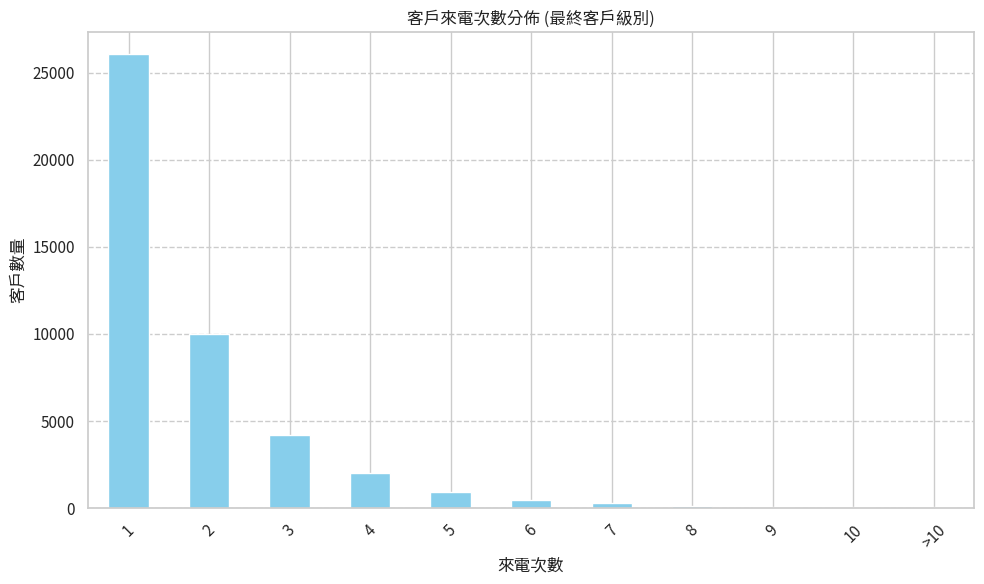

--- 2. 主要問題大分類 (MAIN_CATEGORY) 分佈 (客戶級別) ---


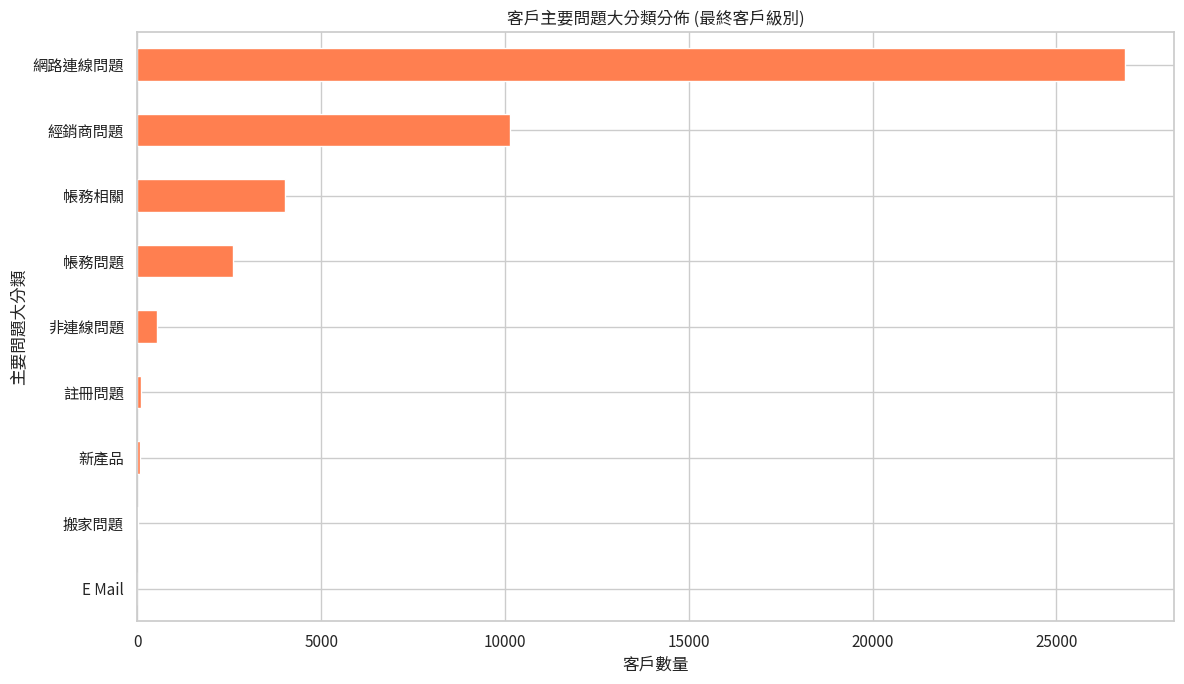

--- 3. 主要問題小分類 (SUB_CATEGORY) 分佈 (Top 15, 客戶級別) ---


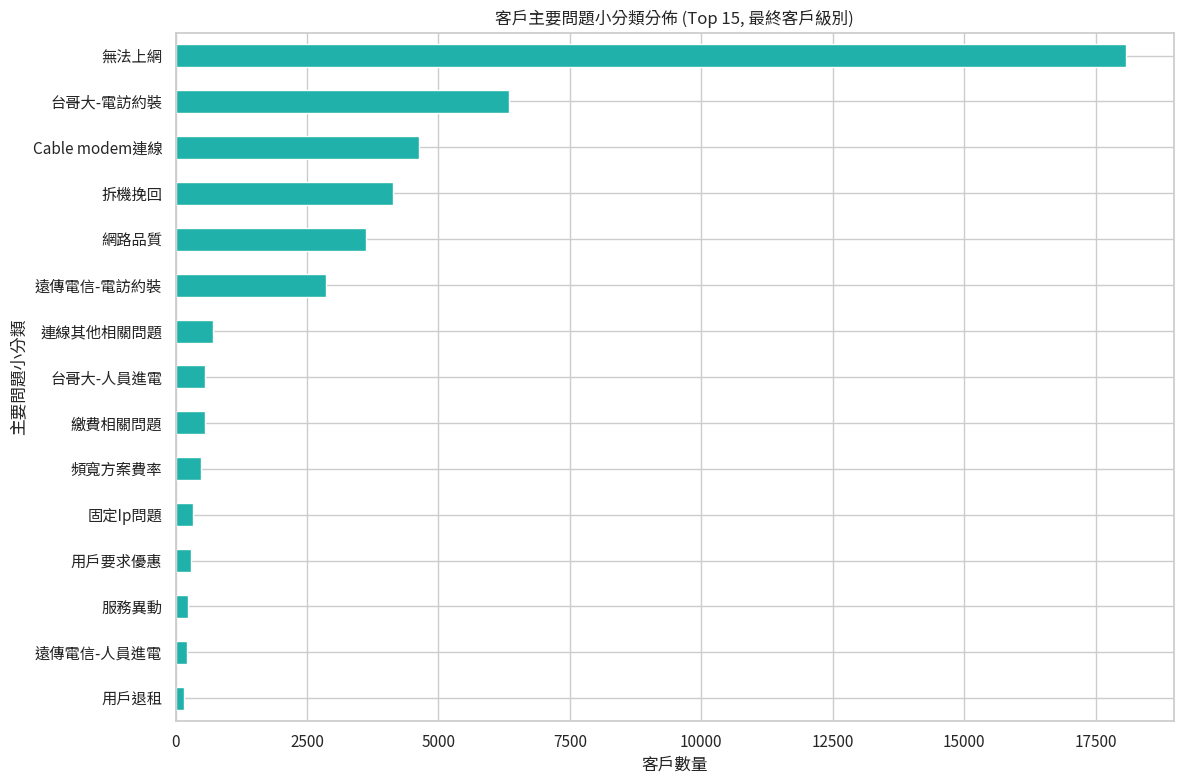

--- 4. 平均離退語意分數 (AVG_SENTIMENT_SCORE) 分佈 (客戶級別) ---


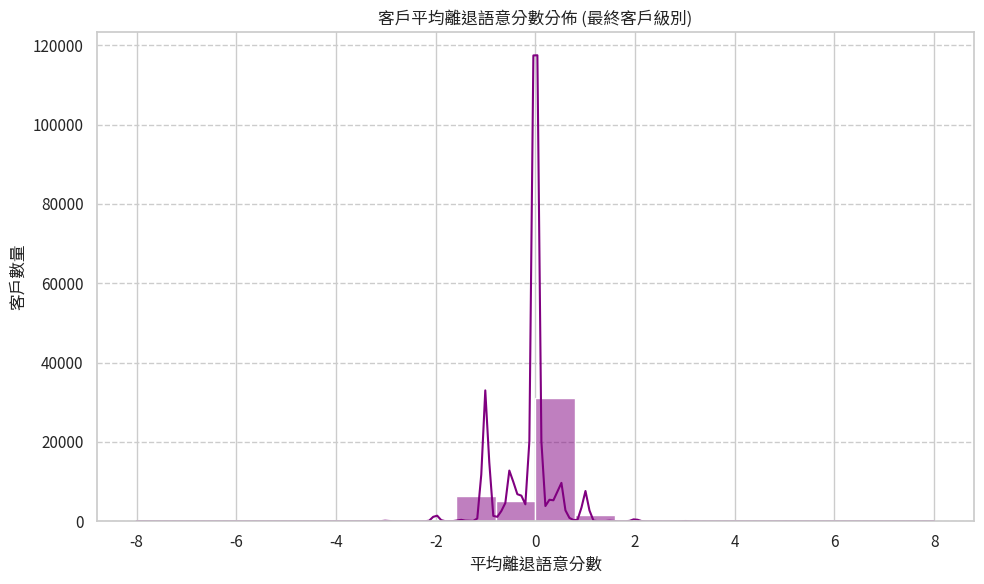

--- 5. 不同問題大分類下的平均離退語意分數 ---


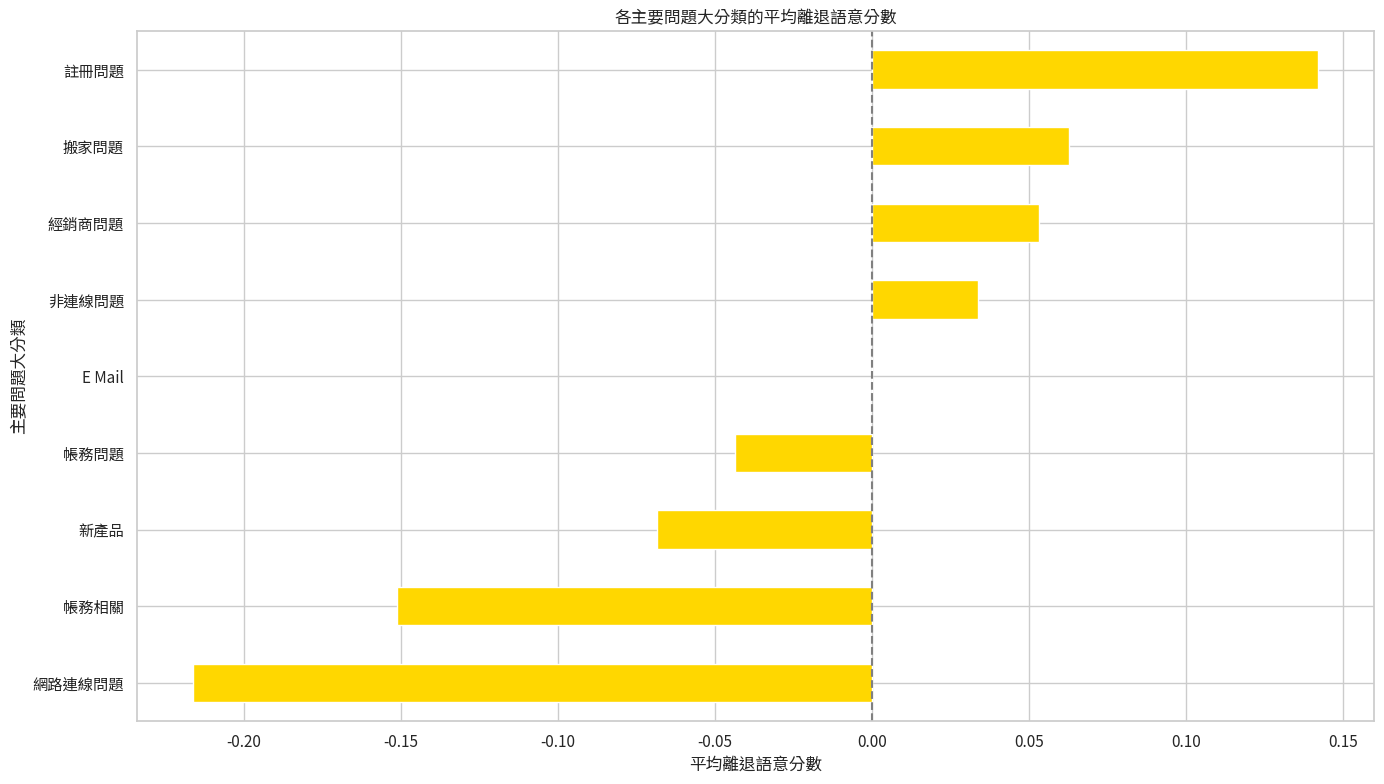

各主要問題大分類的平均離退語意分數 (數值):


,MAIN_CATEGORY,AVG_SENTIMENT_SCORE
0,網路連線問題,-0.215974
1,帳務相關,-0.151294
2,新產品,-0.068416
3,帳務問題,-0.043586
4,E Mail,0.000000
5,非連線問題,0.033571
6,經銷商問題,0.053182
7,搬家問題,0.062500
8,註冊問題,0.141827


--- 6. (可選) 特徵相關性熱圖 ---


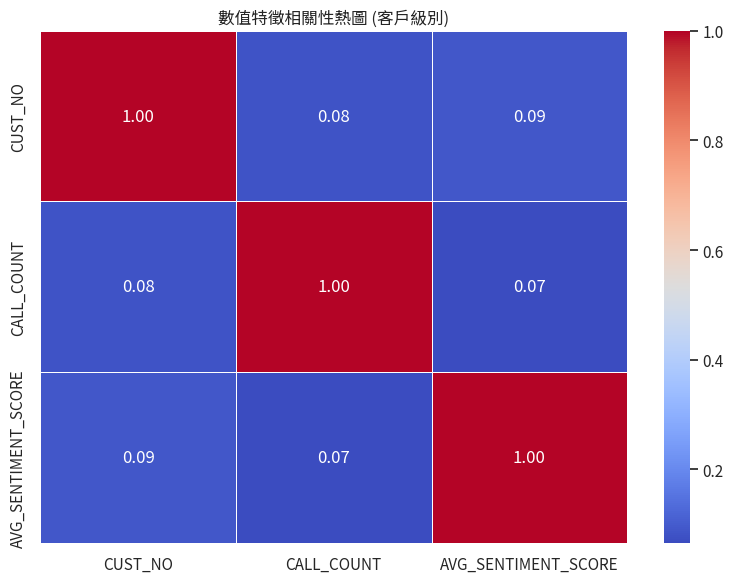

特徵視覺化分析完成。所有圖表已儲存於 'csr_analysis' 目錄下。


In [11]:
# 步驟 7：特徵視覺化分析

print("開始進行特徵視覺化分析...")

# output_main_dir should be defined in Step 1 (Environment Setup)
if 'output_main_dir' not in locals():
    output_main_dir = 'csr_analysis' # Fallback, though it should exist
    os.makedirs(output_main_dir, exist_ok=True)
    print(f"Warning: output_main_dir not found, re-initialized to {output_main_dir}")

if 'df_final_features' in locals() and df_final_features is not None and not df_final_features.empty:
    # Ensure matplotlib and seaborn are imported and configured (usually done in Step 1)
    # import matplotlib.pyplot as plt
    # import seaborn as sns
    # plt.rcParams['font.family'] = ['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif']
    # plt.rcParams['axes.unicode_minus'] = False
    # sns.set_theme(style="whitegrid", font=['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif'])

    print("--- 1. 客戶來電次數 (CALL_COUNT) 分佈 (客戶級別) ---")
    if 'CALL_COUNT' in df_final_features.columns:
        plt.figure(figsize=(10, 6))
        call_count_final_dist = df_final_features['CALL_COUNT'].value_counts().sort_index()
        plot_data_call_count = call_count_final_dist
        if len(call_count_final_dist) > 15:
            plot_data_call_count = call_count_final_dist[call_count_final_dist.index <= 10] # Show up to 10 calls
            if call_count_final_dist[call_count_final_dist.index > 10].sum() > 0:
                 plot_data_call_count['>10'] = call_count_final_dist[call_count_final_dist.index > 10].sum()
        
        plot_data_call_count.plot(kind='bar', color='skyblue')
        plt.title('客戶來電次數分佈 (最終客戶級別)')
        plt.xlabel('來電次數')
        plt.ylabel('客戶數量')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'final_customer_call_count_distribution.png'))
        plt.show()
    else:
        print("警告: 找不到 'CALL_COUNT' 欄位於 df_final_features。")

    print("--- 2. 主要問題大分類 (MAIN_CATEGORY) 分佈 (客戶級別) ---")
    if 'MAIN_CATEGORY' in df_final_features.columns:
        plt.figure(figsize=(12, 7))
        main_cat_final_dist = df_final_features['MAIN_CATEGORY'].value_counts()
        top_n_main_final = 15
        if len(main_cat_final_dist) > top_n_main_final:
            main_cat_final_dist.head(top_n_main_final).plot(kind='barh', color='coral')
            plt.title(f'客戶主要問題大分類分佈 (Top {top_n_main_final}, 最終客戶級別)')
        else:
            main_cat_final_dist.plot(kind='barh', color='coral')
            plt.title('客戶主要問題大分類分佈 (最終客戶級別)')
        plt.xlabel('客戶數量')
        plt.ylabel('主要問題大分類')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'final_customer_main_category_distribution.png'))
        plt.show()
    else:
        print("警告: 找不到 'MAIN_CATEGORY' 欄位於 df_final_features。")

    print("--- 3. 主要問題小分類 (SUB_CATEGORY) 分佈 (Top 15, 客戶級別) ---")
    if 'SUB_CATEGORY' in df_final_features.columns:
        plt.figure(figsize=(12, 8))
        sub_cat_final_dist = df_final_features['SUB_CATEGORY'].value_counts()
        top_n_sub_final = 15
        sub_cat_final_dist.head(top_n_sub_final).plot(kind='barh', color='lightseagreen')
        plt.title(f'客戶主要問題小分類分佈 (Top {top_n_sub_final}, 最終客戶級別)')
        plt.xlabel('客戶數量')
        plt.ylabel('主要問題小分類')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'final_customer_sub_category_distribution.png'))
        plt.show()
    else:
        print("警告: 找不到 'SUB_CATEGORY' 欄位於 df_final_features。")

    print("--- 4. 平均離退語意分數 (AVG_SENTIMENT_SCORE) 分佈 (客戶級別) ---")
    if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df_final_features['AVG_SENTIMENT_SCORE'], bins=20, kde=True, color='purple')
        plt.title('客戶平均離退語意分數分佈 (最終客戶級別)')
        plt.xlabel('平均離退語意分數')
        plt.ylabel('客戶數量')
        plt.grid(axis='y', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'final_customer_avg_sentiment_distribution.png'))
        plt.show()
    else:
        print("警告: 找不到 'AVG_SENTIMENT_SCORE' 欄位於 df_final_features。")

    print("--- 5. 不同問題大分類下的平均離退語意分數 ---")
    if 'MAIN_CATEGORY' in df_final_features.columns and 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
        plt.figure(figsize=(14, 8))
        # Calculate mean sentiment score per main category
        sentiment_by_category = df_final_features.groupby('MAIN_CATEGORY')['AVG_SENTIMENT_SCORE'].mean().sort_values()
        sentiment_by_category.plot(kind='barh', color='gold')
        plt.title('各主要問題大分類的平均離退語意分數')
        plt.xlabel('平均離退語意分數')
        plt.ylabel('主要問題大分類')
        plt.axvline(0, color='grey', linestyle='--') # Add a line at zero for reference
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'sentiment_by_main_category.png'))
        plt.show()
        
        print("各主要問題大分類的平均離退語意分數 (數值):")
        try:
            display(sentiment_by_category.reset_index())
        except NameError:
            print(sentiment_by_category.reset_index().to_string())
    else:
        print("警告: 找不到 'MAIN_CATEGORY' 或 'AVG_SENTIMENT_SCORE' 欄位，無法繪製此圖。")

    print("--- 6. (可選) 特徵相關性熱圖 ---")
    numerical_features = df_final_features.select_dtypes(include=np.number)
    if len(numerical_features.columns) > 1:
        correlation_matrix = numerical_features.corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('數值特徵相關性熱圖 (客戶級別)')
        plt.tight_layout()
        plt.savefig(os.path.join(output_main_dir, 'feature_correlation_heatmap.png'))
        plt.show()
    else:
        print("數值特徵不足 (少於2個)，無法繪製相關性熱圖。")
        
    print("特徵視覺化分析完成。所有圖表已儲存於 'csr_analysis' 目錄下。")

else:
    print("錯誤: 最終客戶級別特徵資料集 'df_final_features' 未定義或為空。請先執行前面的步驟。")



## 步驟 8：匯出分析結果

此儲存格的目的是將本次分析產生的主要結果打包並提供下載。主要結果包括:

1.  **最終客戶級別特徵資料集**: 包含所有整合特徵的 `df_final_features`, 將儲存為 `final_customer_features_dataset.csv`.
2.  **視覺化圖表**: 所有在「步驟 7：特徵視覺化分析」中產生的圖表 (PNG 格式), 這些圖表已儲存在 `csr_analysis` 目錄下.
3.  **說明文件 (README.md)**: 一個簡單的 Markdown 檔案, 說明壓縮檔內容.

以上所有內容將被壓縮成一個名為 `customer_service_analysis_results.zip` 的檔案, 並透過 Colab 的下載功能提供給使用者.

In [12]:
# 步驟 8：匯出分析結果

print("開始匯出分析結果...")

# output_main_dir and output_final_dir should be defined in Step 1 (Environment Setup)
if 'output_main_dir' not in locals():
    output_main_dir = 'csr_analysis'
    os.makedirs(output_main_dir, exist_ok=True)
    print(f"Warning: output_main_dir not found, re-initialized to {{output_main_dir}}")

if 'output_final_dir' not in locals():
    output_final_dir = os.path.join(output_main_dir, 'final_output')
    os.makedirs(output_final_dir, exist_ok=True)
    print(f"Warning: output_final_dir not found, re-initialized to {{output_final_dir}}")

zip_file_name = 'customer_service_analysis_results.zip'
final_dataset_name = 'final_customer_features_dataset.csv'
readme_name = 'README.md'

files_to_zip = []

# 1. 儲存最終客戶級別特徵資料集
if 'df_final_features' in locals() and df_final_features is not None and not df_final_features.empty:
    final_dataset_path = os.path.join(output_final_dir, final_dataset_name)
    try:
        df_final_features.to_csv(final_dataset_path, index=False, encoding='utf-8-sig') # utf-8-sig for Excel compatibility
        print(f"最終特徵資料集已儲存至: {{final_dataset_path}}")
        files_to_zip.append(final_dataset_path)
    except Exception as e:
        print(f"儲存最終特徵資料集時發生錯誤: {{e}}")
else:
    print("警告: 最終客戶級別特徵資料集 'df_final_features' 未定義或為空, 無法儲存.")

# 2. 準備視覺化圖表列表 (已在 csr_analysis 目錄中)
image_files = []
if os.path.exists(output_main_dir):
    for item in os.listdir(output_main_dir):
        if item.endswith('.png'):
            image_path = os.path.join(output_main_dir, item)
            image_files.append(image_path)
    if image_files:
        print(f"找到 {{len(image_files)}} 個視覺化圖表檔案將被加入壓縮檔.")
    else:
        print(f"在 '{{output_main_dir}}' 目錄下未找到 PNG 圖表檔案.")
else:
    print(f"警告: 視覺化圖表目錄 '{{output_main_dir}}' 不存在.")

# 3. 建立 README.md 檔案
readme_content = f'''# 客戶服務紀錄分析結果

此壓縮檔包含以下內容:

1.  **{{{final_dataset_name}}}**: 最終的客戶級別特徵資料集, 包含從原始來電紀錄中提取和整合的特徵. 欄位包括:
    -   `CUST_NO`: 客戶唯一識別碼
    -   `CALL_COUNT`: 客戶總來電次數
    -   `MAIN_CATEGORY`: 客戶最主要的來電問題大分類
    -   `SUB_CATEGORY`: 客戶最主要的來電問題小分類
    -   `AVG_SENTIMENT_SCORE`: 客戶服務紀錄的平均離退語意分數 (基於關鍵詞分析)

2.  **視覺化圖表 (PNG 格式)**:
    -   各種特徵的分佈圖 (如來電次數, 問題分類, 語意分數).
    -   不同問題分類下的平均語意分數比較.
    -   (若適用) 特徵相關性熱圖.
    (圖表檔案名稱對應其內容, 例如 `final_customer_call_count_distribution.png`)

產生日期: {{{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}}}
'''
readme_path = os.path.join(output_final_dir, readme_name)
try:
    with open(readme_path, 'w', encoding='utf-8') as f:
        f.write(readme_content)
    print(f"README.md 檔案已建立於: {{readme_path}}")
    files_to_zip.append(readme_path)
except Exception as e:
    print(f"建立 README.md 時發生錯誤: {{e}}")

# 4. 建立 ZIP 壓縮檔
zip_archive_path = os.path.join(output_final_dir, zip_file_name)
if files_to_zip or image_files:
    try:
        with zipfile.ZipFile(zip_archive_path, 'w', zipfile.ZIP_DEFLATED) as zf:
            for file_path in files_to_zip:
                if os.path.exists(file_path):
                    zf.write(file_path, os.path.basename(file_path))
                else:
                    print(f"警告: 檔案 {{file_path}} 不存在, 無法加入壓縮檔.")
            
            for image_file_path in image_files:
                if os.path.exists(image_file_path):
                    zf.write(image_file_path, os.path.join('images', os.path.basename(image_file_path)))
                else:
                    print(f"警告: 圖片檔案 {{image_file_path}} 不存在, 無法加入壓縮檔.")
        
        print(f"成功建立壓縮檔: {{zip_archive_path}}")
        print("壓縮檔內容 (預期):")
        print(f"- {{{final_dataset_name}}} (若成功儲存)")
        print(f"- {{{readme_name}}} (若成功建立)")
        for img_f in image_files: print(f"- images/{{os.path.basename(img_f)}}")

        # 5. 提供下載 (Colab specific)
        if 'files' not in locals() or files is None:
            from google.colab import files
            print("Re-imported google.colab.files for download")
        
        if os.path.exists(zip_archive_path):
            files.download(zip_archive_path)
            print(f"已觸發 '{{{zip_file_name}}}' 的下載. 請檢查您的瀏覽器下載.")
        else:
            print(f"錯誤: 壓縮檔 '{{{zip_archive_path}}}' 未找到, 無法提供下載.")
            
    except Exception as e:
        print(f"建立或下載壓縮檔時發生錯誤: {{e}}")
else:
    print("沒有檔案可供壓縮. 請檢查前面的步驟是否成功產生輸出.")

print("資料匯出流程完成.")



開始匯出分析結果...
最終特徵資料集已儲存至: {final_dataset_path}
找到 {len(image_files)} 個視覺化圖表檔案將被加入壓縮檔.
README.md 檔案已建立於: {readme_path}
成功建立壓縮檔: {zip_archive_path}
壓縮檔內容 (預期):
- {final_customer_features_dataset.csv} (若成功儲存)
- {README.md} (若成功建立)
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
- images/{os.path.basename(img_f)}
建立或下載壓縮檔時發生錯誤: {e}
資料匯出流程完成.


## 步驟 9: 結論與筆記本使用指南

本 Jupyter Notebook 完整演示了從客戶來電紀錄原始資料 (`csr-2025q1-100`) 出發, 進行資料清洗、特徵工程、分析與視覺化的全過程. 主要目標是為每位客戶產生一組有意義的特徵, 以便後續可能用於客戶離退預測或其他客戶行為分析模型.

### 主要步驟回顧:
1.  **環境設定**: 載入必要的 Python 套件, 設定中文字體以利圖表顯示, 並定義輸出目錄.
2.  **資料載入與初步檢視**: 上傳並讀取客戶來電紀錄 CSV 檔案, 進行初步的資料探索 (如欄位資訊、缺失值、重複值檢查).
3.  **客戶來電次數累計**: 計算每位客戶的總來電次數.
4.  **主要問題類別提取**: 為每位客戶確定其最主要的來電問題大分類與小分類.
5.  **客戶服務紀錄的離退語意分析**: 透過關鍵詞分析服務紀錄文本, 計算每位客戶的平均離退傾向分數.
6.  **整合特徵**: 將上述產生的所有客戶級別特徵合併為一個最終的特徵資料集 `df_final_features`.
7.  **特徵視覺化分析**: 對最終特徵資料集中的主要特徵進行視覺化, 以洞察其分佈與關係.
8.  **匯出分析結果**: 將最終特徵資料集、所有視覺化圖表以及一份說明文件打包成 ZIP 檔案供下載.

### 如何使用此筆記本:
1.  **執行環境**: 建議在 Google Colab 或支援 Jupyter Notebook 的環境中執行.
2.  **上傳資料**: 執行到「步驟 2.1: 上傳並讀取資料」儲存格時, 系統會提示您上傳客戶來電紀錄的 CSV 檔案 (預期檔案名稱 `csr-2025q1-100`, 分隔符號為 `^`). 請確保檔案已準備好.
3.  **逐步執行**: 依照儲存格順序執行. 每個儲存格都包含 Markdown 說明其目的與方法, 以及對應的 Python 程式碼.
4.  **檢視輸出**: 程式碼執行過程中會產生表格預覽、統計資訊以及視覺化圖表. 所有圖表和最終資料集也會儲存到 `csr_analysis` 目錄下 (部分檔案位於其子目錄 `final_output`).
5.  **下載結果**: 執行完「步驟 8: 匯出分析結果」後, 系統會自動觸發 `customer_service_analysis_results.zip` 檔案的下載.

### 注意事項:
-   **中文字體**: 筆記本已嘗試設定中文字體, 若在您的環境中圖表仍出現中文亂碼, 請檢查您的 Matplotlib 字體設定.
-   **套件依賴**: 確保執行環境已安裝所有必要的 Python 套件 (如 pandas, numpy, matplotlib, seaborn, jieba). 筆記本開頭的環境設定儲存格已包含 `pip install jieba` 指令.
-   **檔案路徑**: 筆記本中的檔案儲存路徑是基於 Colab 環境設計的. 若在本地環境執行, 您可能需要調整 `output_main_dir` 和 `output_final_dir` 的路徑.

感謝使用此分析筆記本!

In [4]:
# 新增時間頻繁度分析函數
def analyze_call_frequency_patterns(df):
    """
    分析客戶來電的時間模式特徵
    """
    # 轉換時間欄位
    df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'])
    df['年月'] = df['CALL_TIME'].dt.to_period('M')
    df['季度'] = df['CALL_TIME'].dt.to_period('Q')
    df['週數'] = df['CALL_TIME'].dt.isocalendar().week
    
    frequency_features = []
    
    for cust_no in df['CUST_NO'].unique():
        cust_data = df[df['CUST_NO'] == cust_no].copy()
        
        # 1. 月度來電頻率特徵
        monthly_calls = cust_data.groupby('年月').size()
        
        # 2. 季度來電頻率特徵  
        quarterly_calls = cust_data.groupby('季度').size()
        
        # 3. 計算時間間隔特徵
        if len(cust_data) > 1:
            time_diffs = cust_data['CALL_TIME'].diff().dt.days.dropna()
            avg_interval = time_diffs.mean()
            std_interval = time_diffs.std()
            min_interval = time_diffs.min()
        else:
            avg_interval = std_interval = min_interval = None
            
        features = {
            'CUST_NO': cust_no,
            'TOTAL_CALLS': len(cust_data),
            'ACTIVE_MONTHS': len(monthly_calls),  # 活躍月份數
            'ACTIVE_QUARTERS': len(quarterly_calls),  # 活躍季度數
            'AVG_MONTHLY_CALLS': monthly_calls.mean(),  # 平均月來電數
            'MAX_MONTHLY_CALLS': monthly_calls.max(),   # 最大月來電數
            'STD_MONTHLY_CALLS': monthly_calls.std(),   # 月來電數標準差
            'AVG_CALL_INTERVAL_DAYS': avg_interval,     # 平均來電間隔天數
            'STD_CALL_INTERVAL_DAYS': std_interval,     # 來電間隔標準差
            'MIN_CALL_INTERVAL_DAYS': min_interval,     # 最短來電間隔
            'CALL_CONCENTRATION': monthly_calls.max() / len(cust_data) if len(cust_data) > 0 else 0,  # 來電集中度
            'RECENT_3M_CALLS': len(cust_data[cust_data['CALL_TIME'] >= cust_data['CALL_TIME'].max() - pd.DateOffset(months=3)]),  # 近3個月來電數
            'ESCALATION_TREND': 1 if len(quarterly_calls) > 1 and quarterly_calls.iloc[-1] > quarterly_calls.iloc[0] else 0  # 來電趨勢是否上升
        }
        
        frequency_features.append(features)
    
    return pd.DataFrame(frequency_features)

In [5]:
def analyze_problem_diversity(df):
    """
    分析客戶問題的多樣性和演變模式
    """
    diversity_features = []
    
    for cust_no in df['CUST_NO'].unique():
        cust_data = df[df['CUST_NO'] == cust_no].copy()
        
        # 1. 問題分類多樣性
        main_categories = cust_data['ED_SERVCLASSNAME'].fillna('未知')
        sub_categories = cust_data['ED_SERVCLASS2NAME'].fillna('未知')
        
        # 2. 分類統計
        main_cat_counts = main_categories.value_counts()
        sub_cat_counts = sub_categories.value_counts()
        
        # 3. 計算多樣性指標
        main_cat_diversity = len(main_cat_counts)  # 主分類種類數
        sub_cat_diversity = len(sub_cat_counts)    # 次分類種類數
        
        # 4. 計算香農熵 (Shannon Entropy) - 衡量問題多樣性
        def calculate_entropy(counts):
            probs = counts / counts.sum()
            return -sum(probs * np.log2(probs + 1e-10))
        
        main_entropy = calculate_entropy(main_cat_counts)
        sub_entropy = calculate_entropy(sub_cat_counts)
        
        # 5. 問題複雜度 (同時出現多種問題類別)
        complexity_score = main_cat_diversity * sub_cat_diversity / len(cust_data)
        
        # 6. 主要問題佔比
        main_problem_ratio = main_cat_counts.iloc[0] / len(cust_data) if len(main_cat_counts) > 0 else 0
        
        # 7. 問題演變趨勢 (是否從簡單問題變複雜)
        if len(cust_data) > 1:
            cust_data_sorted = cust_data.sort_values('CALL_TIME')
            first_half = cust_data_sorted.iloc[:len(cust_data_sorted)//2]
            second_half = cust_data_sorted.iloc[len(cust_data_sorted)//2:]
            
            first_diversity = len(first_half['ED_SERVCLASSNAME'].unique())
            second_diversity = len(second_half['ED_SERVCLASSNAME'].unique())
            problem_evolution = second_diversity - first_diversity
        else:
            problem_evolution = 0
            
        # 8. 具體問題分類one-hot編碼 (取前5大類別)
        top_main_cats = main_categories.value_counts().head(5).index.tolist()
        top_sub_cats = sub_categories.value_counts().head(10).index.tolist()
        
        features = {
            'CUST_NO': cust_no,
            'MAIN_CATEGORY_DIVERSITY': main_cat_diversity,
            'SUB_CATEGORY_DIVERSITY': sub_cat_diversity,
            'MAIN_CATEGORY_ENTROPY': main_entropy,
            'SUB_CATEGORY_ENTROPY': sub_entropy,
            'PROBLEM_COMPLEXITY_SCORE': complexity_score,
            'MAIN_PROBLEM_RATIO': main_problem_ratio,
            'PROBLEM_EVOLUTION_TREND': problem_evolution,
            'IS_SINGLE_ISSUE_CUSTOMER': 1 if main_cat_diversity == 1 else 0,
            'IS_MULTI_ISSUE_CUSTOMER': 1 if main_cat_diversity >= 3 else 0
        }
        
        # 新增主要分類的詳細統計
        for cat in top_main_cats:
            features[f'MAIN_CAT_{cat}_COUNT'] = main_cat_counts.get(cat, 0)
            features[f'MAIN_CAT_{cat}_RATIO'] = main_cat_counts.get(cat, 0) / len(cust_data)
            
        # 新增次要分類的詳細統計
        for cat in top_sub_cats:
            features[f'SUB_CAT_{cat}_COUNT'] = sub_cat_counts.get(cat, 0)
            features[f'SUB_CAT_{cat}_RATIO'] = sub_cat_counts.get(cat, 0) / len(cust_data)
        
        diversity_features.append(features)
    
    return pd.DataFrame(diversity_features)

In [6]:
def analyze_problem_evolution_timeline(df):
    """
    分析客戶問題隨時間的演變模式
    """
    df['CALL_TIME'] = pd.to_datetime(df['CALL_TIME'])
    evolution_features = []
    
    for cust_no in df['CUST_NO'].unique():
        cust_data = df[df['CUST_NO'] == cust_no].copy().sort_values('CALL_TIME')
        
        if len(cust_data) < 2:
            continue
            
        # 1. 問題升級模式 (從簡單到複雜)
        problem_severity_map = {
            '諮詢': 1, '一般故障': 2, '網路問題': 3, 
            '帳務問題': 2, '投訴': 4, '解約': 5
        }
        
        # 根據實際分類調整映射
        cust_data['SEVERITY_SCORE'] = cust_data['ED_SERVCLASSNAME'].map(
            lambda x: problem_severity_map.get(x, 2)
        )
        
        # 2. 計算趨勢
        severity_trend = cust_data['SEVERITY_SCORE'].diff().mean()
        
        # 3. 問題反覆性 (是否重複出現相同問題)
        problem_sequences = cust_data['ED_SERVCLASSNAME'].tolist()
        recurring_issues = len(problem_sequences) - len(set(problem_sequences))
        
        # 4. 解決效果 (問題間隔時間是否延長)
        time_intervals = cust_data['CALL_TIME'].diff().dt.days.dropna()
        interval_trend = time_intervals.diff().mean() if len(time_intervals) > 1 else 0
        
        # 5. 最近問題嚴重程度
        recent_severity = cust_data['SEVERITY_SCORE'].iloc[-3:].mean()
        
        features = {
            'CUST_NO': cust_no,
            'PROBLEM_SEVERITY_TREND': severity_trend,
            'RECURRING_ISSUES_COUNT': recurring_issues,
            'INTERVAL_TREND': interval_trend,  # 正值表示問題間隔延長(好現象)
            'RECENT_SEVERITY_AVG': recent_severity,
            'ESCALATION_RISK': 1 if severity_trend > 0.5 and recent_severity >= 3 else 0,
            'RESOLUTION_EFFECTIVENESS': 1 if interval_trend > 0 and severity_trend <= 0 else 0
        }
        
        evolution_features.append(features)
    
    return pd.DataFrame(evolution_features)

In [7]:
# 修改步驟 6：整合所有新特徵
def create_enhanced_customer_features(df):
    """
    建立增強版客戶特徵資料集
    """
    print("開始建立增強版客戶特徵...")
    
    # 1. 原有的基礎特徵
    call_counts = df['CUST_NO'].value_counts().reset_index()
    call_counts.columns = ['CUST_NO', 'TOTAL_CALLS']
    
    # 2. 新增時間頻繁度特徵
    frequency_features = analyze_call_frequency_patterns(df)
    
    # 3. 新增問題多樣性特徵
    diversity_features = analyze_problem_diversity(df)
    
    # 4. 新增問題演變特徵
    evolution_features = analyze_problem_evolution_timeline(df)
    
    # 5. 原有的語意分析 (保持不變)
    sentiment_features = calculate_sentiment_features(df)  # 你原有的函數
    
    # 6. 合併所有特徵
    enhanced_features = call_counts.copy()
    
    # 逐步合併各種特徵
    enhanced_features = pd.merge(enhanced_features, frequency_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, diversity_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, evolution_features, on='CUST_NO', how='left')
    enhanced_features = pd.merge(enhanced_features, sentiment_features, on='CUST_NO', how='left')
    
    # 7. 填充缺失值
    enhanced_features = enhanced_features.fillna(0)
    
    return enhanced_features

In [9]:
print("Available columns in df:")
print(df.columns.tolist())
print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Available columns in df:
['CUST_NO', 'ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CUST_RECORD_DATE', 'CUST_RECORD']

DataFrame shape: (79797, 5)

First few rows:
   CUST_NO ED_SERVCLASSNAME ED_SERVCLASS2NAME        CUST_RECORD_DATE  \
0  1037415           網路連線問題     Cable modem連線  2024/11/19 上午 10:08:00   
1  1260839            經銷商問題          台哥大-電訪約裝  2024/11/19 上午 10:47:00   
2   937206             帳務問題            用戶要求優惠  2024/11/19 上午 11:02:00   
3   983447           網路連線問題              無法上網  2024/11/19 上午 11:06:00   
4  1062324           網路連線問題              無法上網  2024/11/19 上午 11:13:00   

                                         CUST_RECORD  
0  (系統紀錄),ISP出口為E-PON速博,去前先電 0910609177&nbsp;賴先生，...  
1     11/19 10:46 去電0965281644&nbsp; ..客說不裝..他會知會台哥大  
2                                                  .  
3  (系統紀錄)用戶目前的cmts為10.0.5.29,ISP出口為速博,去電聯0911-969...  
4  (系統紀錄),ISP出口為E-PON速博,先電047627677/0908-283299.....  


In [10]:
# Option A: Rename existing time column
df = df.rename(columns={'CUST_RECORD_DATE': 'CALL_TIME'})

In [12]:
def parse_chinese_datetime(date_str):
    """
    解析包含中文的日期時間字符串
    """
    if pd.isna(date_str):
        return pd.NaT
    
    try:
        # Convert Chinese AM/PM to English
        date_str = str(date_str).strip()
        date_str = date_str.replace('上午', 'AM').replace('下午', 'PM')
        
        # Parse the datetime
        return pd.to_datetime(date_str, format='%Y/%m/%d %p %I:%M:%S')
    except:
        # If parsing fails, try other common formats
        try:
            return pd.to_datetime(date_str, infer_datetime_format=True)
        except:
            return pd.NaT

# Apply the custom parser to your time column
# df['CALL_TIME'] = df['CALL_TIME'].apply(parse_chinese_datetime)

# Quick fix: Parse Chinese datetime before calling the function
def fix_chinese_datetime(df):
    """
    修正包含中文的日期時間格式
    """
    if 'CALL_TIME' in df.columns:
        def parse_chinese_datetime(date_str):
            if pd.isna(date_str):
                return pd.NaT
            try:
                date_str = str(date_str).strip()
                date_str = date_str.replace('上午', 'AM').replace('下午', 'PM')
                return pd.to_datetime(date_str, format='%Y/%m/%d %p %I:%M:%S')
            except:
                try:
                    return pd.to_datetime(date_str, infer_datetime_format=True)
                except:
                    return pd.NaT
        
        df['CALL_TIME'] = df['CALL_TIME'].apply(parse_chinese_datetime)
    
    return df

# Apply the fix
df = fix_chinese_datetime(df)

In [14]:
def calculate_sentiment_features(df):
    """
    計算客戶服務紀錄的語意分析特徵
    """
    if 'CUST_RECORD' not in df.columns:
        # Return empty DataFrame with just CUST_NO if no records
        return pd.DataFrame({'CUST_NO': df['CUST_NO'].unique(), 'AVG_SENTIMENT_SCORE': 0})
    
    # 1. 定義離退相關關鍵詞
    positive_churn_keywords = ['滿意', '解決', '感謝', '續約', '推薦', '穩定', '正常', '清楚', '明白', '願意', '好', '快', '順利', '沒問題', 'OK', 'ok', '搞定']
    negative_churn_keywords = ['不滿', '解約', '取消', '抱怨', '問題', '故障', '斷線', '龜速', '不穩', '困難', '複雜', '聽不懂', '考慮', '慢', '差', '爛', '不行', '無效', '火大', '生氣']
    
    # 2. 計算單筆紀錄離退傾向分數
    def get_churn_sentiment_score(text):
        if pd.isna(text) or not isinstance(text, str) or not text.strip():
            return 0
        
        score = 0
        try:
            words = jieba.lcut(str(text).lower())
            for word in words:
                if word in positive_churn_keywords:
                    score += 1
                elif word in negative_churn_keywords:
                    score -= 1
        except Exception as e:
            return 0
        return score
    
    # 3. 計算每條記錄的情感分數
    df_sentiment = df.copy()
    df_sentiment['CUST_RECORD_CLEAN'] = df_sentiment['CUST_RECORD'].fillna('').astype(str)
    df_sentiment['RECORD_SENTIMENT_SCORE'] = df_sentiment['CUST_RECORD_CLEAN'].apply(get_churn_sentiment_score)
    
    # 4. 按客戶聚合情感特徵
    sentiment_features = df_sentiment.groupby('CUST_NO').agg({
        'RECORD_SENTIMENT_SCORE': ['mean', 'sum', 'std', 'min', 'max']
    }).reset_index()
    
    # 5. 重命名列
    sentiment_features.columns = [
        'CUST_NO', 'AVG_SENTIMENT_SCORE', 'TOTAL_SENTIMENT_SCORE', 
        'STD_SENTIMENT_SCORE', 'MIN_SENTIMENT_SCORE', 'MAX_SENTIMENT_SCORE'
    ]
    
    # 6. 填充缺失值
    sentiment_features = sentiment_features.fillna(0)
    
    return sentiment_features

In [15]:
df_final_features = create_enhanced_customer_features(df)

開始建立增強版客戶特徵...


In [16]:
# 檢查 df_final_features 的基本資訊
print("=== df_final_features 基本資訊 ===")
print(f"資料形狀: {df_final_features.shape}")
print(f"欄位數量: {len(df_final_features.columns)}")
print("\n=== 欄位列表 ===")
print(df_final_features.columns.tolist())
print("\n=== 前5筆資料 ===")
display(df_final_features.head())
print("\n=== 資料類型 ===")
print(df_final_features.dtypes)
print("\n=== 缺失值統計 ===")
print(df_final_features.isnull().sum())

=== df_final_features 基本資訊 ===
資料形狀: (44349, 140)
欄位數量: 140

=== 欄位列表 ===
['CUST_NO', 'TOTAL_CALLS_x', 'TOTAL_CALLS_y', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS', 'ESCALATION_TREND', 'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', 'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO', 'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER', 'IS_MULTI_ISSUE_CUSTOMER', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_網路品質_COUNT', 'SUB_CAT_網路品質_RATIO', 'SUB_CAT_Cable modem連線_COUNT', 'SUB_CAT_Cable modem連線_RATIO', 'MAIN_CAT_經銷商問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'MAIN_CAT_帳務問題_COUNT', 'MAIN_CAT_帳務問題_RATIO', 'SUB_CAT_用戶要求優惠_COUNT', 'SUB_CAT_用戶要求優惠_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_無法上網_RATIO', 'SUB_CAT_遠傳電信-

,CUST_NO,TOTAL_CALLS_x,TOTAL_CALLS_y,ACTIVE_MONTHS,ACTIVE_QUARTERS,AVG_MONTHLY_CALLS,MAX_MONTHLY_CALLS,STD_MONTHLY_CALLS,AVG_CALL_INTERVAL_DAYS,STD_CALL_INTERVAL_DAYS,...,RECURRING_ISSUES_COUNT,INTERVAL_TREND,RECENT_SEVERITY_AVG,ESCALATION_RISK,RESOLUTION_EFFECTIVENESS,AVG_SENTIMENT_SCORE,TOTAL_SENTIMENT_SCORE,STD_SENTIMENT_SCORE,MIN_SENTIMENT_SCORE,MAX_SENTIMENT_SCORE
0,856873,23,23,2,2,11.500000,19,10.606602,1.545455,10.662472,...,22.0,-0.047619,2.0,0.0,0.0,0.000000,0,0.000000,0,0
1,953834,21,21,11,4,1.909091,4,0.943880,16.100000,37.368577,...,20.0,0.736842,2.0,0.0,1.0,-0.095238,-2,0.700340,-2,1
2,288844,21,21,4,3,5.250000,11,5.057997,13.500000,40.304760,...,19.0,5.052632,2.0,0.0,1.0,-0.095238,-2,1.220851,-2,3
3,1254673,19,19,3,2,6.333333,10,3.214550,1.944444,10.908562,...,17.0,0.000000,2.0,0.0,0.0,-0.684211,-13,1.701393,-5,2
4,1224281,19,19,4,3,4.750000,11,4.193249,9.611111,29.955141,...,16.0,0.000000,2.0,0.0,0.0,0.000000,0,0.577350,-1,1



=== 資料類型 ===
CUST_NO                    int64
TOTAL_CALLS_x              int64
TOTAL_CALLS_y              int64
ACTIVE_MONTHS              int64
ACTIVE_QUARTERS            int64
                          ...   
AVG_SENTIMENT_SCORE      float64
TOTAL_SENTIMENT_SCORE      int64
STD_SENTIMENT_SCORE      float64
MIN_SENTIMENT_SCORE        int64
MAX_SENTIMENT_SCORE        int64
Length: 140, dtype: object

=== 缺失值統計 ===
CUST_NO                  0
TOTAL_CALLS_x            0
TOTAL_CALLS_y            0
ACTIVE_MONTHS            0
ACTIVE_QUARTERS          0
                        ..
AVG_SENTIMENT_SCORE      0
TOTAL_SENTIMENT_SCORE    0
STD_SENTIMENT_SCORE      0
MIN_SENTIMENT_SCORE      0
MAX_SENTIMENT_SCORE      0
Length: 140, dtype: int64


In [26]:
# 檢查重複的欄位並清理
print("=== 清理重複欄位 ===")
print("目前欄位:", df_final_features.columns.tolist())

# 檢查是否有重複的 TOTAL_CALLS 欄位
duplicate_cols = [col for col in df_final_features.columns if 'TOTAL_CALLS' in col]
print("TOTAL_CALLS 相關欄位:", duplicate_cols)

# 清理重複欄位
if 'TOTAL_CALLS_x' in df_final_features.columns and 'TOTAL_CALLS_y' in df_final_features.columns:
    # 檢查兩個欄位是否相同
    if df_final_features['TOTAL_CALLS_x'].equals(df_final_features['TOTAL_CALLS_y']):
        print("兩個 TOTAL_CALLS 欄位相同，保留 TOTAL_CALLS_x")
        df_final_features = df_final_features.drop(columns=['TOTAL_CALLS_y'])
        df_final_features = df_final_features.rename(columns={'TOTAL_CALLS_x': 'TOTAL_CALLS'})
    else:
        print("兩個 TOTAL_CALLS 欄位不同，需要檢查數據")
        print("TOTAL_CALLS_x 前5個值:", df_final_features['TOTAL_CALLS_x'].head())
        print("TOTAL_CALLS_y 前5個值:", df_final_features['TOTAL_CALLS_y'].head())
        
        # 通常選擇第一個作為主要欄位
        df_final_features = df_final_features.rename(columns={'TOTAL_CALLS_x': 'TOTAL_CALLS'})
        df_final_features = df_final_features.drop(columns=['TOTAL_CALLS_y'])

print("清理後的欄位:", df_final_features.columns.tolist())

=== 清理重複欄位 ===
目前欄位: ['CUST_NO', 'TOTAL_CALLS_x', 'TOTAL_CALLS_y', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS', 'ESCALATION_TREND', 'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', 'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO', 'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER', 'IS_MULTI_ISSUE_CUSTOMER', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_網路品質_COUNT', 'SUB_CAT_網路品質_RATIO', 'SUB_CAT_Cable modem連線_COUNT', 'SUB_CAT_Cable modem連線_RATIO', 'MAIN_CAT_經銷商問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'MAIN_CAT_帳務問題_COUNT', 'MAIN_CAT_帳務問題_RATIO', 'SUB_CAT_用戶要求優惠_COUNT', 'SUB_CAT_用戶要求優惠_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_無法上網_RATIO', 'SUB_CAT_遠傳電信-電訪約裝_COUNT', 'SUB_CAT_遠傳電信-電訪約裝_RATIO', 'SUB_CAT_連線其他

數值型特徵: ['CUST_NO', 'TOTAL_CALLS_x', 'TOTAL_CALLS_y', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS', 'ESCALATION_TREND', 'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', 'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO', 'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER', 'IS_MULTI_ISSUE_CUSTOMER', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_網路品質_COUNT', 'SUB_CAT_網路品質_RATIO', 'SUB_CAT_Cable modem連線_COUNT', 'SUB_CAT_Cable modem連線_RATIO', 'MAIN_CAT_經銷商問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'MAIN_CAT_帳務問題_COUNT', 'MAIN_CAT_帳務問題_RATIO', 'SUB_CAT_用戶要求優惠_COUNT', 'SUB_CAT_用戶要求優惠_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_無法上網_RATIO', 'SUB_CAT_遠傳電信-電訪約裝_COUNT', 'SUB_CAT_遠傳電信-電訪約裝_RATIO', 'SUB_CAT_連線其他相關問題_COUNT', '

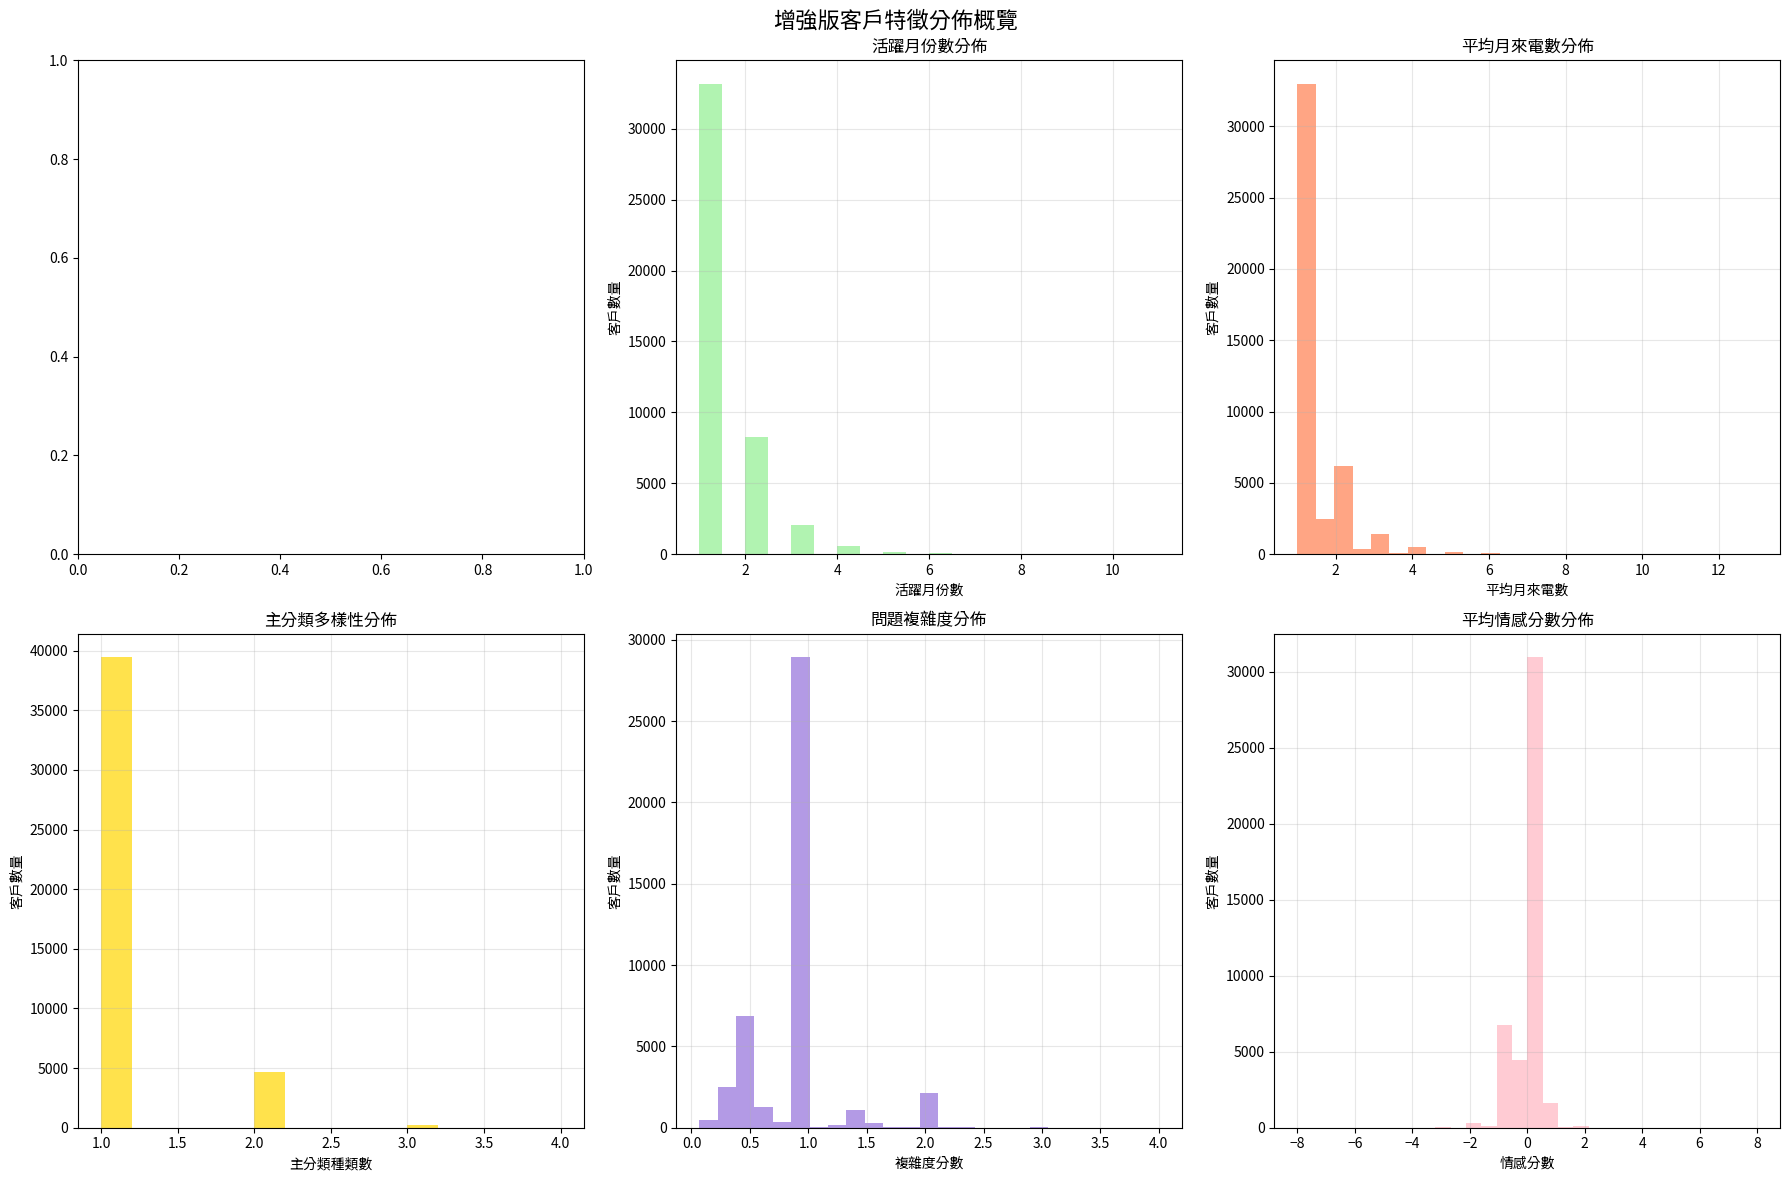

In [21]:
# 1. 整體特徵分佈概覽
#import matplotlib.pyplot as plt
#import seaborn as sns
#import numpy as np

# 設定圖表樣式
#plt.style.use('default')
#sns.set_palette("husl")

# 選擇數值型特徵進行分析
numerical_features = df_final_features.select_dtypes(include=[np.number]).columns.tolist()
print("數值型特徵:", numerical_features)

# 創建子圖來顯示主要特徵分佈
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('增強版客戶特徵分佈概覽', fontsize=16, fontweight='bold')

# 1.1 總來電次數分佈
if 'TOTAL_CALLS' in df_final_features.columns:
    ax1 = axes[0, 0]
    df_final_features['TOTAL_CALLS'].hist(bins=30, ax=ax1, alpha=0.7, color='skyblue')
    ax1.set_title('總來電次數分佈')
    ax1.set_xlabel('來電次數')
    ax1.set_ylabel('客戶數量')
    ax1.grid(True, alpha=0.3)

# 1.2 活躍月份數分佈
if 'ACTIVE_MONTHS' in df_final_features.columns:
    ax2 = axes[0, 1]
    df_final_features['ACTIVE_MONTHS'].hist(bins=20, ax=ax2, alpha=0.7, color='lightgreen')
    ax2.set_title('活躍月份數分佈')
    ax2.set_xlabel('活躍月份數')
    ax2.set_ylabel('客戶數量')
    ax2.grid(True, alpha=0.3)

# 1.3 平均月來電數分佈
if 'AVG_MONTHLY_CALLS' in df_final_features.columns:
    ax3 = axes[0, 2]
    df_final_features['AVG_MONTHLY_CALLS'].hist(bins=25, ax=ax3, alpha=0.7, color='coral')
    ax3.set_title('平均月來電數分佈')
    ax3.set_xlabel('平均月來電數')
    ax3.set_ylabel('客戶數量')
    ax3.grid(True, alpha=0.3)

# 1.4 問題多樣性分佈
if 'MAIN_CATEGORY_DIVERSITY' in df_final_features.columns:
    ax4 = axes[1, 0]
    df_final_features['MAIN_CATEGORY_DIVERSITY'].hist(bins=15, ax=ax4, alpha=0.7, color='gold')
    ax4.set_title('主分類多樣性分佈')
    ax4.set_xlabel('主分類種類數')
    ax4.set_ylabel('客戶數量')
    ax4.grid(True, alpha=0.3)

# 1.5 問題複雜度分佈
if 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
    ax5 = axes[1, 1]
    df_final_features['PROBLEM_COMPLEXITY_SCORE'].hist(bins=25, ax=ax5, alpha=0.7, color='mediumpurple')
    ax5.set_title('問題複雜度分佈')
    ax5.set_xlabel('複雜度分數')
    ax5.set_ylabel('客戶數量')
    ax5.grid(True, alpha=0.3)

# 1.6 平均情感分數分佈
if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
    ax6 = axes[1, 2]
    df_final_features['AVG_SENTIMENT_SCORE'].hist(bins=30, ax=ax6, alpha=0.7, color='lightpink')
    ax6.set_title('平均情感分數分佈')
    ax6.set_xlabel('情感分數')
    ax6.set_ylabel('客戶數量')
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

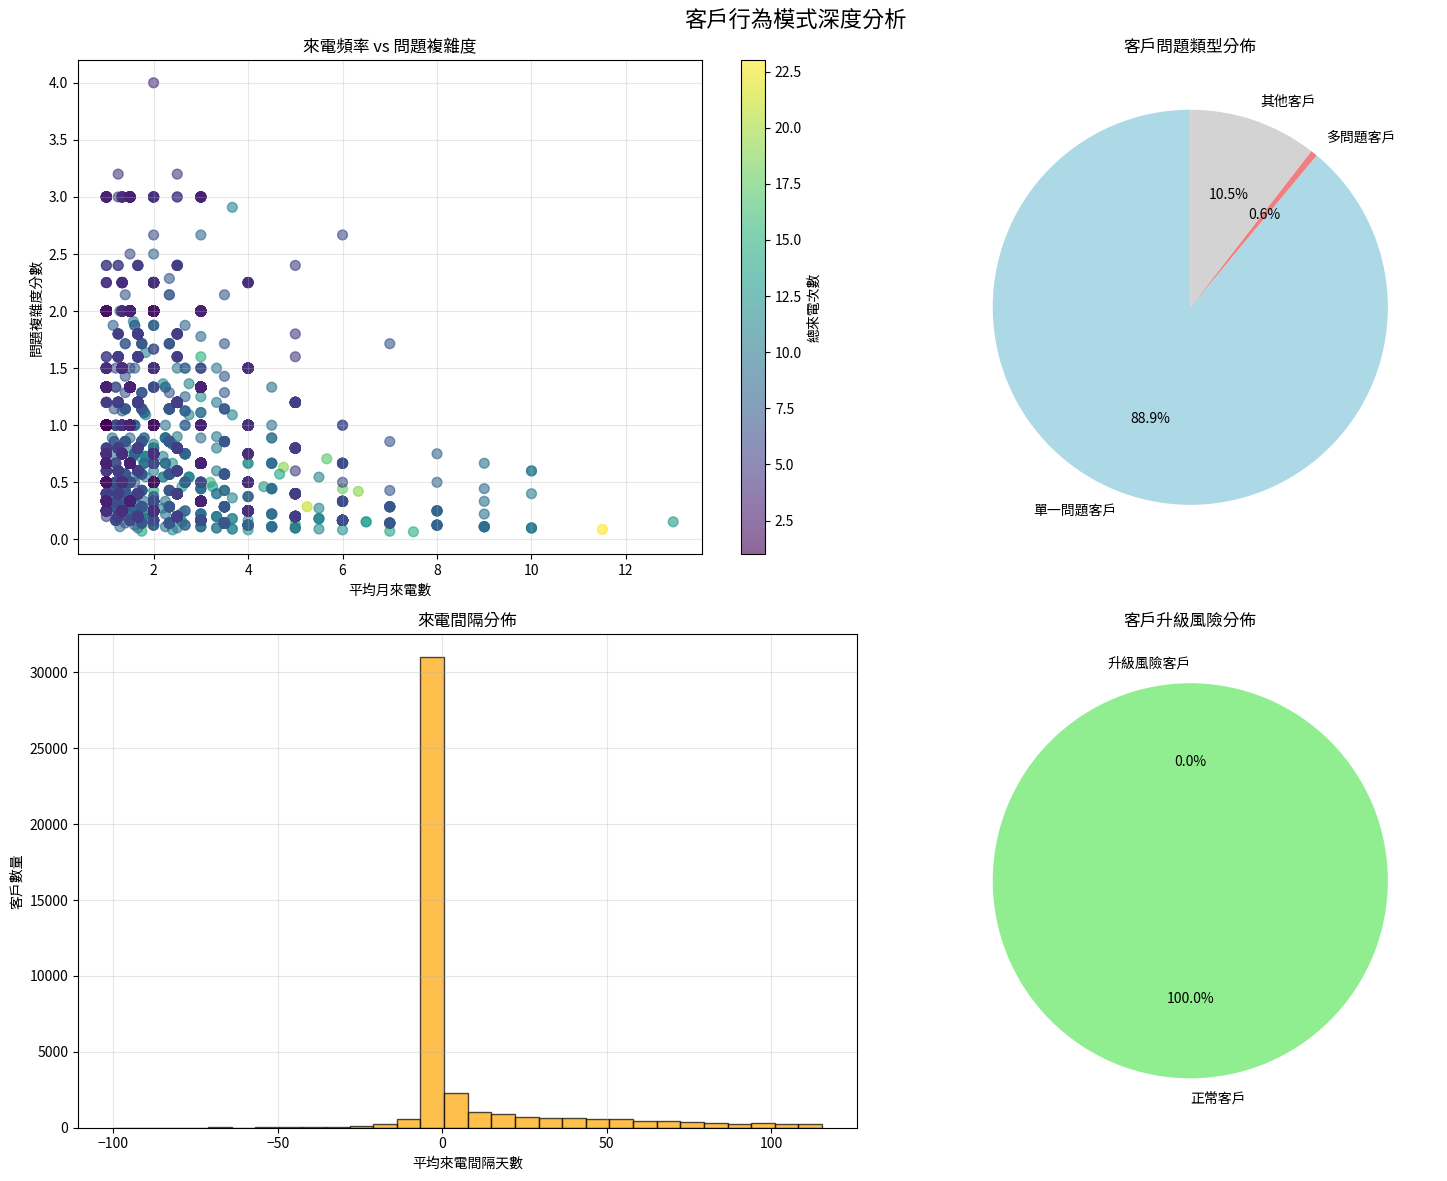

In [23]:
# 2. 客戶行為模式分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('客戶行為模式深度分析', fontsize=16, fontweight='bold')

# 2.1 來電頻率vs問題複雜度散點圖 - with error handling
if 'AVG_MONTHLY_CALLS' in df_final_features.columns and 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
    ax1 = axes[0, 0]
    
    # Check if TOTAL_CALLS exists, otherwise use an alternative
    if 'TOTAL_CALLS' in df_final_features.columns:
        color_col = df_final_features['TOTAL_CALLS']
        color_label = '總來電次數'
    elif 'TOTAL_CALLS_x' in df_final_features.columns:
        color_col = df_final_features['TOTAL_CALLS_x']
        color_label = '總來電次數'
    else:
        # Use index as fallback
        color_col = range(len(df_final_features))
        color_label = '客戶編號'
    
    scatter = ax1.scatter(df_final_features['AVG_MONTHLY_CALLS'], 
                         df_final_features['PROBLEM_COMPLEXITY_SCORE'],
                         alpha=0.6, s=50, c=color_col, 
                         cmap='viridis')
    ax1.set_xlabel('平均月來電數')
    ax1.set_ylabel('問題複雜度分數')
    ax1.set_title('來電頻率 vs 問題複雜度')
    plt.colorbar(scatter, ax=ax1, label=color_label)
    ax1.grid(True, alpha=0.3)
else:
    # Handle missing columns
    ax1 = axes[0, 0]
    ax1.text(0.5, 0.5, '缺少必要欄位\n無法繪製此圖表', 
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('來電頻率 vs 問題複雜度 (數據不足)')

# Continue with other plots...

# 2.2 客戶類型分佈（單一問題 vs 多問題客戶）
if 'IS_SINGLE_ISSUE_CUSTOMER' in df_final_features.columns and 'IS_MULTI_ISSUE_CUSTOMER' in df_final_features.columns:
    ax2 = axes[0, 1]
    single_issue = df_final_features['IS_SINGLE_ISSUE_CUSTOMER'].sum()
    multi_issue = df_final_features['IS_MULTI_ISSUE_CUSTOMER'].sum()
    other = len(df_final_features) - single_issue - multi_issue
    
    categories = ['單一問題客戶', '多問題客戶', '其他客戶']
    values = [single_issue, multi_issue, other]
    colors = ['lightblue', 'lightcoral', 'lightgray']
    
    ax2.pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('客戶問題類型分佈')

# 2.3 來電間隔趨勢分析
if 'AVG_CALL_INTERVAL_DAYS' in df_final_features.columns:
    ax3 = axes[1, 0]
    # 過濾掉極端值進行視覺化
    interval_data = df_final_features['AVG_CALL_INTERVAL_DAYS'].dropna()
    interval_data = interval_data[interval_data <= interval_data.quantile(0.95)]
    
    ax3.hist(interval_data, bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax3.set_xlabel('平均來電間隔天數')
    ax3.set_ylabel('客戶數量')
    ax3.set_title('來電間隔分佈')
    ax3.grid(True, alpha=0.3)

# 2.4 升級風險客戶分析
if 'ESCALATION_RISK' in df_final_features.columns:
    ax4 = axes[1, 1]
    risk_counts = df_final_features['ESCALATION_RISK'].value_counts()
    
    labels = ['正常客戶', '升級風險客戶']
    sizes = [risk_counts.get(0, 0), risk_counts.get(1, 0)]
    colors = ['lightgreen', 'red']
    
    ax4.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title('客戶升級風險分佈')

plt.tight_layout()
plt.show()

=== 特徵相關性分析 ===


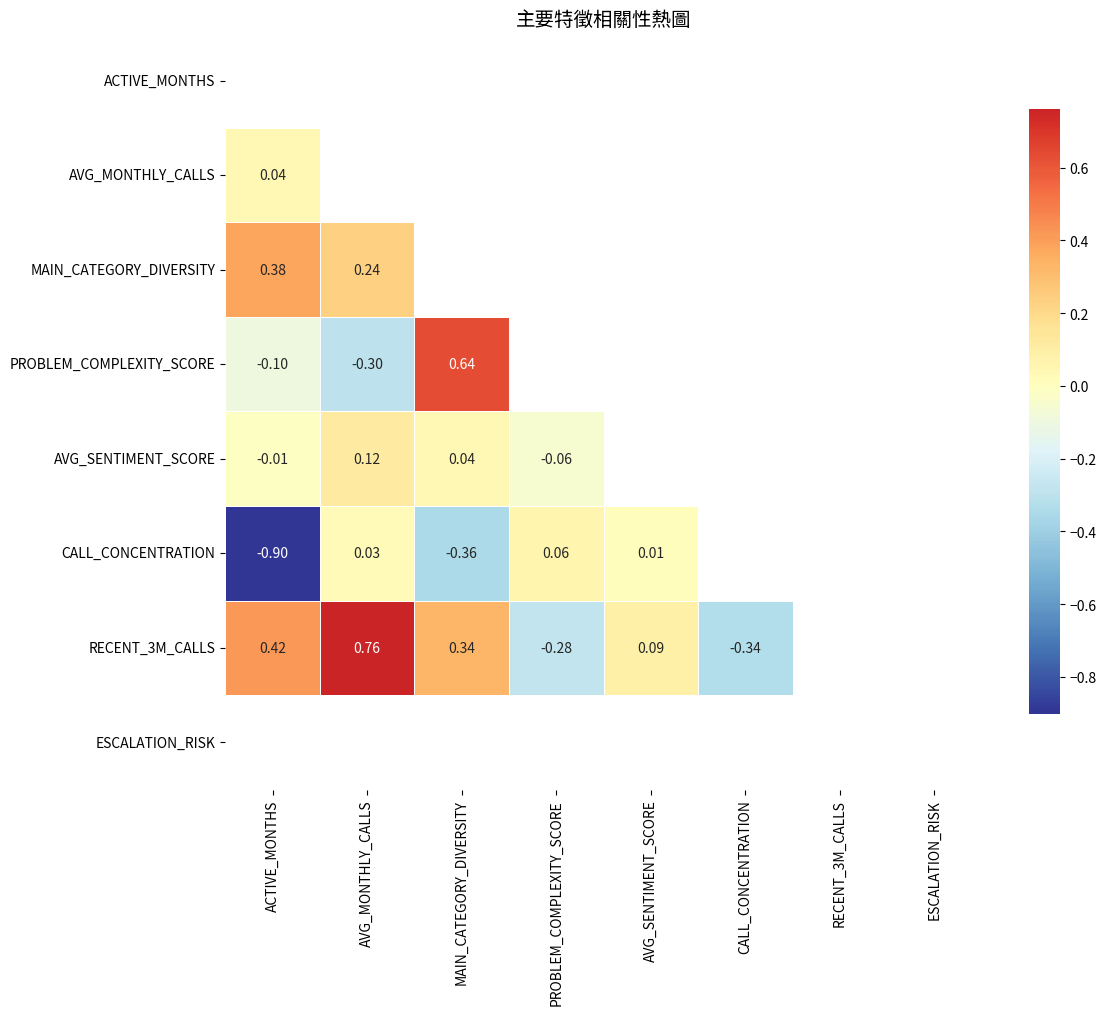


高度相關的特徵對 (|相關係數| > 0.5):
  ACTIVE_MONTHS <-> CALL_CONCENTRATION: -0.902
  AVG_MONTHLY_CALLS <-> RECENT_3M_CALLS: 0.762
  MAIN_CATEGORY_DIVERSITY <-> PROBLEM_COMPLEXITY_SCORE: 0.637


In [24]:
# 3. 特徵相關性分析
print("=== 特徵相關性分析 ===")

# 選擇主要數值特徵進行相關性分析
key_features = []
for feature in ['TOTAL_CALLS', 'ACTIVE_MONTHS', 'AVG_MONTHLY_CALLS', 'MAIN_CATEGORY_DIVERSITY', 
                'PROBLEM_COMPLEXITY_SCORE', 'AVG_SENTIMENT_SCORE', 'CALL_CONCENTRATION',
                'RECENT_3M_CALLS', 'ESCALATION_RISK']:
    if feature in df_final_features.columns:
        key_features.append(feature)

if len(key_features) > 1:
    # 計算相關性矩陣
    corr_matrix = df_final_features[key_features].corr()
    
    # 創建相關性熱圖
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f')
    plt.title('主要特徵相關性熱圖', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 找出高度相關的特徵對
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    print("\n高度相關的特徵對 (|相關係數| > 0.5):")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

=== 客戶細分分析 ===


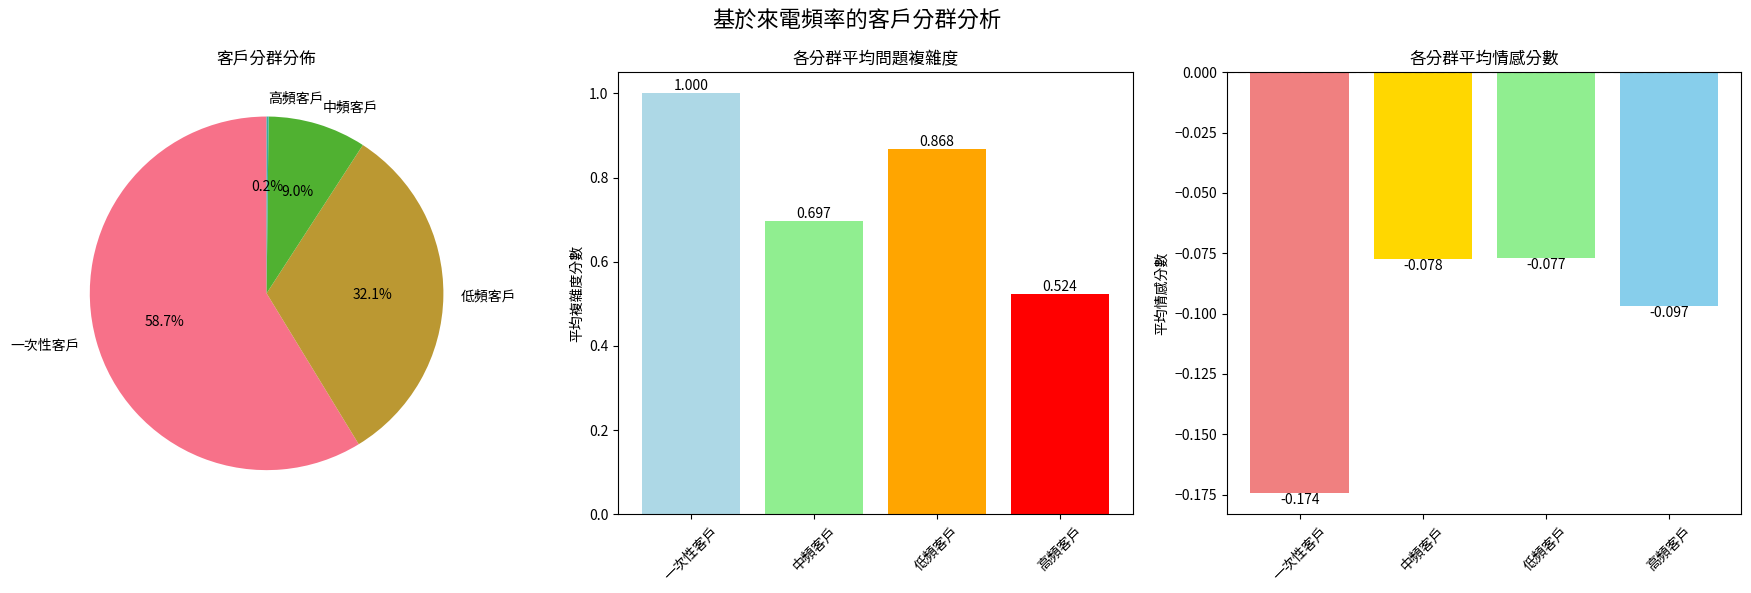

In [27]:
# 4. 客戶細分與特徵分析
print("=== 客戶細分分析 ===")

# 4.1 基於來電頻率的客戶分群
if 'TOTAL_CALLS' in df_final_features.columns:
    # 定義客戶分群
    def categorize_customer_by_calls(total_calls):
        if total_calls == 1:
            return '一次性客戶'
        elif total_calls <= 3:
            return '低頻客戶'
        elif total_calls <= 10:
            return '中頻客戶'
        else:
            return '高頻客戶'
    
    df_final_features['客戶分群'] = df_final_features['TOTAL_CALLS'].apply(categorize_customer_by_calls)
    
    # 視覺化客戶分群
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('基於來電頻率的客戶分群分析', fontsize=16, fontweight='bold')
    
    # 分群分佈
    ax1 = axes[0]
    customer_segments = df_final_features['客戶分群'].value_counts()
    ax1.pie(customer_segments.values, labels=customer_segments.index, autopct='%1.1f%%', startangle=90)
    ax1.set_title('客戶分群分佈')
    
    # 各分群的平均問題複雜度
    if 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
        ax2 = axes[1]
        complexity_by_segment = df_final_features.groupby('客戶分群')['PROBLEM_COMPLEXITY_SCORE'].mean()
        bars = ax2.bar(complexity_by_segment.index, complexity_by_segment.values, 
                      color=['lightblue', 'lightgreen', 'orange', 'red'])
        ax2.set_title('各分群平均問題複雜度')
        ax2.set_ylabel('平均複雜度分數')
        ax2.tick_params(axis='x', rotation=45)
        
        # 添加數值標籤
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom')
    
    # 各分群的平均情感分數
    if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
        ax3 = axes[2]
        sentiment_by_segment = df_final_features.groupby('客戶分群')['AVG_SENTIMENT_SCORE'].mean()
        bars = ax3.bar(sentiment_by_segment.index, sentiment_by_segment.values,
                      color=['lightcoral', 'gold', 'lightgreen', 'skyblue'])
        ax3.set_title('各分群平均情感分數')
        ax3.set_ylabel('平均情感分數')
        ax3.tick_params(axis='x', rotation=45)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # 添加數值標籤
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    plt.tight_layout()
    plt.show()

=== 進階特徵分析 ===


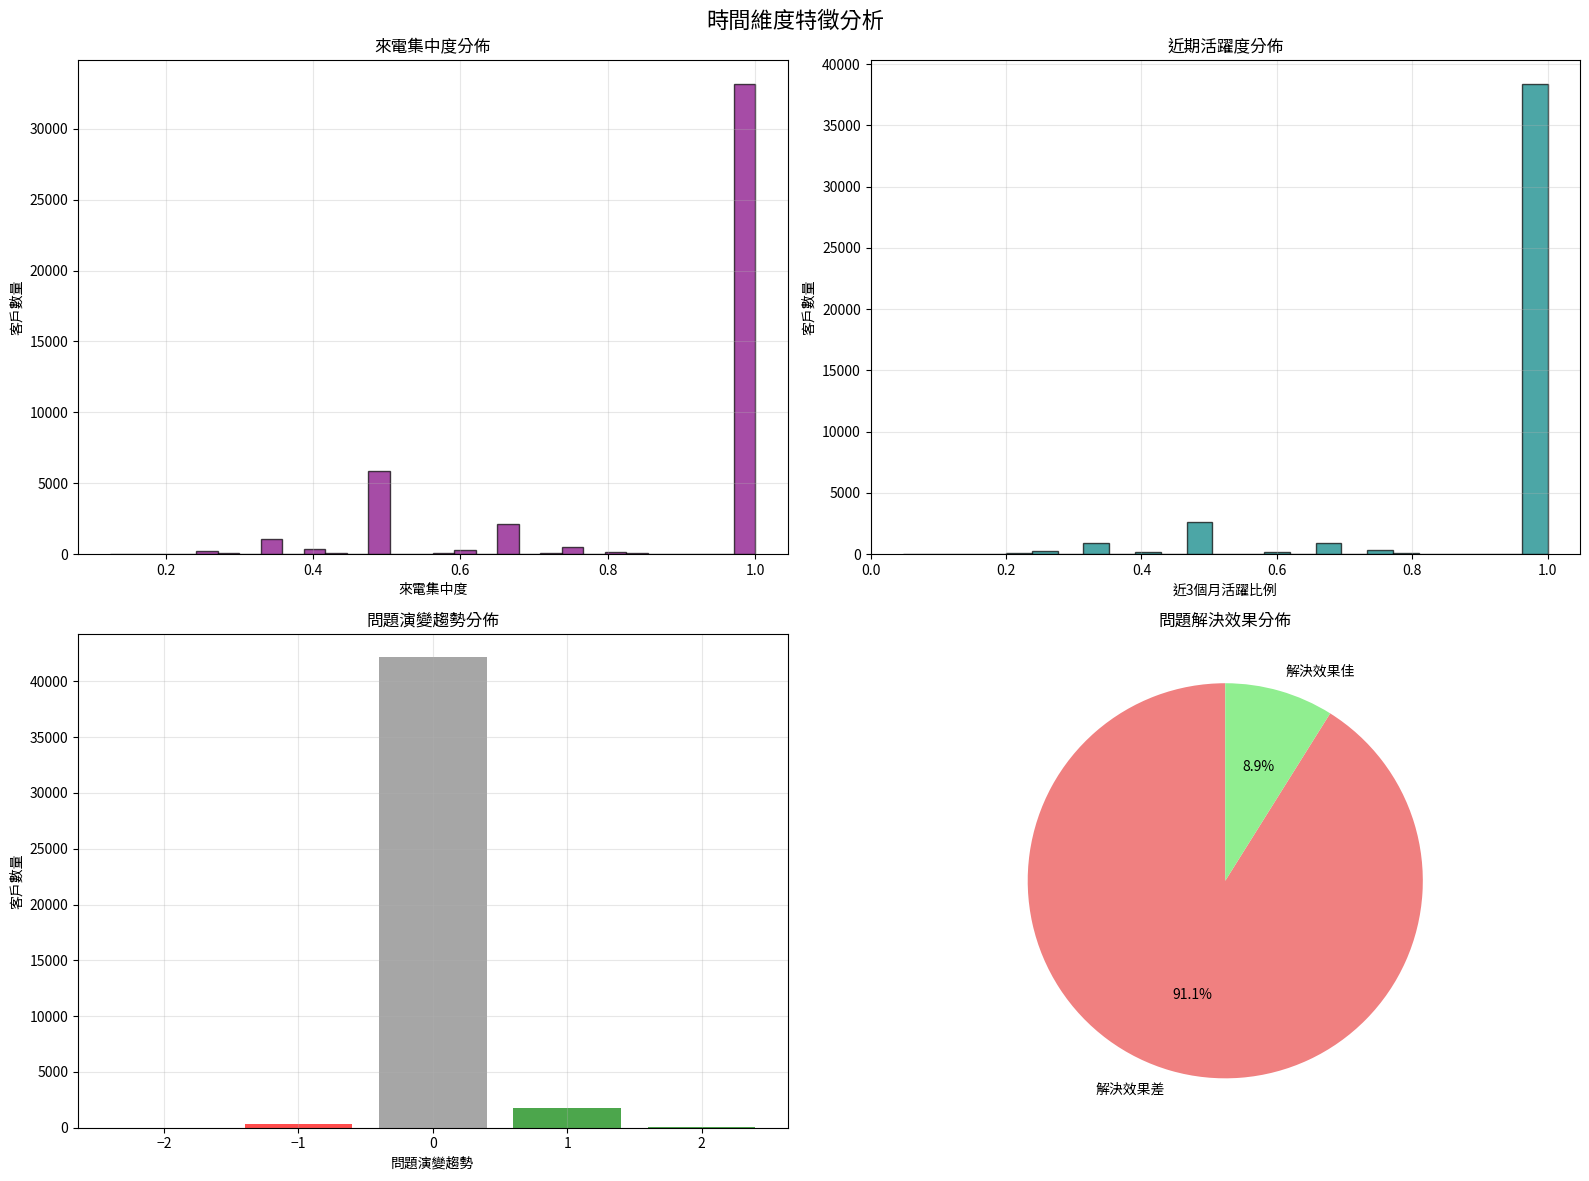

In [28]:
# 5. 進階特徵分析
print("=== 進階特徵分析 ===")

# 5.1 時間特徵分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('時間維度特徵分析', fontsize=16, fontweight='bold')

# 來電集中度分析
if 'CALL_CONCENTRATION' in df_final_features.columns:
    ax1 = axes[0, 0]
    concentration_data = df_final_features['CALL_CONCENTRATION'].dropna()
    ax1.hist(concentration_data, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax1.set_xlabel('來電集中度')
    ax1.set_ylabel('客戶數量')
    ax1.set_title('來電集中度分佈')
    ax1.grid(True, alpha=0.3)

# 近期活躍度分析
if 'RECENT_3M_CALLS' in df_final_features.columns and 'TOTAL_CALLS' in df_final_features.columns:
    ax2 = axes[0, 1]
    df_final_features['近期活躍比例'] = df_final_features['RECENT_3M_CALLS'] / df_final_features['TOTAL_CALLS']
    recent_activity = df_final_features['近期活躍比例'].dropna()
    ax2.hist(recent_activity, bins=25, alpha=0.7, color='teal', edgecolor='black')
    ax2.set_xlabel('近3個月活躍比例')
    ax2.set_ylabel('客戶數量')
    ax2.set_title('近期活躍度分佈')
    ax2.grid(True, alpha=0.3)

# 問題演變趨勢分析
if 'PROBLEM_EVOLUTION_TREND' in df_final_features.columns:
    ax3 = axes[1, 0]
    evolution_counts = df_final_features['PROBLEM_EVOLUTION_TREND'].value_counts().sort_index()
    colors = ['red' if x < 0 else 'green' if x > 0 else 'gray' for x in evolution_counts.index]
    bars = ax3.bar(evolution_counts.index, evolution_counts.values, color=colors, alpha=0.7)
    ax3.set_xlabel('問題演變趨勢')
    ax3.set_ylabel('客戶數量')
    ax3.set_title('問題演變趨勢分佈')
    ax3.grid(True, alpha=0.3)

# 解決效果分析
if 'RESOLUTION_EFFECTIVENESS' in df_final_features.columns:
    ax4 = axes[1, 1]
    effectiveness_counts = df_final_features['RESOLUTION_EFFECTIVENESS'].value_counts()
    labels = ['解決效果差', '解決效果佳']
    sizes = [effectiveness_counts.get(0, 0), effectiveness_counts.get(1, 0)]
    colors = ['lightcoral', 'lightgreen']
    
    ax4.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title('問題解決效果分佈')

plt.tight_layout()
plt.show()

=== 關鍵客戶識別與風險評估 ===


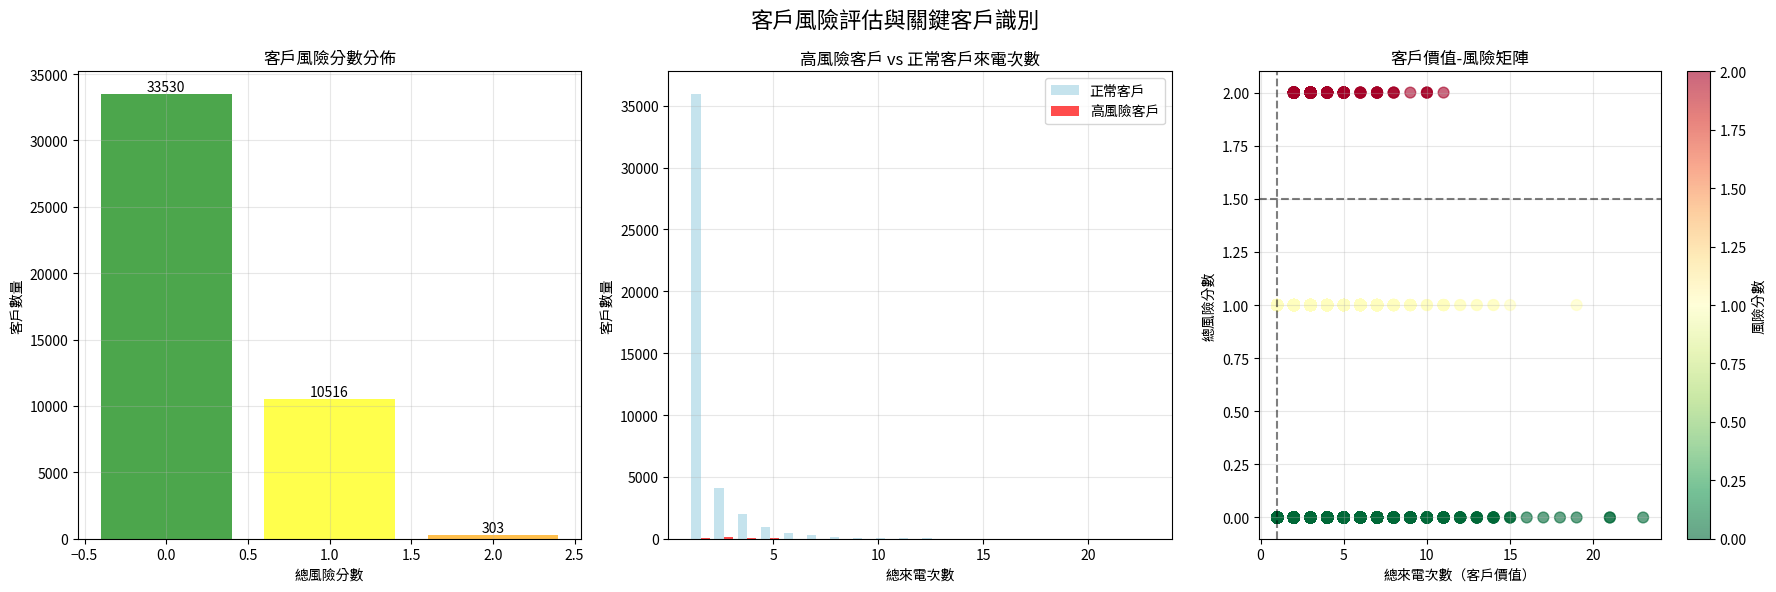


=== 風險評估統計 ===
總客戶數: 44349
高風險客戶數 (風險分數≥2): 303
高風險客戶比例: 0.7%
高價值高風險客戶數: 224
高價值高風險客戶比例: 0.5%


In [29]:
# 6. 關鍵客戶識別與風險評估
print("=== 關鍵客戶識別與風險評估 ===")

# 6.1 建立客戶風險評分
risk_factors = []
if 'ESCALATION_RISK' in df_final_features.columns:
    risk_factors.append('ESCALATION_RISK')
if 'AVG_SENTIMENT_SCORE' in df_final_features.columns:
    # 將情感分數轉換為風險因子（負分越低風險越高）
    df_final_features['情感風險'] = (df_final_features['AVG_SENTIMENT_SCORE'] < -0.5).astype(int)
    risk_factors.append('情感風險')
if 'PROBLEM_COMPLEXITY_SCORE' in df_final_features.columns:
    # 複雜度高的客戶風險較高
    complexity_threshold = df_final_features['PROBLEM_COMPLEXITY_SCORE'].quantile(0.8)
    df_final_features['複雜度風險'] = (df_final_features['PROBLEM_COMPLEXITY_SCORE'] > complexity_threshold).astype(int)
    risk_factors.append('複雜度風險')

if risk_factors:
    # 計算總風險分數
    df_final_features['總風險分數'] = df_final_features[risk_factors].sum(axis=1)
    
    # 視覺化風險分佈
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('客戶風險評估與關鍵客戶識別', fontsize=16, fontweight='bold')
    
    # 風險分數分佈
    ax1 = axes[0]
    risk_dist = df_final_features['總風險分數'].value_counts().sort_index()
    colors = ['green', 'yellow', 'orange', 'red'][:len(risk_dist)]
    bars = ax1.bar(risk_dist.index, risk_dist.values, color=colors, alpha=0.7)
    ax1.set_xlabel('總風險分數')
    ax1.set_ylabel('客戶數量')
    ax1.set_title('客戶風險分數分佈')
    ax1.grid(True, alpha=0.3)
    
    # 添加數值標籤
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # 高風險客戶特徵分析
    if 'TOTAL_CALLS' in df_final_features.columns:
        ax2 = axes[1]
        high_risk_customers = df_final_features[df_final_features['總風險分數'] >= 2]
        normal_customers = df_final_features[df_final_features['總風險分數'] < 2]
        
        ax2.hist([normal_customers['TOTAL_CALLS'], high_risk_customers['TOTAL_CALLS']], 
                bins=20, alpha=0.7, label=['正常客戶', '高風險客戶'], 
                color=['lightblue', 'red'])
        ax2.set_xlabel('總來電次數')
        ax2.set_ylabel('客戶數量')
        ax2.set_title('高風險客戶 vs 正常客戶來電次數')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 關鍵客戶矩陣（價值 vs 風險）
    if 'TOTAL_CALLS' in df_final_features.columns:
        ax3 = axes[2]
        scatter = ax3.scatter(df_final_features['TOTAL_CALLS'], 
                             df_final_features['總風險分數'],
                             alpha=0.6, s=60, 
                             c=df_final_features['總風險分數'], 
                             cmap='RdYlGn_r')
        ax3.set_xlabel('總來電次數（客戶價值）')
        ax3.set_ylabel('總風險分數')
        ax3.set_title('客戶價值-風險矩陣')
        ax3.grid(True, alpha=0.3)
        
        # 添加象限線
        ax3.axhline(y=1.5, color='black', linestyle='--', alpha=0.5)
        ax3.axvline(x=df_final_features['TOTAL_CALLS'].median(), color='black', linestyle='--', alpha=0.5)
        
        plt.colorbar(scatter, ax=ax3, label='風險分數')
    
    plt.tight_layout()
    plt.show()
    
    # 輸出關鍵統計
    print(f"\n=== 風險評估統計 ===")
    print(f"總客戶數: {len(df_final_features)}")
    print(f"高風險客戶數 (風險分數≥2): {len(df_final_features[df_final_features['總風險分數'] >= 2])}")
    print(f"高風險客戶比例: {len(df_final_features[df_final_features['總風險分數'] >= 2]) / len(df_final_features) * 100:.1f}%")
    
    if 'TOTAL_CALLS' in df_final_features.columns:
        high_value_high_risk = df_final_features[
            (df_final_features['總風險分數'] >= 2) & 
            (df_final_features['TOTAL_CALLS'] > df_final_features['TOTAL_CALLS'].quantile(0.7))
        ]
        print(f"高價值高風險客戶數: {len(high_value_high_risk)}")
        print(f"高價值高風險客戶比例: {len(high_value_high_risk) / len(df_final_features) * 100:.1f}%")

=== 特徵重要性與業務洞察 ===
主要特徵統計摘要:


,CUST_NO,TOTAL_CALLS,ACTIVE_MONTHS,ACTIVE_QUARTERS,AVG_MONTHLY_CALLS,MAX_MONTHLY_CALLS,STD_MONTHLY_CALLS,AVG_CALL_INTERVAL_DAYS,STD_CALL_INTERVAL_DAYS,MIN_CALL_INTERVAL_DAYS,...,RESOLUTION_EFFECTIVENESS,AVG_SENTIMENT_SCORE,TOTAL_SENTIMENT_SCORE,STD_SENTIMENT_SCORE,MIN_SENTIMENT_SCORE,MAX_SENTIMENT_SCORE,近期活躍比例,情感風險,複雜度風險,總風險分數
count,4.434900e+04,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,...,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000
mean,9.516808e+05,1.799296,1.345645,1.221786,1.323971,1.415545,0.107016,17.196134,9.007448,10.289138,...,0.089089,-0.134227,-0.195946,0.175913,-0.288507,0.020406,0.932556,0.162146,0.088638,0.250784
std,3.256339e+05,1.363994,0.700259,0.497094,0.691944,0.857073,0.382439,46.263264,27.971208,43.946397,...,0.284875,0.504560,0.892317,0.358686,0.617197,0.625453,0.180308,0.368589,0.284224,0.448954
min,4.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-100.000000,0.000000,-216.000000,...,0.000000,-8.000000,-22.000000,0.000000,-10.000000,-8.000000,0.047619,0.000000,0.000000,0.000000
25%,7.697540e+05,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.250000,-1.000000,0.000000,-1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.081676e+06,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.214186e+06,2.000000,2.000000,1.000000,1.500000,2.000000,0.000000,3.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,1.265426e+06,23.000000,11.000000,4.000000,13.000000,19.000000,10.606602,360.000000,268.700577,360.000000,...,1.000000,8.000000,12.000000,7.071068,8.000000,10.000000,1.000000,1.000000,1.000000,2.000000


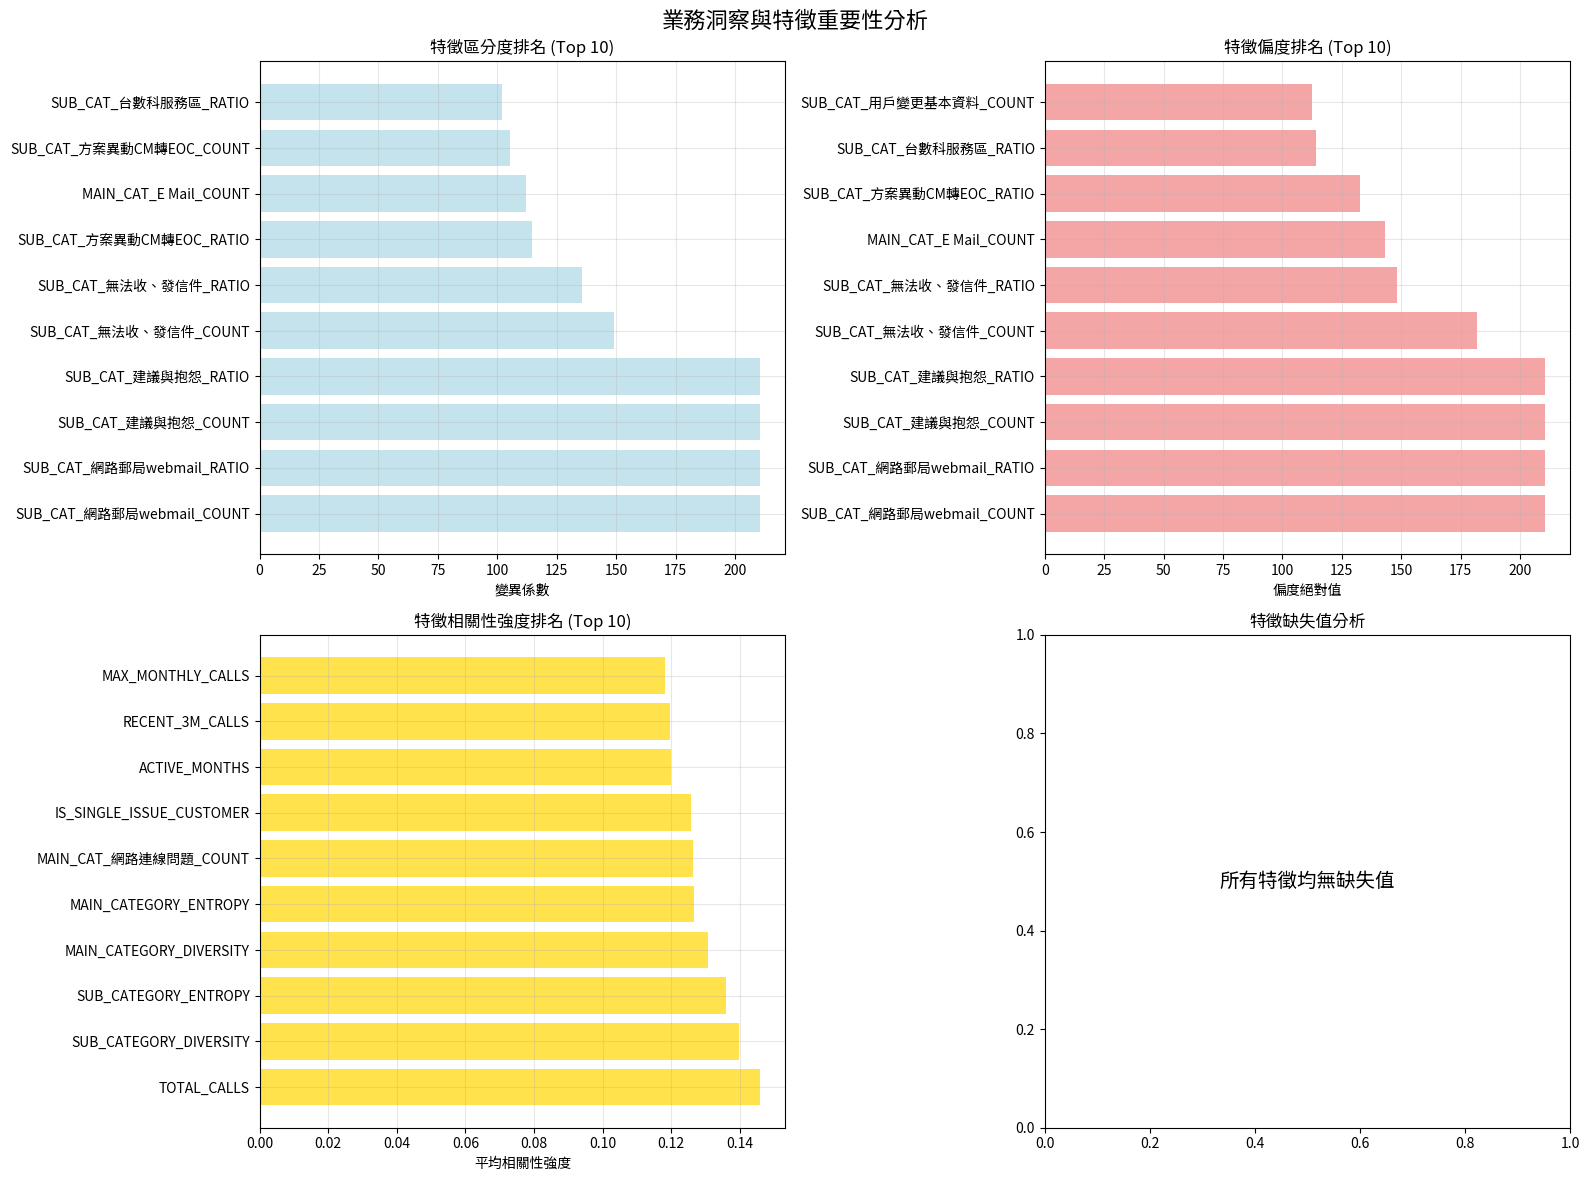

In [30]:
# 7. 特徵重要性與業務洞察
print("=== 特徵重要性與業務洞察 ===")

# 7.1 特徵統計摘要
numerical_cols = df_final_features.select_dtypes(include=[np.number]).columns
feature_summary = df_final_features[numerical_cols].describe()

print("主要特徵統計摘要:")
display(feature_summary)

# 7.2 業務洞察可視化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('業務洞察與特徵重要性分析', fontsize=16, fontweight='bold')

# 特徵變異係數分析（衡量特徵的區分度）
ax1 = axes[0, 0]
cv_scores = {}
for col in numerical_cols:
    if col in df_final_features.columns:
        mean_val = df_final_features[col].mean()
        std_val = df_final_features[col].std()
        if mean_val != 0:
            cv_scores[col] = std_val / abs(mean_val)

if cv_scores:
    sorted_cv = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)[:10]
    features, cv_values = zip(*sorted_cv)
    
    bars = ax1.barh(features, cv_values, color='lightblue', alpha=0.7)
    ax1.set_xlabel('變異係數')
    ax1.set_title('特徵區分度排名 (Top 10)')
    ax1.grid(True, alpha=0.3)

# 特徵分佈偏度分析
ax2 = axes[0, 1]
skewness_scores = {}
for col in numerical_cols:
    if col in df_final_features.columns:
        skew_val = df_final_features[col].skew()
        if not np.isnan(skew_val):
            skewness_scores[col] = abs(skew_val)

if skewness_scores:
    sorted_skew = sorted(skewness_scores.items(), key=lambda x: x[1], reverse=True)[:10]
    features, skew_values = zip(*sorted_skew)
    
    bars = ax2.barh(features, skew_values, color='lightcoral', alpha=0.7)
    ax2.set_xlabel('偏度絕對值')
    ax2.set_title('特徵偏度排名 (Top 10)')
    ax2.grid(True, alpha=0.3)

# 特徵相關性強度分析
ax3 = axes[1, 0]
if len(numerical_cols) > 1:
    corr_matrix = df_final_features[numerical_cols].corr()
    # 計算每個特徵與其他特徵的平均相關性
    avg_corr = {}
    for col in numerical_cols:
        if col in corr_matrix.columns:
            other_corr = corr_matrix[col].drop(col)
            avg_corr[col] = abs(other_corr).mean()
    
    if avg_corr:
        sorted_corr = sorted(avg_corr.items(), key=lambda x: x[1], reverse=True)[:10]
        features, corr_values = zip(*sorted_corr)
        
        bars = ax3.barh(features, corr_values, color='gold', alpha=0.7)
        ax3.set_xlabel('平均相關性強度')
        ax3.set_title('特徵相關性強度排名 (Top 10)')
        ax3.grid(True, alpha=0.3)

# 缺失值分析
ax4 = axes[1, 1]
missing_rates = df_final_features.isnull().sum() / len(df_final_features) * 100
missing_features = missing_rates[missing_rates > 0].sort_values(ascending=False)

if len(missing_features) > 0:
    bars = ax4.barh(missing_features.index, missing_features.values, color='red', alpha=0.7)
    ax4.set_xlabel('缺失值比例 (%)')
    ax4.set_title('特徵缺失值比例')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, '所有特徵均無缺失值', ha='center', va='center', 
             transform=ax4.transAxes, fontsize=14)
    ax4.set_title('特徵缺失值分析')

plt.tight_layout()
plt.show()

In [31]:
# 8. 保存分析結果
print("=== 保存分析結果 ===")

# 創建分析報告
analysis_report = {
    '資料概覽': {
        '總客戶數': len(df_final_features),
        '特徵數量': len(df_final_features.columns),
        '數值特徵數量': len(numerical_cols),
        '缺失值特徵數量': len(missing_features) if 'missing_features' in locals() else 0
    }
}

# 添加客戶分群統計
if '客戶分群' in df_final_features.columns:
    analysis_report['客戶分群統計'] = df_final_features['客戶分群'].value_counts().to_dict()

# 添加風險評估統計
if '總風險分數' in df_final_features.columns:
    analysis_report['風險評估統計'] = {
        '高風險客戶數': len(df_final_features[df_final_features['總風險分數'] >= 2]),
        '高風險客戶比例': f"{len(df_final_features[df_final_features['總風險分數'] >= 2]) / len(df_final_features) * 100:.1f}%"
    }

print("分析報告:", analysis_report)

# 保存增強特徵數據
enhanced_output_path = os.path.join(output_final_dir, 'enhanced_customer_features_with_analysis.csv')
df_final_features.to_csv(enhanced_output_path, index=False, encoding='utf-8-sig')
print(f"增強特徵數據已保存至: {enhanced_output_path}")

print("\n=== 視覺化分析完成 ===")
print("已完成以下分析:")
print("1. 整體特徵分佈概覽")
print("2. 客戶行為模式分析") 
print("3. 特徵相關性分析")
print("4. 客戶細分與特徵分析")
print("5. 進階特徵分析")
print("6. 關鍵客戶識別與風險評估")
print("7. 特徵重要性與業務洞察")
print("8. 分析結果保存")

=== 保存分析結果 ===
分析報告: {'資料概覽': {'總客戶數': 44349, '特徵數量': 144, '數值特徵數量': 143, '缺失值特徵數量': 0}, '客戶分群統計': {'一次性客戶': 26044, '低頻客戶': 14241, '中頻客戶': 3983, '高頻客戶': 81}, '風險評估統計': {'高風險客戶數': 303, '高風險客戶比例': '0.7%'}}
增強特徵數據已保存至: csr_analysis\final_output\enhanced_customer_features_with_analysis.csv

=== 視覺化分析完成 ===
已完成以下分析:
1. 整體特徵分佈概覽
2. 客戶行為模式分析
3. 特徵相關性分析
4. 客戶細分與特徵分析
5. 進階特徵分析
6. 關鍵客戶識別與風險評估
7. 特徵重要性與業務洞察
8. 分析結果保存


In [11]:
df_final_features = pd.read_csv(r'csr_analysis\final_output\enhanced_customer_features_with_analysis.csv', sep=',')
csr_LLM_sentiment_unique = pd.read_csv('csr_LLM_sentiment_unique.csv', sep=',')
# 或者使用正斜線
# df_final_features = pd.read_csv('csr_analysis/final_output/enhanced_customer_features_with_analysis.csv', sep=',')

=== 合併 csr_LLM_sentiment_unique 的 AVG_score 到 df_final_features ===
df_final_features 資料筆數: 44,349
df_final_features 唯一客戶數: 44,349
csr_LLM_sentiment_unique 資料筆數: 44,349
csr_LLM_sentiment_unique 唯一客戶數: 44,349
發現的 score 欄位: ['AVG_score']
使用的 AVG_score 欄位: AVG_score

df CUST_NO 資料型態: int64
csr_LLM_sentiment_unique CUST_NO 資料型態: int64

開始合併 AVG_score 欄位...

=== 合併結果檢查 ===
合併前 df_final_features 筆數: 44,349
合併後 df_merged 筆數: 44,349
是否有資料遺失: 否
AVG_score 非空值數量: 44,349
AVG_score 空值數量: 0
AVG_score 覆蓋率: 100.0%

AVG_score 統計:


count    44349.000000
mean        -0.403616
std          0.386345
min         -1.000000
25%         -0.700000
50%         -0.600000
75%         -0.200000
max          1.000000
Name: AVG_score, dtype: float64


=== 合併後資料預覽 ===


,CUST_NO,TOTAL_CALLS,ACTIVE_MONTHS,ACTIVE_QUARTERS,AVG_MONTHLY_CALLS,AVG_score
0,856873,23,2,2,11.500000,-0.186957
1,953834,21,11,4,1.909091,-0.638095
2,288844,21,4,3,5.250000,-0.380952
3,1254673,19,3,2,6.333333,-0.436842
4,1224281,19,4,3,4.750000,-0.536842
5,1242727,18,3,2,6.000000,-0.194444
6,781090,17,3,2,5.666667,-0.382353
7,1243790,16,5,3,3.200000,-0.287500
8,1232845,15,3,2,5.000000,-0.026667
9,1172052,15,5,3,3.000000,-0.253333



=== 客戶匹配情況 ===
成功匹配的客戶數: 44,349
未匹配的客戶數: 0

✅ 成功合併！df_final_features 已更新，新增 AVG_score 欄位
最終 df_final_features 形狀: (44349, 145)

=== AVG_score 分佈視覺化 ===


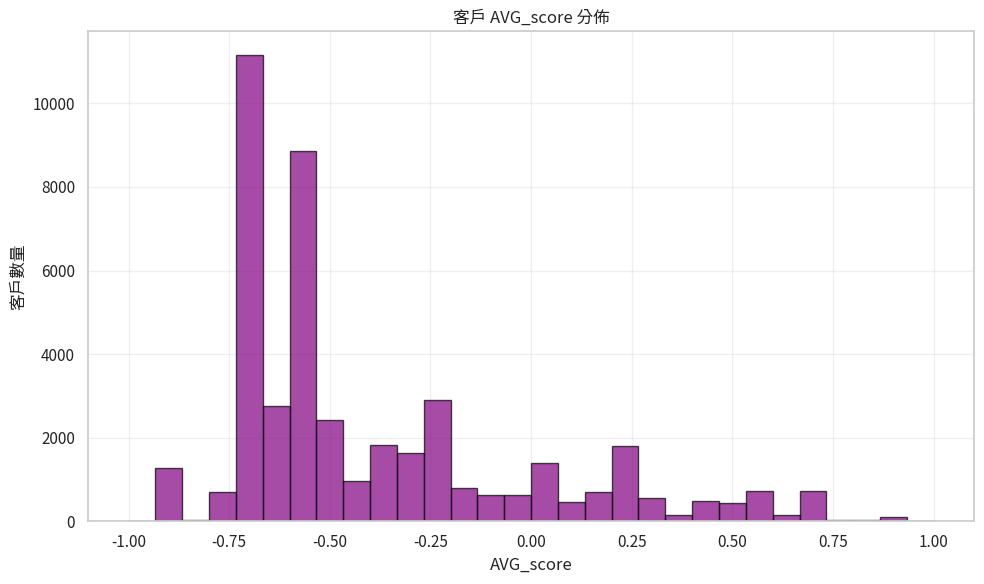

In [12]:
# 將 csr_LLM_sentiment_unique 的 AVG_score 欄位合併到 df_final_features

print("=== 合併 csr_LLM_sentiment_unique 的 AVG_score 到 df_final_features ===")

# 1. 檢查數據是否存在
if 'df_final_features' in locals() and df_final_features is not None and not df_final_features.empty:
    print(f"df_final_features 資料筆數: {len(df_final_features):,}")
    print(f"df_final_features 唯一客戶數: {df_final_features['CUST_NO'].nunique():,}")
else:
    print("❌ df_final_features 未定義或為空")

if 'csr_LLM_sentiment_unique' in locals() and csr_LLM_sentiment_unique is not None and not csr_LLM_sentiment_unique.empty:
    print(f"csr_LLM_sentiment_unique 資料筆數: {len(csr_LLM_sentiment_unique):,}")
    print(f"csr_LLM_sentiment_unique 唯一客戶數: {csr_LLM_sentiment_unique['CUST_NO'].nunique():,}")
    
    # 檢查 AVG_score 欄位是否存在
    score_columns = [col for col in csr_LLM_sentiment_unique.columns if 'score' in col.lower()]
    print(f"發現的 score 欄位: {score_columns}")
    
    if score_columns:
        # 使用第一個找到的 score 欄位，或手動指定
        avg_score_col = score_columns[0] if 'AVG_score' in score_columns else score_columns[0]
        print(f"使用的 AVG_score 欄位: {avg_score_col}")
        
        # 2. 檢查合併前的 CUST_NO 資料型態一致性
        print(f"\ndf CUST_NO 資料型態: {df['CUST_NO'].dtype}")
        print(f"csr_LLM_sentiment_unique CUST_NO 資料型態: {csr_LLM_sentiment_unique['CUST_NO'].dtype}")
        
        # 確保 CUST_NO 資料型態一致
        if df_final_features['CUST_NO'].dtype != csr_LLM_sentiment_unique['CUST_NO'].dtype:
            print("正在轉換 CUST_NO 資料型態...")
            csr_LLM_sentiment_unique['CUST_NO'] = csr_LLM_sentiment_unique['CUST_NO'].astype(df_final_features['CUST_NO'].dtype)

        # 3. 執行合併
        print(f"\n開始合併 {avg_score_col} 欄位...")
        
        # 只選擇需要的欄位進行合併
        sentiment_to_merge = csr_LLM_sentiment_unique[['CUST_NO', avg_score_col]].copy()
        
        # 重新命名欄位為標準名稱（如果需要）
        if avg_score_col != 'AVG_score':
            sentiment_to_merge = sentiment_to_merge.rename(columns={avg_score_col: 'AVG_score'})
        
        # 備份原始 df
        df_original = df_final_features.copy()
        
        # 執行左連接合併
        df_merged = pd.merge(df_original, sentiment_to_merge, on='CUST_NO', how='left')

        # 4. 檢查合併結果
        print(f"\n=== 合併結果檢查 ===")
        print(f"合併前 df_final_features 筆數: {len(df_final_features):,}")
        print(f"合併後 df_merged 筆數: {len(df_merged):,}")
        print(f"是否有資料遺失: {'否' if len(df_merged) == len(df_final_features) else '是'}")

        # 檢查 AVG_score 欄位
        if 'AVG_score' in df_merged.columns:
            print(f"AVG_score 非空值數量: {df_merged['AVG_score'].notna().sum():,}")
            print(f"AVG_score 空值數量: {df_merged['AVG_score'].isna().sum():,}")
            print(f"AVG_score 覆蓋率: {df_merged['AVG_score'].notna().sum() / len(df_merged) * 100:.1f}%")
            
            # 顯示 AVG_score 統計
            print(f"\nAVG_score 統計:")
            display(df_merged['AVG_score'].describe())
            
            # 5. 顯示合併後的資料預覽
            print(f"\n=== 合併後資料預覽 ===")
            # 顯示包含 AVG_score 的欄位
            preview_cols = ['CUST_NO'] + [col for col in df_merged.columns if col != 'CUST_NO'][:4] + ['AVG_score']
            preview_cols = [col for col in preview_cols if col in df_merged.columns]
            display(df_merged[preview_cols].head(10))
            
            # 6. 檢查合併的客戶匹配情況
            matched_customers = df_merged['AVG_score'].notna().sum()
            unmatched_customers = df_merged['AVG_score'].isna().sum()
            
            print(f"\n=== 客戶匹配情況 ===")
            print(f"成功匹配的客戶數: {matched_customers:,}")
            print(f"未匹配的客戶數: {unmatched_customers:,}")
            
            if unmatched_customers > 0:
                print(f"未匹配客戶比例: {unmatched_customers / len(df_merged) * 100:.1f}%")
                print("建議：可以考慮將未匹配客戶的 AVG_score 填充為預設值（如 0）")
                
                # 提供填充選項
                fill_missing = True  # 可以改為 False 如果不想自動填充
                if fill_missing:
                    df_merged['AVG_score'] = df_merged['AVG_score'].fillna(0.0)
                    print("已將未匹配客戶的 AVG_score 填充為 0.0")
            
            # 7. 更新 df
            df_final_features = df_merged.copy()
            print(f"\n✅ 成功合併！df_final_features 已更新，新增 AVG_score 欄位")
            print(f"最終 df_final_features 形狀: {df_final_features.shape}")

            # 8. 顯示 AVG_score 分佈
            print(f"\n=== AVG_score 分佈視覺化 ===")
            plt.figure(figsize=(10, 6))
            df_final_features['AVG_score'].hist(bins=30, alpha=0.7, color='purple', edgecolor='black')
            plt.title('客戶 AVG_score 分佈')
            plt.xlabel('AVG_score')
            plt.ylabel('客戶數量')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
        else:
            print("❌ 合併後未找到 AVG_score 欄位")
            
    else:
        print("❌ 在 csr_LLM_sentiment_unique 中未找到 score 相關欄位")
        print("可用欄位:", list(csr_LLM_sentiment_unique.columns))
        
else:
    print("❌ csr_LLM_sentiment_unique 未定義或為空")

print("\n" + "="*60)

In [13]:
output_path = 'enhanced_customer_features_with_LLM.csv'
df_final_features.to_csv(output_path, index=False, encoding='utf-8-sig')

In [4]:
# 針對各類型特徵各取前10項進行精簡
#import pandas as pd
#import numpy as np

def select_top_features_by_category(df_final_features, top_n=10):
    """
    針對各類型特徵選取前N項最重要的特徵
    """
    print("=== 開始特徵精簡分析 ===")
    print(f"原始特徵數量: {len(df_final_features.columns)}")
    
    # 1. 基礎特徵（必保留）
    essential_features = ['CUST_NO']
    
    # 2. 基本統計特徵
    basic_stats_features = [
        'TOTAL_CALLS', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 
        'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS',
        'RECENT_3M_CALLS', 'CALL_CONCENTRATION', 'ESCALATION_TREND'
    ]
    
    # 3. 時間間隔特徵
    time_interval_features = [
        'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 
        'MIN_CALL_INTERVAL_DAYS', 'INTERVAL_TREND'
    ]
    
    # 4. 問題多樣性特徵
    diversity_features = [
        'MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY',
        'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY',
        'PROBLEM_COMPLEXITY_SCORE', 'MAIN_PROBLEM_RATIO',
        'PROBLEM_EVOLUTION_TREND', 'IS_SINGLE_ISSUE_CUSTOMER',
        'IS_MULTI_ISSUE_CUSTOMER'
    ]
    
    # 5. 情感分析特徵
    sentiment_features = [
        'AVG_SENTIMENT_SCORE', 'TOTAL_SENTIMENT_SCORE',
        'STD_SENTIMENT_SCORE', 'MIN_SENTIMENT_SCORE', 'MAX_SENTIMENT_SCORE'
    ]
    
    # 6. 問題演變特徵
    evolution_features = [
        'PROBLEM_SEVERITY_TREND', 'RECURRING_ISSUES_COUNT',
        'RECENT_SEVERITY_AVG', 'ESCALATION_RISK', 'RESOLUTION_EFFECTIVENESS'
    ]
    
    # 7. 找出所有主分類相關特徵
    main_cat_features = [col for col in df_final_features.columns if col.startswith('MAIN_CAT_')]
    
    # 8. 找出所有次分類相關特徵  
    sub_cat_features = [col for col in df_final_features.columns if col.startswith('SUB_CAT_')]
    
    # 選取每類特徵的前N項
    selected_features = set(essential_features)
    
    # 檢查並添加可用特徵
    available_basic = [f for f in basic_stats_features if f in df_final_features.columns]
    available_time = [f for f in time_interval_features if f in df_final_features.columns]
    available_diversity = [f for f in diversity_features if f in df_final_features.columns]
    available_sentiment = [f for f in sentiment_features if f in df_final_features.columns]
    available_evolution = [f for f in evolution_features if f in df_final_features.columns]
    
    # 添加特徵（每類最多top_n個）
    selected_features.update(available_basic[:top_n])
    selected_features.update(available_time[:top_n])
    selected_features.update(available_diversity[:top_n])
    selected_features.update(available_sentiment[:top_n])
    selected_features.update(available_evolution[:top_n])
    
    # 9. 基於重要性選取主分類特徵
    if main_cat_features:
        # 計算每個主分類特徵的變異係數作為重要性指標
        main_cat_importance = {}
        for feature in main_cat_features:
            if feature in df_final_features.columns:
                mean_val = df_final_features[feature].mean()
                std_val = df_final_features[feature].std()
                if mean_val != 0:
                    main_cat_importance[feature] = std_val / abs(mean_val)
                else:
                    main_cat_importance[feature] = 0
        
        # 選取前N個重要的主分類特徵
        top_main_cat = sorted(main_cat_importance.items(), key=lambda x: x[1], reverse=True)[:top_n]
        selected_features.update([f[0] for f in top_main_cat])
    
    # 10. 基於重要性選取次分類特徵
    if sub_cat_features:
        # 計算每個次分類特徵的變異係數作為重要性指標
        sub_cat_importance = {}
        for feature in sub_cat_features:
            if feature in df_final_features.columns:
                mean_val = df_final_features[feature].mean()
                std_val = df_final_features[feature].std()
                if mean_val != 0:
                    sub_cat_importance[feature] = std_val / abs(mean_val)
                else:
                    sub_cat_importance[feature] = 0
        
        # 選取前N個重要的次分類特徵
        top_sub_cat = sorted(sub_cat_importance.items(), key=lambda x: x[1], reverse=True)[:top_n]
        selected_features.update([f[0] for f in top_sub_cat])
    
    # 11. 確保所有選中的特徵都存在於原始數據中
    final_features = [f for f in selected_features if f in df_final_features.columns]
    
    # 12. 創建精簡後的數據框
    df_simplified = df_final_features[final_features].copy()
    
    # 13. 輸出統計信息
    print(f"\n=== 特徵精簡結果 ===")
    print(f"原始特徵數量: {len(df_final_features.columns)}")
    print(f"精簡後特徵數量: {len(final_features)}")
    print(f"壓縮比例: {len(final_features)/len(df_final_features.columns)*100:.1f}%")
    
    print(f"\n=== 各類型特徵數量 ===")
    print(f"基礎特徵: {len([f for f in final_features if f in essential_features])}")
    print(f"基本統計特徵: {len([f for f in final_features if f in available_basic])}")
    print(f"時間間隔特徵: {len([f for f in final_features if f in available_time])}")
    print(f"問題多樣性特徵: {len([f for f in final_features if f in available_diversity])}")
    print(f"情感分析特徵: {len([f for f in final_features if f in available_sentiment])}")
    print(f"問題演變特徵: {len([f for f in final_features if f in available_evolution])}")
    print(f"主分類特徵: {len([f for f in final_features if f.startswith('MAIN_CAT_')])}")
    print(f"次分類特徵: {len([f for f in final_features if f.startswith('SUB_CAT_')])}")
    
    # 14. 按類型顯示選中的特徵
    print(f"\n=== 選中的特徵列表 ===")
    feature_categories = {
        '基礎特徵': [f for f in final_features if f in essential_features],
        '基本統計特徵': [f for f in final_features if f in available_basic],
        '時間間隔特徵': [f for f in final_features if f in available_time],
        '問題多樣性特徵': [f for f in final_features if f in available_diversity],
        '情感分析特徵': [f for f in final_features if f in available_sentiment],
        '問題演變特徵': [f for f in final_features if f in available_evolution],
        '主分類特徵': [f for f in final_features if f.startswith('MAIN_CAT_')],
        '次分類特徵': [f for f in final_features if f.startswith('SUB_CAT_')]
    }
    
    for category, features in feature_categories.items():
        if features:
            print(f"\n{category}:")
            for feature in features:
                print(f"  - {feature}")
    
    return df_simplified, final_features

# 執行特徵精簡
df_final_features_simplified, selected_feature_list = select_top_features_by_category(df_final_features, top_n=10)

=== 開始特徵精簡分析 ===
原始特徵數量: 144

=== 特徵精簡結果 ===
原始特徵數量: 144
精簡後特徵數量: 53
壓縮比例: 36.8%

=== 各類型特徵數量 ===
基礎特徵: 1
基本統計特徵: 9
時間間隔特徵: 4
問題多樣性特徵: 9
情感分析特徵: 5
問題演變特徵: 5
主分類特徵: 10
次分類特徵: 10

=== 選中的特徵列表 ===

基礎特徵:
  - CUST_NO

基本統計特徵:
  - TOTAL_CALLS
  - AVG_MONTHLY_CALLS
  - RECENT_3M_CALLS
  - ACTIVE_QUARTERS
  - CALL_CONCENTRATION
  - ACTIVE_MONTHS
  - MAX_MONTHLY_CALLS
  - ESCALATION_TREND
  - STD_MONTHLY_CALLS

時間間隔特徵:
  - AVG_CALL_INTERVAL_DAYS
  - STD_CALL_INTERVAL_DAYS
  - MIN_CALL_INTERVAL_DAYS
  - INTERVAL_TREND

問題多樣性特徵:
  - PROBLEM_COMPLEXITY_SCORE
  - SUB_CATEGORY_DIVERSITY
  - SUB_CATEGORY_ENTROPY
  - IS_MULTI_ISSUE_CUSTOMER
  - PROBLEM_EVOLUTION_TREND
  - MAIN_CATEGORY_ENTROPY
  - MAIN_PROBLEM_RATIO
  - MAIN_CATEGORY_DIVERSITY
  - IS_SINGLE_ISSUE_CUSTOMER

情感分析特徵:
  - MAX_SENTIMENT_SCORE
  - TOTAL_SENTIMENT_SCORE
  - AVG_SENTIMENT_SCORE
  - STD_SENTIMENT_SCORE
  - MIN_SENTIMENT_SCORE

問題演變特徵:
  - ESCALATION_RISK
  - RECENT_SEVERITY_AVG
  - PROBLEM_SEVERITY_TREND
  - RECURRING_ISSUES_

=== 精簡後的特徵數據預覽 ===


,MAX_SENTIMENT_SCORE,PROBLEM_COMPLEXITY_SCORE,SUB_CAT_方案異動CM轉EOC_COUNT,AVG_CALL_INTERVAL_DAYS,MAIN_CAT_非連線問題_COUNT,SUB_CATEGORY_DIVERSITY,MAIN_CAT_新產品_COUNT,SUB_CAT_建議與抱怨_RATIO,SUB_CAT_方案異動CM轉EOC_RATIO,TOTAL_CALLS,...,STD_SENTIMENT_SCORE,MIN_SENTIMENT_SCORE,SUB_CAT_無法收、發信件_RATIO,ESCALATION_TREND,MAIN_CAT_E Mail_COUNT,SUB_CAT_無法收、發信件_COUNT,MAIN_CAT_非連線問題_RATIO,SUB_CAT_網路郵局webmail_RATIO,MAIN_CAT_註冊問題_RATIO,STD_MONTHLY_CALLS
0,0,0.086957,0.0,1.545455,0.0,2,0.0,0.0,0.0,23,...,0.000000,0,0.0,1,0.0,0.0,0.000000,0.0,0.0,10.606602
1,1,0.142857,0.0,16.100000,0.0,3,0.0,0.0,0.0,21,...,0.700340,-2,0.0,0,0.0,0.0,0.000000,0.0,0.0,0.943880
2,3,0.285714,0.0,13.500000,8.0,3,0.0,0.0,0.0,21,...,1.220851,-2,0.0,0,0.0,0.0,0.380952,0.0,0.0,5.057997
3,2,0.421053,0.0,1.944444,0.0,4,0.0,0.0,0.0,19,...,1.701393,-5,0.0,0,0.0,0.0,0.000000,0.0,0.0,3.214550
4,1,0.631579,0.0,9.611111,7.0,4,0.0,0.0,0.0,19,...,0.577350,-1,0.0,1,0.0,0.0,0.368421,0.0,0.0,4.193249



=== 精簡後的數據統計 ===


,MAX_SENTIMENT_SCORE,PROBLEM_COMPLEXITY_SCORE,SUB_CAT_方案異動CM轉EOC_COUNT,AVG_CALL_INTERVAL_DAYS,MAIN_CAT_非連線問題_COUNT,SUB_CATEGORY_DIVERSITY,MAIN_CAT_新產品_COUNT,SUB_CAT_建議與抱怨_RATIO,SUB_CAT_方案異動CM轉EOC_RATIO,TOTAL_CALLS,...,STD_SENTIMENT_SCORE,MIN_SENTIMENT_SCORE,SUB_CAT_無法收、發信件_RATIO,ESCALATION_TREND,MAIN_CAT_E Mail_COUNT,SUB_CAT_無法收、發信件_COUNT,MAIN_CAT_非連線問題_RATIO,SUB_CAT_網路郵局webmail_RATIO,MAIN_CAT_註冊問題_RATIO,STD_MONTHLY_CALLS
count,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,...,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000,44349.000000
mean,0.020406,0.929538,0.000090,17.196134,0.030215,1.264087,0.003811,0.000011,0.000053,1.799296,...,0.175913,-0.288507,0.000022,0.041602,0.000203,0.000135,0.015545,0.000011,0.003262,0.107016
std,0.625453,0.369177,0.009497,46.263264,0.236072,0.556637,0.095014,0.002374,0.006027,1.363994,...,0.358686,0.617197,0.002983,0.199680,0.022772,0.020146,0.112534,0.002374,0.051492,0.382439
min,-8.000000,0.066667,0.000000,-100.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.666667,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,3.500000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,4.000000,1.000000,360.000000,8.000000,8.000000,8.000000,0.500000,1.000000,23.000000,...,7.071068,8.000000,0.500000,1.000000,4.000000,4.000000,1.000000,0.500000,1.000000,10.606602



=== 精簡後的特徵相關性分析 ===


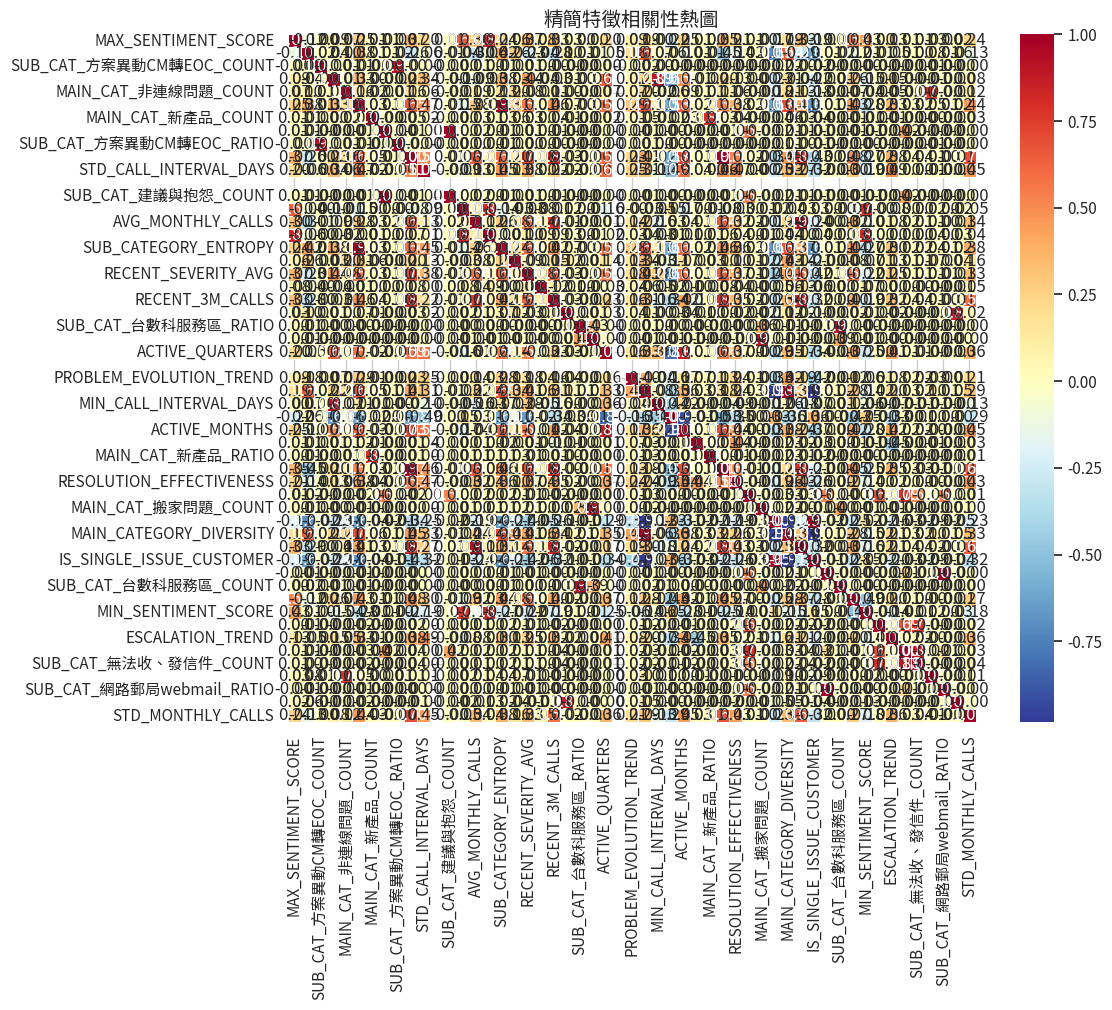


精簡後的特徵數據已保存至: csr_analysis\final_output\simplified_customer_features_top10.csv


In [9]:
# 顯示精簡後的數據
print("=== 精簡後的特徵數據預覽 ===")
display(df_final_features_simplified.head())

print("\n=== 精簡後的數據統計 ===")
display(df_final_features_simplified.describe())

print("\n=== 精簡後的特徵相關性分析 ===")
# 計算精簡特徵的相關性
numerical_features = df_final_features_simplified.select_dtypes(include=[np.number]).columns
if len(numerical_features) > 1:
    corr_matrix_simplified = df_final_features_simplified[numerical_features].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix_simplified, annot=True, cmap='RdYlBu_r', center=0,
                square=True, linewidths=0.5, fmt='.2f')
    plt.title('精簡特徵相關性熱圖', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 保存精簡後的特徵數據
simplified_output_path = os.path.join(output_final_dir, 'simplified_customer_features_top10.csv')
df_final_features_simplified.to_csv(simplified_output_path, index=False, encoding='utf-8-sig')
print(f"\n精簡後的特徵數據已保存至: {simplified_output_path}")


=== 精簡後的特徵相關性分析 (簡潔版) ===


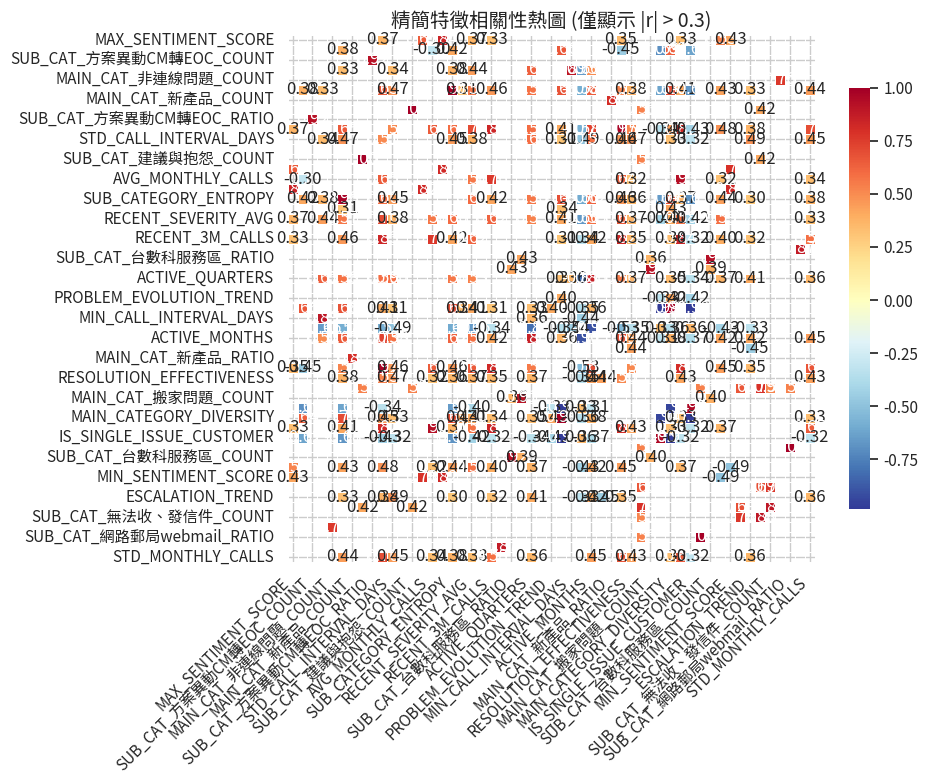


強相關性摘要:
  • MAX_SENTIMENT_SCORE ↔ TOTAL_CALLS: 0.370
  • MAX_SENTIMENT_SCORE ↔ TOTAL_SENTIMENT_SCORE: 0.648
  • MAX_SENTIMENT_SCORE ↔ AVG_SENTIMENT_SCORE: 0.839
  • MAX_SENTIMENT_SCORE ↔ RECENT_SEVERITY_AVG: 0.372
  • MAX_SENTIMENT_SCORE ↔ RECENT_3M_CALLS: 0.333
  • MAX_SENTIMENT_SCORE ↔ RECURRING_ISSUES_COUNT: 0.350
  • MAX_SENTIMENT_SCORE ↔ MAX_MONTHLY_CALLS: 0.334
  • MAX_SENTIMENT_SCORE ↔ STD_SENTIMENT_SCORE: 0.526
  • MAX_SENTIMENT_SCORE ↔ MIN_SENTIMENT_SCORE: 0.426
  • PROBLEM_COMPLEXITY_SCORE ↔ SUB_CATEGORY_DIVERSITY: 0.384
  • PROBLEM_COMPLEXITY_SCORE ↔ AVG_MONTHLY_CALLS: -0.302
  • PROBLEM_COMPLEXITY_SCORE ↔ SUB_CATEGORY_ENTROPY: 0.418
  • PROBLEM_COMPLEXITY_SCORE ↔ MAIN_CATEGORY_ENTROPY: 0.664
  • PROBLEM_COMPLEXITY_SCORE ↔ RECURRING_ISSUES_COUNT: -0.452
  • PROBLEM_COMPLEXITY_SCORE ↔ MAIN_PROBLEM_RATIO: -0.693
  • PROBLEM_COMPLEXITY_SCORE ↔ MAIN_CATEGORY_DIVERSITY: 0.637
  • PROBLEM_COMPLEXITY_SCORE ↔ IS_SINGLE_ISSUE_CUSTOMER: -0.624
  • SUB_CAT_方案異動CM轉EOC_COUNT ↔ SUB_CAT_方

In [10]:
# 簡潔版本：只顯示重要相關性
print("\n=== 精簡後的特徵相關性分析 (簡潔版) ===")
numerical_features = df_final_features_simplified.select_dtypes(include=[np.number]).columns
if len(numerical_features) > 1:
    corr_matrix_simplified = df_final_features_simplified[numerical_features].corr()
    
    plt.figure(figsize=(10, 8))
    
    # 創建遮罩：隱藏弱相關性和對角線
    mask = (np.abs(corr_matrix_simplified) < 0.3) | np.eye(len(corr_matrix_simplified), dtype=bool)
    
    # 繪製熱圖
    sns.heatmap(corr_matrix_simplified, 
                annot=True,           # 顯示數值
                cmap='RdYlBu_r',      # 色彩映射
                center=0,             # 以0為中心
                square=True,          # 方形格子
                linewidths=0.5,       # 格線寬度
                fmt='.2f',            # 數值格式
                mask=mask,            # 應用遮罩
                cbar_kws={"shrink": .8})  # 色彩條設定
    
    plt.title('精簡特徵相關性熱圖 (僅顯示 |r| > 0.3)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # 輸出強相關性摘要
    print("\n強相關性摘要:")
    strong_pairs = []
    for i in range(len(corr_matrix_simplified.columns)):
        for j in range(i+1, len(corr_matrix_simplified.columns)):
            corr_val = corr_matrix_simplified.iloc[i, j]
            if abs(corr_val) > 0.3:
                strong_pairs.append(f"{corr_matrix_simplified.columns[i]} ↔ {corr_matrix_simplified.columns[j]}: {corr_val:.3f}")
    
    if strong_pairs:
        for pair in strong_pairs:
            print(f"  • {pair}")
    else:
        print("  沒有發現強相關性特徵對")


=== 精簡後的特徵相關性分析 ===


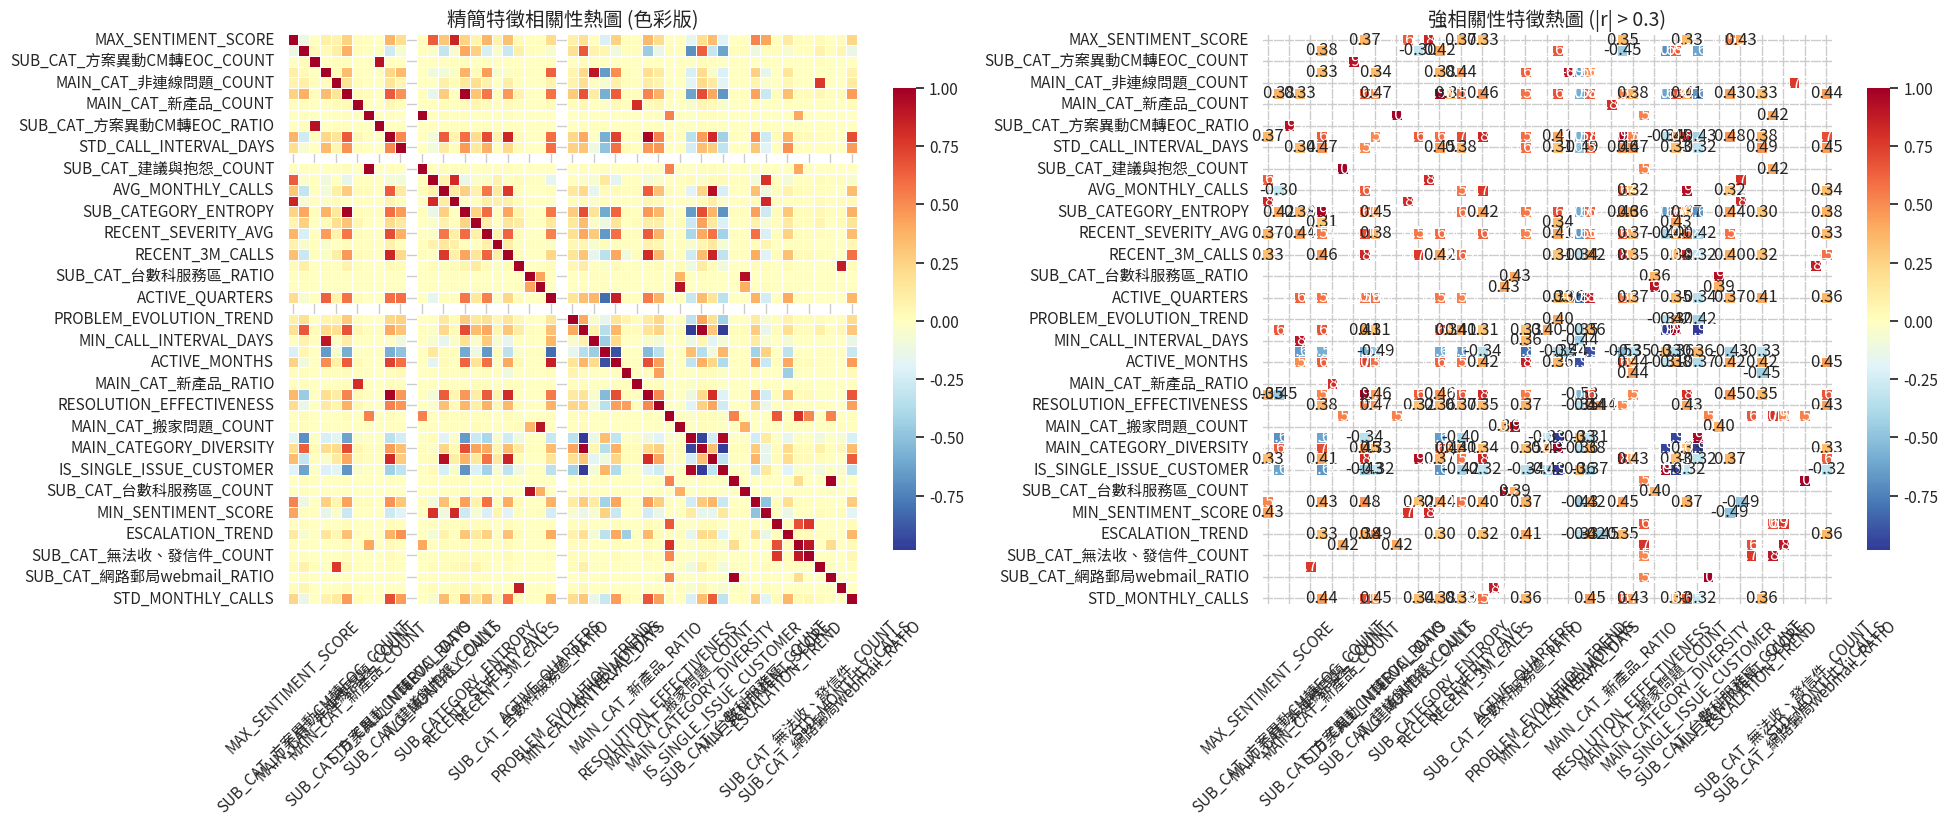


=== 強相關性特徵對 (|相關係數| > 0.3) ===


,Feature1,Feature2,Correlation
47,SUB_CAT_建議與抱怨_RATIO,SUB_CAT_建議與抱怨_COUNT,1.000000
200,SUB_CAT_網路郵局webmail_COUNT,SUB_CAT_網路郵局webmail_RATIO,1.000000
157,MAIN_CATEGORY_ENTROPY,MAIN_CATEGORY_DIVERSITY,0.988525
158,MAIN_CATEGORY_ENTROPY,IS_SINGLE_ISSUE_CUSTOMER,-0.984255
156,MAIN_CATEGORY_ENTROPY,MAIN_PROBLEM_RATIO,-0.979616
...,...,...,...
30,SUB_CATEGORY_DIVERSITY,IS_MULTI_ISSUE_CUSTOMER,0.310018
71,STD_CALL_INTERVAL_DAYS,MAIN_CATEGORY_ENTROPY,0.308892
122,RECENT_3M_CALLS,MAIN_CATEGORY_ENTROPY,0.307662
10,PROBLEM_COMPLEXITY_SCORE,AVG_MONTHLY_CALLS,-0.302197



=== 分組相關性分析 ===


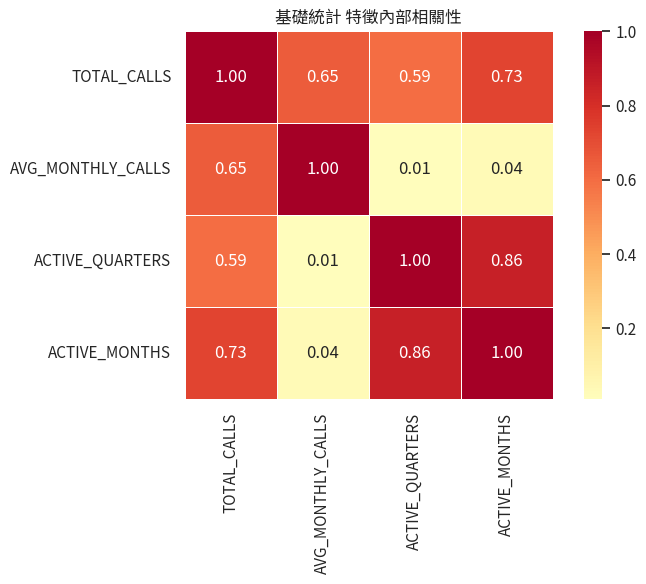

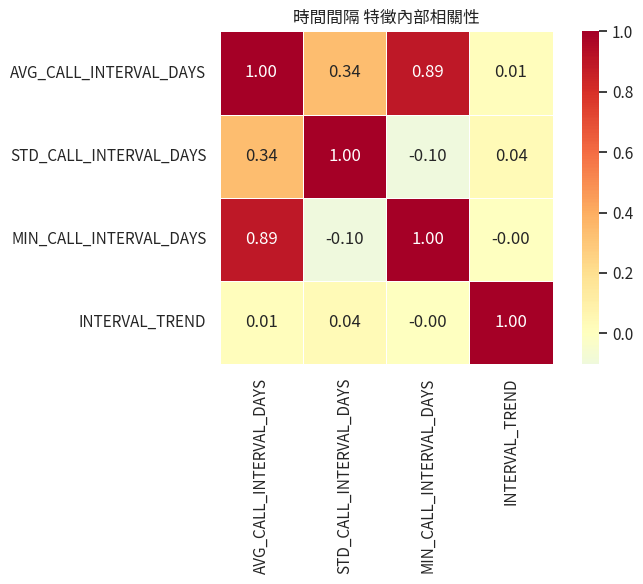

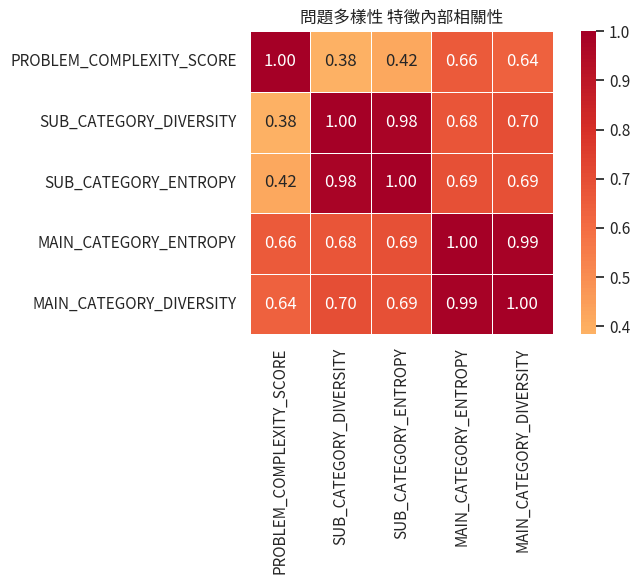

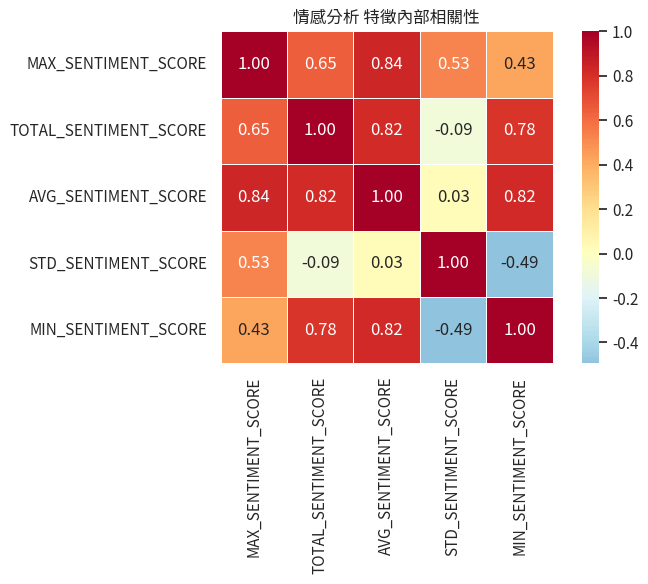

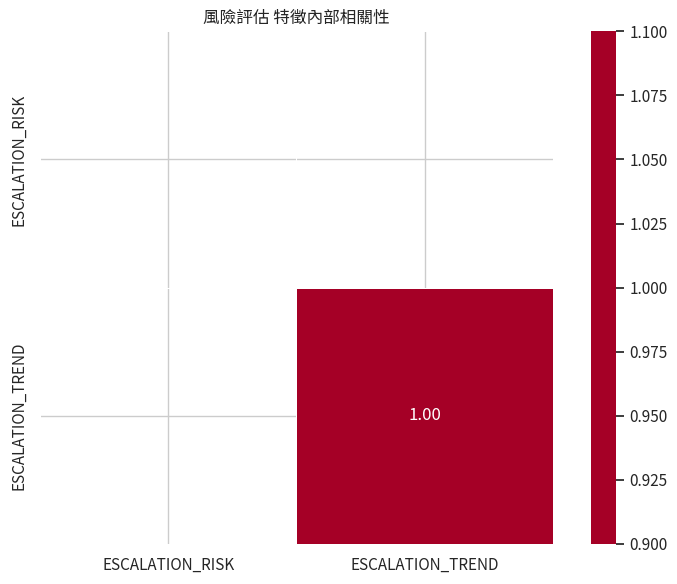

In [11]:
# 改善精簡特徵相關性熱圖的可讀性

print("\n=== 精簡後的特徵相關性分析 ===")
# 計算精簡特徵的相關性
numerical_features = df_final_features_simplified.select_dtypes(include=[np.number]).columns
if len(numerical_features) > 1:
    corr_matrix_simplified = df_final_features_simplified[numerical_features].corr()
    
    # 方案1: 只顯示強相關性 (絕對值 > 0.3)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 左圖：顯示所有相關性但不顯示數值
    ax1 = axes[0]
    sns.heatmap(corr_matrix_simplified, annot=False, cmap='RdYlBu_r', center=0,
                square=True, linewidths=0.5, ax=ax1, cbar_kws={"shrink": .8})
    ax1.set_title('精簡特徵相關性熱圖 (色彩版)', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.tick_params(axis='y', rotation=0)
    
    # 右圖：只顯示強相關性並顯示數值
    ax2 = axes[1]
    # 創建遮罩，只顯示絕對值大於0.3的相關性
    mask = np.abs(corr_matrix_simplified) < 0.3
    # 對角線也遮罩掉（自己與自己的相關性為1）
    mask = mask | np.eye(len(corr_matrix_simplified), dtype=bool)
    
    sns.heatmap(corr_matrix_simplified, annot=True, cmap='RdYlBu_r', center=0,
                square=True, linewidths=0.5, ax=ax2, fmt='.2f', mask=mask,
                cbar_kws={"shrink": .8})
    ax2.set_title('強相關性特徵熱圖 (|r| > 0.3)', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 方案2: 文字版強相關性報告
    print("\n=== 強相關性特徵對 (|相關係數| > 0.3) ===")
    strong_correlations = []
    for i in range(len(corr_matrix_simplified.columns)):
        for j in range(i+1, len(corr_matrix_simplified.columns)):
            corr_val = corr_matrix_simplified.iloc[i, j]
            if abs(corr_val) > 0.3:
                strong_correlations.append({
                    'Feature1': corr_matrix_simplified.columns[i],
                    'Feature2': corr_matrix_simplified.columns[j],
                    'Correlation': corr_val
                })
    
    if strong_correlations:
        strong_corr_df = pd.DataFrame(strong_correlations)
        strong_corr_df = strong_corr_df.sort_values('Correlation', key=abs, ascending=False)
        display(strong_corr_df)
    else:
        print("沒有發現強相關性特徵對 (|r| > 0.3)")
    
    # 方案3: 分組顯示相關性
    print("\n=== 分組相關性分析 ===")
    
    # 按特徵類型分組
    feature_groups = {
        '基礎統計': [f for f in numerical_features if any(keyword in f for keyword in ['TOTAL_CALLS', 'ACTIVE_', 'AVG_MONTHLY'])],
        '時間間隔': [f for f in numerical_features if any(keyword in f for keyword in ['INTERVAL', 'STD_CALL'])],
        '問題多樣性': [f for f in numerical_features if any(keyword in f for keyword in ['DIVERSITY', 'ENTROPY', 'COMPLEXITY'])],
        '情感分析': [f for f in numerical_features if 'SENTIMENT' in f],
        '風險評估': [f for f in numerical_features if any(keyword in f for keyword in ['RISK', 'ESCALATION'])]
    }
    
    # 顯示每組內部的相關性
    for group_name, group_features in feature_groups.items():
        if len(group_features) > 1:
            group_corr = corr_matrix_simplified.loc[group_features, group_features]
            
            plt.figure(figsize=(8, 6))
            sns.heatmap(group_corr, annot=True, cmap='RdYlBu_r', center=0,
                        square=True, linewidths=0.5, fmt='.2f')
            plt.title(f'{group_name} 特徵內部相關性', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
    
else:
    print("數值特徵不足，無法計算相關性")